# The Explainable Auditor — PaySim Fraud Detection Pipeline

**Dissertation:** *The Explainable Auditor: Evaluating Post-Hoc Interpretability for
Machine Learning-Based Financial Transaction Fraud Detection*

This notebook is the complete computational record behind my results chapter. Every
number, table and figure I report in the dissertation is produced here, and I have
kept the cell outputs in place so that each claim can be traced back to the run that
generated it.

## What I set out to do

My central question is not whether a model can detect fraud accurately — the
literature already establishes that gradient boosting does this well — but whether
the *explanations* we attach to such a model can be trusted. I therefore train six
models on the PaySim mobile-money dataset and then evaluate them on the stability of
their explanations rather than on predictive accuracy alone.

| # | Model | Role in my design |
|---|-------|-------------------|
| 1 | XGBoost | Gradient-boosting baseline |
| 2 | LightGBM | Gradient-boosting baseline |
| 3 | CatBoost | Gradient-boosting baseline, and the base learner I use for DASH |
| 4 | Decision Tree | Interpretable-by-design baseline |
| 5 | MLP (neural network) | Non-tree baseline; the only model here that needs feature scaling |
| 6 | **ECGB / CRGB** | My own contribution: gradient boosting with an explanation-consistency penalty built into the training objective |

Alongside these I implement **DASH** (Diverse-Aggregated SHAP), which trains an
ensemble of deliberately diverse CatBoost models and averages their SHAP
explanations. DASH is my control condition: it tells me whether ECGB's *built-in*
consistency mechanism actually earns its place, or whether the same stability could
be obtained more cheaply by averaging explanations *after* training.

## How I have organised the notebook

| Section | Content |
|---|---|
| 1 | Environment, reproducibility settings and the shared helper functions |
| 2 | Loading PaySim and the exploratory analysis that motivated my preprocessing |
| 3 | Feature engineering, the train/test partition and SMOTE |
| 4 | The five baseline models |
| 5 | ECGB, including the ablation and the mechanism test |
| 6 | Explanation consistency — my primary research question |
| 7 | DASH, the post-hoc aggregation control |
| 8 | LIME, and how far it agrees with SHAP |
| 9 | Feature importance across all models |
| 10 | The final leaderboard and significance testing |
| 11 | The deployed four-tier auditor application |
| 12 | A closing inventory of everything the pipeline produced |

Sections 4 and 5 follow the same three-step protocol throughout, which I settled on
early and then applied uniformly so that no model receives more tuning effort than
another:

1. **Hyperparameter search.** Optuna searches the parameter space, scoring every
   trial on PR-AUC. The search is crash-safe: it resumes from its own SQLite study
   file and never repeats a completed trial.
2. **Cross-validation.** The three best trials are compared under 5-fold stratified
   cross-validation, with SMOTE re-fitted inside each fold. The winner is
   checkpointed so that later cells pick it up automatically rather than relying on
   a hand-edited constant.
3. **Final model.** The cross-validated winner is retrained once on the full
   training set and scored on the untouched test set. That single score is the only
   one I report as a test result.

## Running it after a disconnection

I built the whole pipeline around checkpoints because Colab sessions kept dropping
during the longer searches. To pick up where a session left off, re-run **Section 1**
and then the **resume report** immediately after it: it prints which stages have
finished, which Optuna studies and trained models already exist on disk, and which
results are registered. Every cell reloads whatever data, study or model it needs on
its own, so any section can be run in isolation provided its prerequisites exist.


## 1. Environment, Imports and Shared Infrastructure

I put everything reusable in this one cell so that the model sections further down
stay short enough to read as method descriptions rather than as code listings. It
sets the reproducibility seed, creates the project directory layout, and defines a
small SQLite-backed pipeline log (`log_stage`), the checkpoint save/load helpers, the
shared metric function and a consistent plotting theme.

It also defines the three generic helpers — `get_or_create_study`,
`run_cv_for_candidates` and `run_final_model` — that carry out the search /
cross-validate / finalise protocol described above. Factoring these out was a
deliberate methodological choice as much as a practical one: because every model is
put through the identical code path, any difference in the results has to come from
the model itself rather than from an inconsistency in how I evaluated it. Each model
section below therefore reduces to defining a model-specific objective function and
calling these three helpers.


In [ ]:
# ==========================================================
# SECTION 1 - ENVIRONMENT, IMPORTS AND SHARED INFRASTRUCTURE
# ==========================================================

# --- 1a. Storage. I developed this on Colab, where mounting Drive is what
# lets checkpoints survive a runtime reset. The try/except means the same
# notebook also runs unchanged outside Colab, which is how I test it locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running on Colab - using local paths.')

# --- 1b. Packages that Colab does not ship with. Versions are printed at the
# end of this cell and pinned in requirements.txt for reproducibility. ---
!pip install -q optuna xgboost lightgbm catboost imbalanced-learn shap

# --- 1c. Imports ---
import os, json, time, pickle, sqlite3, warnings, random, gc
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import optuna
from optuna.visualization import (
    plot_optimization_history, plot_param_importances, plot_slice
)

import shap

warnings.filterwarnings('ignore')

# --- 1d. Reproducibility. One seed, set here, threaded through every split,
# resampler, sampler and model in the notebook. ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- 1e. A single visual theme, so every figure in the dissertation shares
# one palette and models keep the same colour across different charts. ---
sns.set_theme(style='whitegrid')
PALETTE = {'legit': '#2ca02c', 'fraud': '#d62728', 'accent': '#1f77b4', 'neutral': '#7f7f7f'}
MODEL_COLORS = {
    'XGBoost': '#1f77b4', 'LightGBM': '#ff7f0e', 'CatBoost': '#2ca02c',
    'DecisionTree': '#9467bd', 'MLP': '#8c564b', 'ECGB (CRGB)': '#d62728',
}

# --- 1f. Project directory layout. Everything the pipeline writes - data,
# checkpoints, models, logs, figures, Optuna studies - lives under one root,
# so the whole run can be archived or moved as a single folder. Override the
# root with the ECGB_BASE_DIR environment variable when running elsewhere. ---
DEFAULT_BASE = ('/content/drive/MyDrive/Dissertation_ECGB' if IN_COLAB
                else os.path.join(os.getcwd(), 'Dissertation_ECGB'))
BASE_DIR = os.environ.get('ECGB_BASE_DIR', DEFAULT_BASE)
DIRS = {
    'data':        f'{BASE_DIR}/data',
    'checkpoints': f'{BASE_DIR}/checkpoints',
    'models':      f'{BASE_DIR}/models',
    'logs':        f'{BASE_DIR}/logs',
    'figures':     f'{BASE_DIR}/figures',
    'optuna_db':   f'{BASE_DIR}/optuna_studies',
}
for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

print("Directory structure ready:")
for k, v in DIRS.items():
    print(f"  {k:12s} -> {v}")

# ------------------------------------------------------------
# 1g. A pipeline-level log recording which stage I am on. This is separate
# from Optuna's own SQLite storage, which tracks individual trials; this one
# tracks the progress of the pipeline as a whole. Calling
# get_pipeline_history() prints an audit trail of everything run so far,
# which is also how I reconstruct the order of a session after the fact.
# ------------------------------------------------------------
PIPELINE_DB = f"{DIRS['checkpoints']}/pipeline_state.db"

def init_pipeline_db():
    conn = sqlite3.connect(PIPELINE_DB)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS pipeline_log (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            stage TEXT NOT NULL, status TEXT NOT NULL,
            detail TEXT, timestamp TEXT NOT NULL
        )
    """)
    conn.commit(); conn.close()

def log_stage(stage, status, detail=""):
    """Record a pipeline milestone. status is 'started', 'completed' or 'failed'."""
    conn = sqlite3.connect(PIPELINE_DB)
    conn.execute(
        "INSERT INTO pipeline_log (stage, status, detail, timestamp) VALUES (?,?,?,?)",
        (stage, status, detail, datetime.now().isoformat())
    )
    conn.commit(); conn.close()
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {stage} -> {status} {('| ' + detail) if detail else ''}")

def get_pipeline_history():
    conn = sqlite3.connect(PIPELINE_DB)
    hist = pd.read_sql_query("SELECT * FROM pipeline_log ORDER BY id", conn)
    conn.close()
    return hist

def stage_is_completed(stage):
    conn = sqlite3.connect(PIPELINE_DB)
    n = conn.execute(
        "SELECT COUNT(*) FROM pipeline_log WHERE stage=? AND status='completed'", (stage,)
    ).fetchone()[0]
    conn.close()
    return n > 0

init_pipeline_db()
log_stage("environment_setup", "completed", f"seed={SEED}")

# ------------------------------------------------------------
# 1h. Checkpoint helpers. Every later cell reads and writes through these
# two functions rather than making ad-hoc pickle calls, which is what lets a
# fresh runtime resume from exactly the same place every time.
# ------------------------------------------------------------
def save_checkpoint(name, obj):
    path = f"{DIRS['checkpoints']}/{name}.pkl"
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    return path

def load_checkpoint(name, default=None):
    path = f"{DIRS['checkpoints']}/{name}.pkl"
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return default

def reload_study(study_name):
    """Reload an Optuna study by name from its SQLite file. I call this at the
    top of any cell that needs a `study_*` variable which may not be in memory,
    for instance after a runtime restart."""
    return optuna.load_study(
        study_name=study_name,
        storage=f"sqlite:///{DIRS['optuna_db']}/{study_name}.db"
    )

# ------------------------------------------------------------
# 1i. Shared metric and plotting helpers, defined once here and reused
# everywhere below. Defining them in one place is what guarantees that a
# metric means the same thing for every model I compare.
# ------------------------------------------------------------
def evaluate_at_threshold(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'pr_auc':    average_precision_score(y_true, y_proba),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }

def plot_confusion(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(title); plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"{DIRS['figures']}/{fname}", dpi=150)
    plt.show()
    return cm

def plot_cv_boxplot(cv_results_df, x, y, title, fname):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=cv_results_df, x=x, y=y, color=PALETTE['accent'])
    sns.stripplot(data=cv_results_df, x=x, y=y, color='black', size=6)
    plt.title(title); plt.tight_layout()
    plt.savefig(f"{DIRS['figures']}/{fname}", dpi=150)
    plt.show()

def plot_feature_importance(names, values, title, fname, pct=True):
    imp_df = pd.DataFrame({'feature': names, 'importance': values}).sort_values('importance', ascending=False)
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(data=imp_df, x='importance', y='feature', color=PALETTE['accent'])
    for i, v in enumerate(imp_df['importance']):
        ax.text(v, i, f' {v:.2f}{"%" if pct else ""}', va='center', fontsize=9)
    plt.xlabel('Importance'); plt.title(title); plt.tight_layout()
    plt.savefig(f"{DIRS['figures']}/{fname}", dpi=150)
    plt.show()
    return imp_df

def register_result(model_name, test_metrics, extra=None):
    """Append a model's final test-set metrics to the shared results registry,
    so that the comparison in Section 10 can build its leaderboard without
    re-running or re-scoring anything."""
    all_results = load_checkpoint('all_model_results', default={})
    entry = dict(test_metrics)
    if extra:
        entry.update(extra)
    all_results[model_name] = entry
    save_checkpoint('all_model_results', all_results)
    return all_results

# ------------------------------------------------------------
# 1j. The three helpers implementing my search / cross-validate / finalise
# protocol. Beyond collapsing each model section from roughly 150 repeated
# lines to about 30, putting every model through one code path is what lets
# me attribute differences in the results to the models rather than to
# inconsistencies in how I evaluated them.
# ------------------------------------------------------------
def make_trial_logger():
    records = []
    def callback(study, trial):
        row = {'trial': trial.number, **trial.params, **trial.user_attrs}
        row['value'] = trial.value
        row['duration_s'] = trial.duration.total_seconds()
        records.append(row)
        print(f"  Trial {trial.number:2d} | value={trial.value:.5f} | time={trial.duration.total_seconds():.1f}s")
    return callback, records

def get_or_create_study(study_name, n_trials_target, objective_fn):
    """Load an existing study if one exists and run only the trials still
    outstanding. This is what makes tuning crash-safe: a dropped session costs
    me the trial in flight, never the whole search."""
    storage_path = f"sqlite:///{DIRS['optuna_db']}/{study_name}.db"
    study = optuna.create_study(
        study_name=study_name, storage=storage_path,
        direction='maximize', load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    n_done = len(study.trials)
    n_remaining = max(0, n_trials_target - n_done)
    print(f"[{study_name}] {n_done} trial(s) already done, running {n_remaining} more.")
    if n_remaining > 0:
        callback, _ = make_trial_logger()
        study.optimize(objective_fn, n_trials=n_remaining, callbacks=[callback])
    else:
        print("  Target trial count already reached — nothing to run.")
    print(f"  Best so far: trial #{study.best_trial.number}, PR-AUC={study.best_value:.5f}")
    return study

def show_trial_results(study, model_key, slice_plot=True):
    trials_df = study.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)
    print(f"\n=== {model_key}: all trials, ranked by PR-AUC ===")
    display(trials_df)
    trials_df.to_csv(f"{DIRS['logs']}/{model_key}_trials_results.csv", index=False)
    plot_optimization_history(study).show()
    plot_param_importances(study).show()
    if slice_plot:
        plot_slice(study).show()
    return trials_df

def run_cv_for_candidates(model_key, X_train, y_train, candidate_trials, build_model_fn, n_splits=5):
    """5-fold stratified cross-validation for each candidate configuration.
    SMOTE is re-fitted inside every fold and never sees that fold's validation
    rows - resampling before splitting would leak synthetic rows derived from
    validation data into training. A checkpoint is written after each candidate
    so a crash costs at most one candidate's worth of work. Returns
    (results_df, summary_df, best_label) and checkpoints the winning label so
    the final-model cell picks it up without my editing a constant by hand."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    cv_results, cv_summary = [], []

    for label, params in candidate_trials.items():
        print(f"\n--- CV for {label} ---")
        fold_metrics = []
        for fold_num, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
            X_ftr, y_ftr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
            X_fval, y_fval = X_train.iloc[val_idx], y_train.iloc[val_idx]

            X_ftr_sm, y_ftr_sm = SMOTE(random_state=SEED).fit_resample(X_ftr, y_ftr)

            model = build_model_fn(params)
            model.fit(X_ftr_sm, y_ftr_sm)
            y_proba = model.predict_proba(X_fval)[:, 1]
            m = evaluate_at_threshold(y_fval, y_proba)
            m['fold'] = fold_num
            m['trial'] = label
            fold_metrics.append(m)
            print(f"  Fold {fold_num}: recall={m['recall']:.4f} precision={m['precision']:.4f} "
                  f"f1={m['f1']:.4f} pr_auc={m['pr_auc']:.4f}")

            del model, X_ftr, y_ftr, X_fval, y_fval, X_ftr_sm, y_ftr_sm, y_proba
            gc.collect()

        cv_results.extend(fold_metrics)
        fold_df = pd.DataFrame(fold_metrics)
        summary = {'trial': label}
        for metric in ['recall', 'precision', 'f1', 'pr_auc', 'roc_auc']:
            summary[f'{metric}_mean'] = fold_df[metric].mean()
            summary[f'{metric}_std'] = fold_df[metric].std()
        cv_summary.append(summary)
        print(f"  --> Mean PR-AUC: {summary['pr_auc_mean']:.4f} +/- {summary['pr_auc_std']:.4f}")

        save_checkpoint(f'{model_key}_cv_partial', {'cv_results': cv_results, 'cv_summary': cv_summary})

    cv_results_df = pd.DataFrame(cv_results)
    cv_summary_df = pd.DataFrame(cv_summary)
    cv_results_df.to_csv(f"{DIRS['logs']}/{model_key}_cv_all_folds.csv", index=False)
    cv_summary_df.to_csv(f"{DIRS['logs']}/{model_key}_cv_summary.csv", index=False)

    print(f"\n=== {model_key}: CV summary (mean +/- std across {n_splits} folds) ===")
    display(cv_results_df)
    display(cv_summary_df)

    best_label = cv_summary_df.loc[cv_summary_df['pr_auc_mean'].idxmax(), 'trial']
    print(f"\nBest by CV mean PR-AUC: {best_label}")
    save_checkpoint(f'{model_key}_best_trial_label', best_label)

    plot_cv_boxplot(cv_results_df, 'trial', 'pr_auc', f'{model_key}: PR-AUC across {n_splits} folds',
                     f'{model_key}_cv_pr_auc_comparison.png')
    log_stage(f"{model_key}_cv", "completed", f"best_trial={best_label}")
    return cv_results_df, cv_summary_df, best_label

def run_final_model(model_key, display_name, X_train, y_train, X_test, y_test,
                     build_model_fn, params, feature_importance_fn=None, save_fmt='pickle'):
    """Train once on the full resampled training set, score on the untouched
    test set, save the confusion matrix and the model, and register the result
    into the shared leaderboard. The score this produces is the only test-set
    number I report for a given model."""
    log_stage(f"{model_key}_final_model", "started")
    print(f"Using params:\n{json.dumps(params, indent=2, default=str)}")

    X_train_sm, y_train_sm = SMOTE(random_state=SEED).fit_resample(X_train, y_train)
    print(f"SMOTE applied to full training set: {y_train_sm.value_counts().to_dict()}")

    model = build_model_fn(params)
    model.fit(X_train_sm, y_train_sm)
    print("Model trained.")

    y_test_proba = model.predict_proba(X_test)[:, 1]
    test_metrics = evaluate_at_threshold(y_test, y_test_proba)
    print(f"\n=== {display_name}: FINAL TEST RESULTS ===")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")

    y_test_pred = (y_test_proba >= 0.5).astype(int)
    plot_confusion(y_test, y_test_pred, f'Confusion Matrix - Test Set ({display_name})',
                   f'{model_key}_confusion_matrix.png')

    if feature_importance_fn is not None:
        feature_importance_fn(model)

    model_path = f"{DIRS['models']}/{model_key}_final.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model saved: {model_path}")

    register_result(display_name, test_metrics)
    log_stage(f"{model_key}_final_model", "completed", f"test_pr_auc={test_metrics['pr_auc']:.5f}")
    return model, test_metrics

# --- 1k. Record the library versions this run used. Colab updates packages
# without warning, and having the versions printed in the saved output has
# more than once explained a result I could not otherwise reproduce. ---
print("\n--- Library versions ---")
print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
print(f"xgboost   : {xgb.__version__}")
print(f"lightgbm  : {lgb.__version__}")
print(f"catboost  : {cb.__version__}")
print(f"optuna    : {optuna.__version__}")
print(f"shap      : {shap.__version__}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory structure ready:
  data         -> /content/drive/MyDrive/Dissertation_ECGB/data
  checkpoints  -> /content/drive/MyDrive/Dissertation_ECGB/checkpoints
  models       -> /content/drive/MyDrive/Dissertation_ECGB/models
  logs         -> /content/drive/MyDrive/Dissertation_ECGB/logs
  figures      -> /content/drive/MyDrive/Dissertation_ECGB/figures
  optuna_db    -> /content/drive/MyDrive/Dissertation_ECGB/optuna_studies
[10:17:23] environment_setup -> completed | seed=42

--- Library versions ---
pandas    : 2.2.2
numpy     : 2.0.2
xgboost   : 3.3.0
lightgbm  : 4.6.0
catboost  : 1.2.10
optuna    : 4.9.0
shap      : 0.52.0


### 1.1 Resume report

I run this cell whenever I reconnect to a fresh runtime. It performs no work and
changes nothing; it simply reports what already exists on disk so that I can see at a
glance which section to continue from.


In [ ]:
# ==========================================================
# SECTION 1.1 - RESUME REPORT (read-only; changes nothing)
# ==========================================================
print("=== Pipeline stage history ===")
display(get_pipeline_history())

print("\n=== Optuna studies saved on Drive ===")
if os.path.exists(DIRS['optuna_db']) and os.listdir(DIRS['optuna_db']):
    for fname in sorted(os.listdir(DIRS['optuna_db'])):
        print(" ", fname)
else:
    print("  (none yet)")

print("\n=== Trained models saved on Drive ===")
if os.path.exists(DIRS['models']) and os.listdir(DIRS['models']):
    for fname in sorted(os.listdir(DIRS['models'])):
        print(" ", fname)
else:
    print("  (none yet)")

print("\n=== Final test-set results collected so far ===")
all_results = load_checkpoint('all_model_results', default={})
if all_results:
    display(pd.DataFrame(all_results).T)
else:
    print("  (none yet - run the model sections in 4 and 5 below)")

print("\nEvery section below reloads whatever data, study or model it needs "
      "on its own, so I can go straight to any section after a restart "
      "provided that section's prerequisites exist. The ECGB cells are the "
      "one thing to watch: they need the 'data_splits' checkpoint on disk "
      "AND the Section 5.1 core cell to have been run in the current session, "
      "because function definitions do not survive a restart.")


=== Pipeline stage history ===


,id,stage,status,detail,timestamp
0,1,environment_setup,completed,seed=42,2026-07-18T20:06:35.652368
1,2,data_loading,started,,2026-07-18T20:06:35.747370
2,3,data_loading,completed,"rows=6362620, fraud_rate=0.1291%",2026-07-18T20:08:06.472612
3,4,preprocessing,started,,2026-07-18T20:08:06.516604
4,5,preprocessing,completed,"features=13, train=5090096, test=1272524",2026-07-18T20:08:57.358378
...,...,...,...,...,...
180,181,deployment_smoke_test,started,,2026-08-08T20:21:42.042003
181,182,deployment_smoke_test,completed,all four tiers responded 200,2026-08-08T20:21:45.128266
182,183,deployment_evaluation,started,,2026-08-08T20:28:22.339360
183,184,deployment_evaluation,completed,"n=200, e2e_mean_ms=109.76",2026-08-08T20:28:44.650722



=== Optuna studies saved on Drive ===
  catboost_trial_search.db
  crgb_trial_search_v2.db
  dt_trial_search.db
  lightgbm_trial_search.db
  mlp_trial_search.db
  mlp_trial_search_v2.db
  xgboost_trial_search.db

=== Trained models saved on Drive ===
  catboost_final.pkl
  crgb_final_v2.json
  dt_final.pkl
  lightgbm_final.pkl
  mlp_final.pkl
  xgboost_final.pkl

=== Final test-set results collected so far ===


,recall,precision,f1,pr_auc,roc_auc
XGBoost,0.997565,0.956801,0.976758,0.998251,0.999898
LightGBM,0.997565,0.966392,0.981731,0.998411,0.999823
CatBoost,0.997565,0.941413,0.968676,0.998636,0.999586
DecisionTree,0.998174,0.869104,0.929178,0.998008,0.999330
ECGB (CRGB),0.980523,1.000000,0.990166,0.997615,0.999546
MLP,0.992696,0.288315,0.446849,0.964341,0.999180



Tip: every section below reloads whatever data / study / model it needs from Drive on its own, so you can jump straight to any section after a restart, as long as that section's prerequisite checkpoints already exist (e.g. the CRGB cells need 'data_splits' + the CRGB core cell's function definitions to have run at least once this session).


## 2. The PaySim Dataset and Exploratory Analysis

Before changing anything about the data I wanted to understand what I was working
with, because three of the properties I found here go on to constrain every
methodological decision in the rest of the notebook.

The first is the class balance. Fraud accounts for roughly 0.13% of transactions,
which is why I use SMOTE for resampling and PR-AUC as my selection metric throughout:
with an imbalance this severe, accuracy is uninformative and even ROC-AUC flatters a
model that performs poorly on the minority class.

The second is that fraud occurs only in TRANSFER and CASH_OUT transactions. Knowing
this before engineering features told me that the transaction type carries real
signal and should be encoded rather than discarded.

The third is `isFlaggedFraud`, PaySim's own rule-based flag. I retain it here purely
as a naive baseline for comparison, and I exclude it from the feature set in the next
section — a rule that is itself a crude fraud detector would leak the label into
every model I train.


[10:22:55] data_loading -> started 
GPU configs set for T4:
  xgboost: {'tree_method': 'hist', 'device': 'cuda'}
  lightgbm: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}
  catboost: {'task_type': 'GPU', 'devices': '0'}

Shape: 6,362,620 rows x 11 columns

Column dtypes:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Class balance:
  Legitimate (0): 6,354,407  (99.8709%)
  Fraud       (1): 8,213  (0.1291%)
  Imbalance ratio: 1 : 773.7


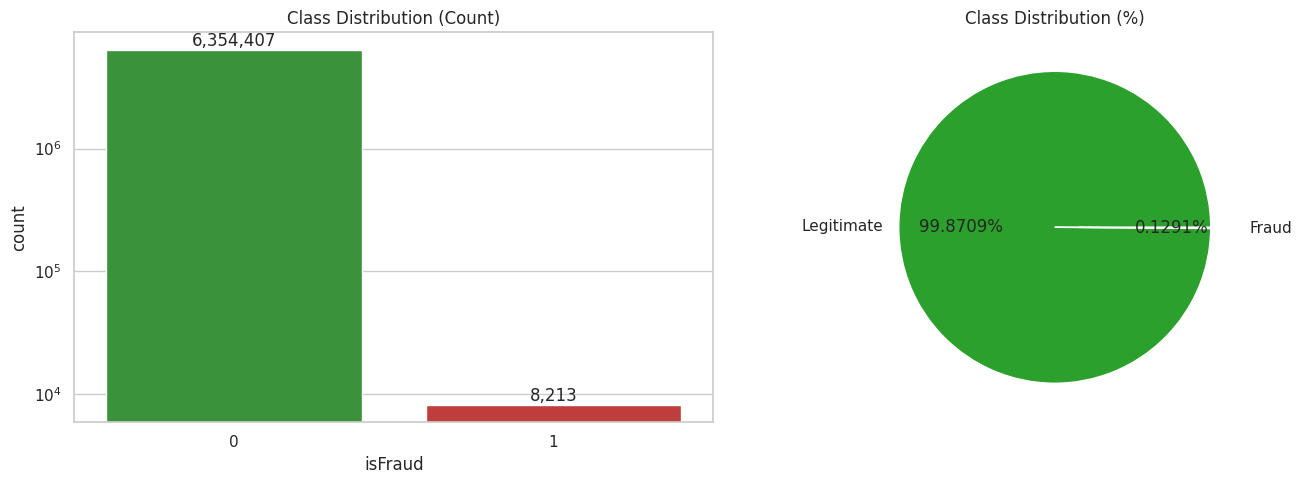


Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud rate by transaction type:


,total_txns,fraud_txns,fraud_rate,fraud_rate_%
type,,,,
TRANSFER,532909,4097,0.007688,0.768799
CASH_OUT,2237500,4116,0.001840,0.183955
CASH_IN,1399284,0,0.000000,0.000000
DEBIT,41432,0,0.000000,0.000000
PAYMENT,2151495,0,0.000000,0.000000


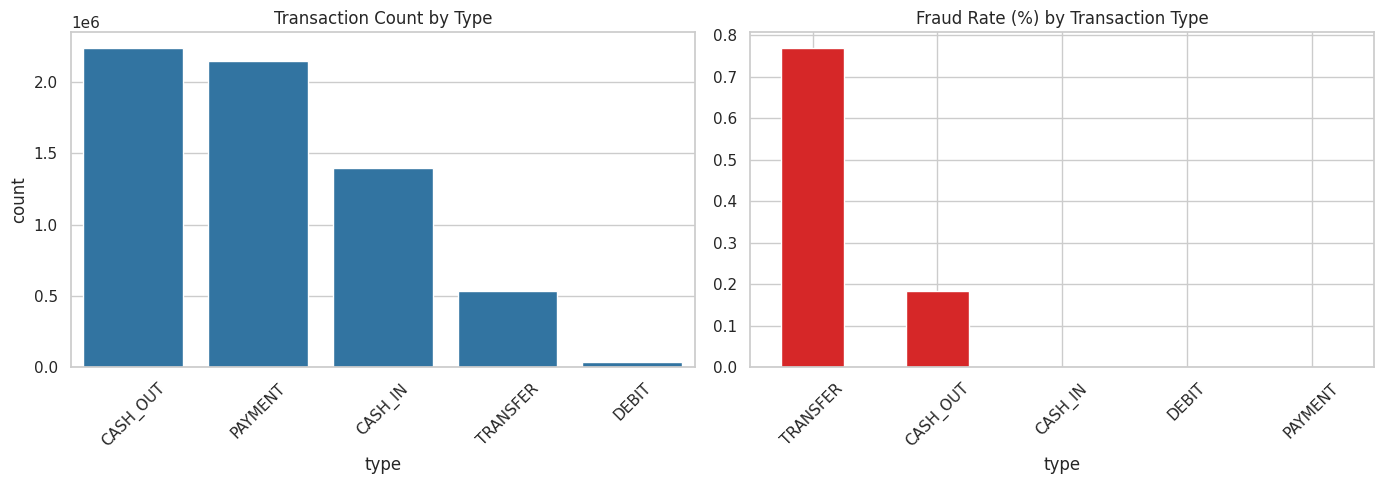

Plotting sample: 300,000 rows (stratified, fraud ratio preserved)


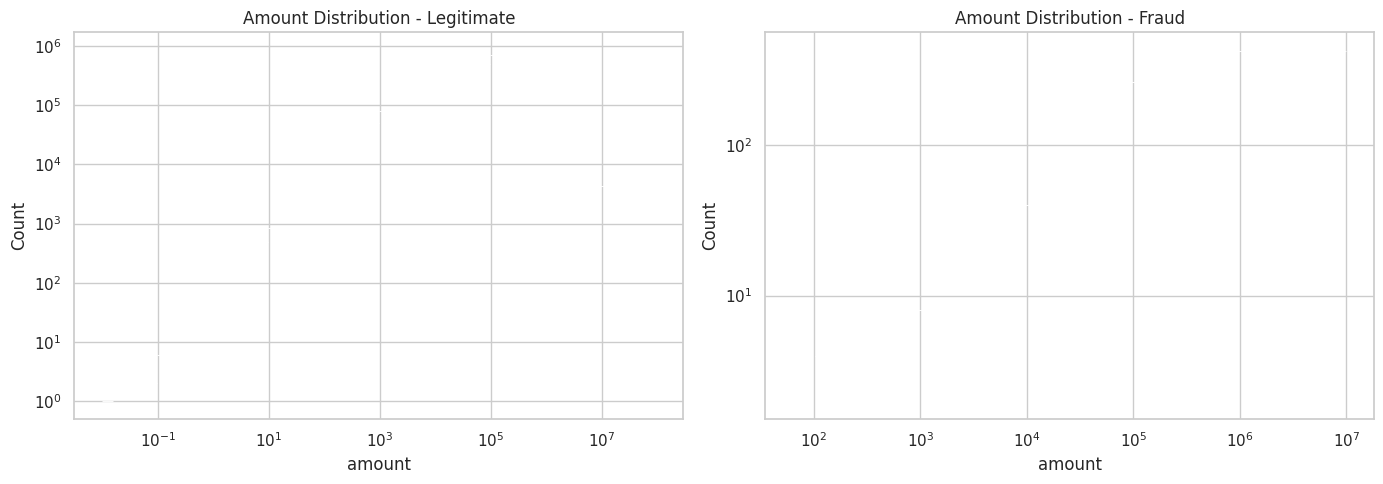


Amount stats - Legitimate:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

Amount stats - Fraud:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


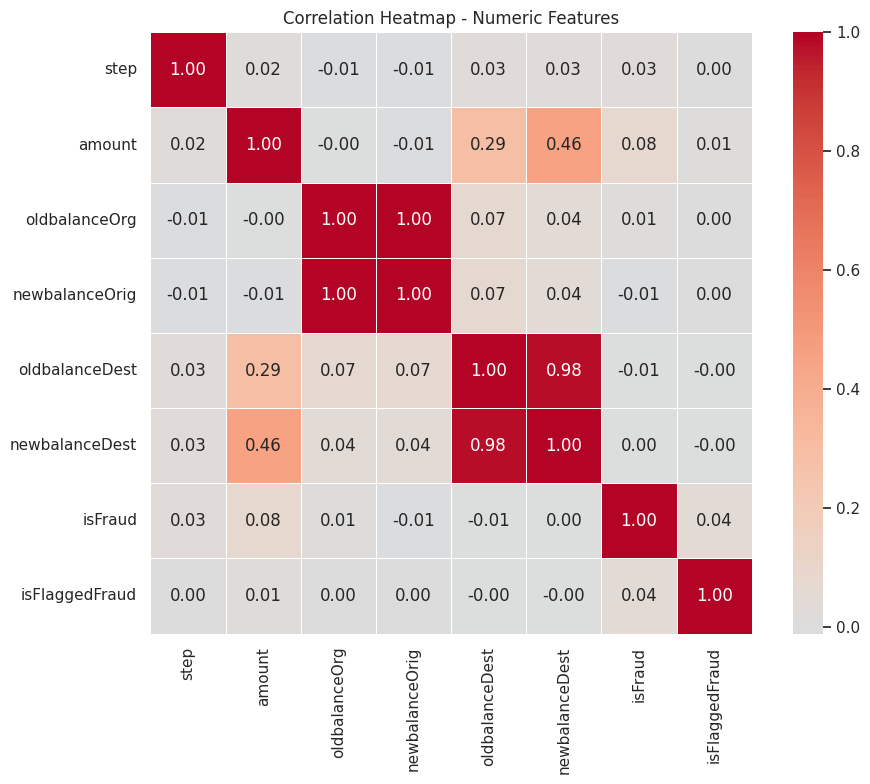


isFlaggedFraud value counts:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64
This is PaySim's own simplistic rule-based flag - worth reporting how poorly it captures true fraud, as a naive baseline comparison point.
[10:24:22] data_loading -> completed | rows=6362620, fraud_rate=0.1291%


In [ ]:
# ==========================================================
# SECTION 2 - LOAD PAYSIM AND EXPLORATORY DATA ANALYSIS
# ==========================================================

log_stage("data_loading", "started")

# --- 2a. GPU settings for each library. I ran this on a Colab T4; each
# library wants its device configured differently, so I keep them together
# here rather than scattered through the model sections. ---
GPU_PARAMS = {
    'xgboost':  {'tree_method': 'hist', 'device': 'cuda'},
    'lightgbm': {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0},
    'catboost': {'task_type': 'GPU', 'devices': '0'},
}
print("GPU configs set for T4:")
for k, v in GPU_PARAMS.items():
    print(f"  {k}: {v}")

# --- 2b. Load PaySim. Point PAYSIM_CSV at the file if it lives elsewhere;
# the dataset is not redistributed with this notebook (see the README). ---
DATA_PATH = os.environ.get(
    'PAYSIM_CSV',
    '/content/drive/MyDrive/paysim.csv' if IN_COLAB else f'{DIRS["data"]}/paysim.csv'
)
df = pd.read_csv(DATA_PATH)

print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
display(df.head())

# --- 2c. Class balance. This is the single most consequential property of
# the dataset for my design: it is why I resample with SMOTE and why I select
# on PR-AUC rather than accuracy throughout. ---
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(f"\nClass balance:")
print(f"  Legitimate (0): {fraud_counts[0]:,}  ({fraud_pct[0]:.4f}%)")
print(f"  Fraud       (1): {fraud_counts[1]:,}  ({fraud_pct[1]:.4f}%)")
print(f"  Imbalance ratio: 1 : {fraud_counts[0]/fraud_counts[1]:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='isFraud', ax=axes[0], palette=[PALETTE['legit'], PALETTE['fraud']])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_yscale('log')
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.4f%%',
            colors=[PALETTE['legit'], PALETTE['fraud']], explode=[0, 0.15])
axes[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/class_balance.png", dpi=150)
plt.show()

# --- 2d. Fraud by transaction type. Fraud turns out to occur only in
# TRANSFER and CASH_OUT, which tells me the type column carries real signal
# and should be encoded rather than discarded. ---
print(f"\nTransaction types:\n{df['type'].value_counts()}")

type_fraud = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
type_fraud.columns = ['total_txns', 'fraud_txns', 'fraud_rate']
type_fraud['fraud_rate_%'] = type_fraud['fraud_rate'] * 100
print(f"\nFraud rate by transaction type:")
display(type_fraud.sort_values('fraud_rate_%', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='type', ax=axes[0], order=df['type'].value_counts().index, color=PALETTE['accent'])
axes[0].set_title('Transaction Count by Type')
axes[0].tick_params(axis='x', rotation=45)

type_fraud['fraud_rate_%'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color=PALETTE['fraud'])
axes[1].set_title('Fraud Rate (%) by Transaction Type')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/type_fraud_breakdown.png", dpi=150)
plt.show()

# --- 2e. Amount distributions by class. I plot from a stratified 300k-row
# sample: seaborn is slow over 6M+ rows and the sample preserves the fraud
# ratio, so the shape of the distributions is unaffected. ---
df_sample, _ = train_test_split(
    df, train_size=300_000, stratify=df['isFraud'], random_state=SEED
)
print(f"Plotting sample: {len(df_sample):,} rows (stratified, fraud ratio preserved)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[df['isFraud']==0]['amount'], bins=50, ax=axes[0],
             color=PALETTE['legit'], log_scale=(True, True))
axes[0].set_title('Amount Distribution - Legitimate')
sns.histplot(df[df['isFraud']==1]['amount'], bins=50, ax=axes[1],
             color=PALETTE['fraud'], log_scale=(True, True))
axes[1].set_title('Amount Distribution - Fraud')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/amount_distribution.png", dpi=150)
plt.show()

print(f"\nAmount stats - Legitimate:\n{df[df['isFraud']==0]['amount'].describe()}")
print(f"\nAmount stats - Fraud:\n{df[df['isFraud']==1]['amount'].describe()}")

# --- 2f. Correlation across the numeric features, mainly to check for
# redundancy among the balance columns before I engineer anything from them. ---
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/correlation_heatmap.png", dpi=150)
plt.show()

# --- 2g. isFlaggedFraud, PaySim's own rule-based flag. I keep it only as a
# naive baseline for comparison and drop it from the feature set in Section 3:
# a column that is itself a crude fraud detector would leak the label. ---
print(f"\nisFlaggedFraud value counts:\n{df['isFlaggedFraud'].value_counts()}")
print("PaySim's own rule-based flag. How little of the true fraud it captures "
      "is worth reporting as a naive baseline - and is also why I exclude it "
      "from the feature set.")

log_stage("data_loading", "completed", f"rows={df.shape[0]}, fraud_rate={fraud_pct[1]:.4f}%")


## 3. Feature Engineering, Data Partitioning and SMOTE

I add two engineered "balance error" features that capture cases where a
transaction's before-and-after account balances do not reconcile the way a legitimate
transaction's would. Lopez-Rojas et al., in the paper introducing PaySim, identify
these inconsistencies as a strong fraud signal, and my exploratory plots below
support that.

I one-hot encode `type`, and drop the two identifier columns along with
`isFlaggedFraud` for the leakage reason given above.

The ordering of the final two steps matters more than it might appear. I split the
data **before** any resampling, and fit SMOTE on the training split only. If
synthetic fraud rows were generated using information drawn from the test set, every
downstream metric would be optimistically biased and the entire evaluation would be
invalid. I apply the same discipline inside every cross-validation fold later on.


[20:20:42] preprocessing -> started 
Engineered features added: errorBalanceOrig, errorBalanceDest
       errorBalanceOrig  errorBalanceDest
count      6.362620e+06      6.362620e+06
mean       2.010925e+05      5.556717e+04
std        6.066505e+05      4.415288e+05
min       -1.000000e-02     -7.588573e+07
25%        2.954230e+03      0.000000e+00
50%        6.867726e+04      3.500490e+03
75%        2.496411e+05      2.935305e+04
max        9.244552e+07      1.319123e+07


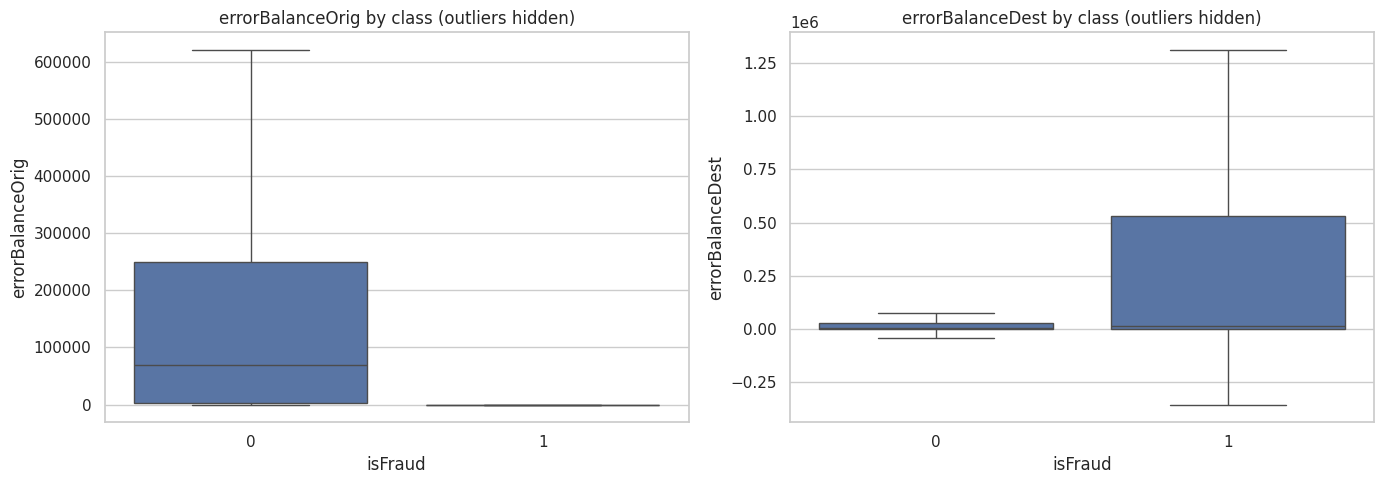


One-hot encoded 'type' into: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Final feature set (13 features):
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Train: 5,090,096 rows | Fraud rate: 0.1291%
Test:  1,272,524 rows | Fraud rate: 0.1291%

Applying SMOTE to training set only...
Before SMOTE: {0: 5083526, 1: 6570}
After SMOTE:  {0: 5083526, 1: 5083526}


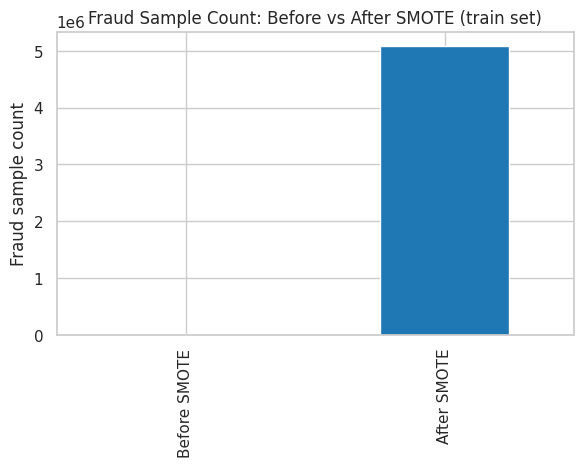


Splits checkpointed to: /content/drive/MyDrive/Dissertation_ECGB/checkpoints/data_splits.pkl
[20:21:13] preprocessing -> completed | features=13, train=5090096, test=1272524


In [ ]:
# ==========================================================
# SECTION 3 - FEATURE ENGINEERING, DATA PARTITIONING AND SMOTE
# ==========================================================

log_stage("preprocessing", "started")

# --- 3a. The two engineered balance-error features. Each measures how far a
# transaction's before-and-after balances fail to reconcile; the PaySim paper
# identifies this inconsistency as a strong fraud signal, and the boxplots
# below show the separation between classes clearly. ---
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print("Engineered features added: errorBalanceOrig, errorBalanceDest")
print(df[['errorBalanceOrig', 'errorBalanceDest']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, ax in zip(['errorBalanceOrig', 'errorBalanceDest'], axes):
    sns.boxplot(data=df_sample.assign(
        errorBalanceOrig=df_sample['newbalanceOrig']+df_sample['amount']-df_sample['oldbalanceOrg'],
        errorBalanceDest=df_sample['oldbalanceDest']+df_sample['amount']-df_sample['newbalanceDest']
    ), x='isFraud', y=col, ax=ax, showfliers=False)
    ax.set_title(f'{col} by class (outliers hidden)')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/error_balance_features.png", dpi=150)
plt.show()

# --- 3b. One-hot encode the transaction type. I keep every level rather than
# dropping the first, because the tree models split on individual indicators
# and I want the importance attributable to each type separately. ---
df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=False)
type_cols = [c for c in df.columns if c.startswith('type_')]
print(f"\nOne-hot encoded 'type' into: {type_cols}")

# --- 3c. Drop the two account identifiers, which are unique per transaction
# and would only be memorised, and isFlaggedFraud for the leakage reason in
# Section 2. ---
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
feature_cols = [c for c in df.columns if c not in drop_cols + ['isFraud']]

X = df[feature_cols]
y = df['isFraud']

print(f"\nFinal feature set ({len(feature_cols)} features):")
print(feature_cols)

# --- 3d. Split first, stratified, before any resampling whatsoever. The
# ordering here is not incidental: reversing it is the single most common way
# to invalidate an imbalanced-classification result. ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"\nTrain: {X_train.shape[0]:,} rows | Fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test:  {X_test.shape[0]:,} rows | Fraud rate: {y_test.mean()*100:.4f}%")

# --- 3e. SMOTE, fitted on the training split alone. Synthetic fraud rows must
# never be interpolated from test-set neighbours, or every metric downstream
# is optimistically biased. ---
print("\nApplying SMOTE to training set only...")
smote = SMOTE(random_state=SEED, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")

fig, ax = plt.subplots(figsize=(6, 5))
pd.Series({'Before SMOTE': y_train.value_counts()[1],
           'After SMOTE': y_train_smote.value_counts()[1]}).plot(
    kind='bar', ax=ax, color=[PALETTE['fraud'], PALETTE['accent']])
ax.set_title('Fraud Sample Count: Before vs After SMOTE (train set)')
ax.set_ylabel('Fraud sample count')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/smote_effect.png", dpi=150)
plt.show()

# --- 3f. Checkpoint the splits. Every model section below loads this same
# file, so every model is trained and scored on identical partitions. ---
save_checkpoint('data_splits', {
    'X_train': X_train, 'y_train': y_train,
    'X_train_smote': X_train_smote, 'y_train_smote': y_train_smote,
    'X_test': X_test, 'y_test': y_test,
    'feature_cols': feature_cols,
})

print(f"\nSplits checkpointed to: {DIRS['checkpoints']}/data_splits.pkl")
log_stage("preprocessing", "completed",
          f"features={len(feature_cols)}, train={len(X_train)}, test={len(X_test)}")


## 4. Baseline Models

The five models in this section give me the comparison set against which ECGB is
judged. Each is put through the identical three-step protocol — Optuna search,
5-fold cross-validation of the top three trials, then a single final model scored on
the held-out test set.


### 4.1 XGBoost

XGBoost is my first gradient-boosting baseline. The search tunes nine
hyperparameters, scoring each trial on PR-AUC for the reasons set out in Section 2.
SMOTE is applied only to the early-stopping training split, so the validation fold
that decides when to stop contains no synthetic rows.


#### 4.1.1 Hyperparameter search

Optuna proposes configurations and each is scored on the inner validation split. I
carve out a separate early-stopping split from the inner training data so that the
number of boosting rounds is chosen without reference to the data used for ranking
the trials.


In [ ]:
# ============================================================
# SECTION 4.1.1 - XGBOOST HYPERPARAMETER SEARCH
# Optuna, PR-AUC objective, early stopping with patience 100
# ============================================================
log_stage("xgboost_trial_search", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
X_es_train, X_es_val, y_es_train, y_es_val = train_test_split(
    X_inner_train, y_inner_train, test_size=0.15, stratify=y_inner_train, random_state=SEED
)
print("Applying SMOTE to the early-stopping training split...")
X_es_train_sm, y_es_train_sm = SMOTE(random_state=SEED).fit_resample(X_es_train, y_es_train)
print("Done.")

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric':      'aucpr',
        'early_stopping_rounds': 100,
        'random_state':     SEED,
        'tree_method': 'hist', 'device': 'cuda',
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_es_train_sm, y_es_train_sm, eval_set=[(X_es_val, y_es_val)], verbose=False)
    y_proba = model.predict_proba(X_inner_val)[:, 1]
    metrics = evaluate_at_threshold(y_inner_val, y_proba)
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    trial.set_user_attr('best_iteration', model.best_iteration)
    return metrics['pr_auc']

study_xgb = get_or_create_study('xgboost_trial_search', n_trials_target=8, objective_fn=xgb_objective)
trials_df_xgb = show_trial_results(study_xgb, 'xgboost')
log_stage("xgboost_trial_search", "completed", f"best_pr_auc={study_xgb.best_value:.5f}")


[15:28:02] xgboost_trial_search -> started 
Applying SMOTE to the early-stopping training split...
Done.


[I 2026-07-19 15:28:34,745] Using an existing study with name 'xgboost_trial_search' instead of creating a new one.


[xgboost_trial_search] 8 trial(s) already done, running 0 more.
  Target trial count already reached — nothing to run.
  Best so far: trial #5, PR-AUC=0.99906

=== xgboost: all trials, ranked by PR-AUC ===


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,...,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,user_attrs_f1,user_attrs_pr_auc,user_attrs_precision,user_attrs_recall,user_attrs_roc_auc,state
0,5,0.999061,2026-07-18 20:10:48.133552,2026-07-18 20:11:05.393999,0 days 00:00:17.260447,0.592427,3.875664,0.019421,6,20,...,2.854240,1.130957e+00,0.773355,100,0.996582,0.999061,0.994693,0.998478,0.999998,COMPLETE
1,0,0.998927,2026-07-18 20:09:21.243330,2026-07-18 20:09:38.791947,0 days 00:00:17.548617,0.578009,0.290418,0.065049,12,4,...,0.624576,2.570604e-03,0.799329,6,0.993187,0.998927,0.987952,0.998478,0.999998,COMPLETE
2,6,0.998535,2026-07-18 20:11:05.444394,2026-07-18 20:11:23.838657,0 days 00:00:18.394263,0.522614,1.943386,0.001657,12,7,...,0.000003,2.874998e-01,0.597991,33,0.996198,0.998535,0.995441,0.996956,0.999995,COMPLETE
3,1,0.998499,2026-07-18 20:09:38.844172,2026-07-18 20:09:53.485195,0 days 00:00:14.641023,0.606170,0.917023,0.252688,3,4,...,0.000005,5.282115e-04,0.916221,32,0.992060,0.998499,0.985725,0.998478,0.999955,COMPLETE
4,4,0.998336,2026-07-18 20:10:32.093989,2026-07-18 20:10:48.093255,0 days 00:00:15.999266,0.561019,0.171943,0.049537,3,10,...,1.527157,2.133142e-06,0.720076,169,0.993187,0.998336,0.987952,0.998478,0.999859,COMPLETE
5,7,0.998321,2026-07-18 20:11:23.875551,2026-07-18 20:11:44.325176,0 days 00:00:20.449625,0.901098,4.934435,0.022097,5,2,...,0.089167,6.143857e-07,0.570462,163,0.996203,0.998321,0.993939,0.998478,0.999853,COMPLETE
6,2,0.998287,2026-07-18 20:09:53.520786,2026-07-18 20:10:14.681163,0 days 00:00:21.160377,0.646072,2.280350,0.032782,5,8,...,0.116569,6.267063e-07,0.569747,241,0.976554,0.998287,0.955572,0.998478,0.999869,COMPLETE
7,3,0.998176,2026-07-18 20:10:14.720025,2026-07-18 20:10:32.057390,0 days 00:00:17.337365,0.585262,4.744428,0.001303,8,2,...,4.905557,1.886150e-01,0.803772,59,0.997719,0.998176,0.996960,0.998478,0.999959,COMPLETE


[15:28:37] xgboost_trial_search -> completed | best_pr_auc=0.99906


#### 4.1.2 Cross-validation of the top three trials

The single validation score used during the search is one noisy estimate, so I do not
trust it to choose the final configuration. The three highest-scoring trials are
re-evaluated under 5-fold stratified cross-validation, with SMOTE re-fitted inside
every fold, and the configuration with the best mean PR-AUC is checkpointed for the
final model.


Candidates (top 3 by validation PR-AUC): ['trial_5', 'trial_0', 'trial_6']

--- CV for trial_5 ---
  Fold 1: recall=0.9970 precision=0.9072 f1=0.9500 pr_auc=0.9976
  Fold 2: recall=0.9947 precision=0.9276 f1=0.9600 pr_auc=0.9957
  Fold 3: recall=0.9939 precision=0.9349 f1=0.9635 pr_auc=0.9959
  Fold 4: recall=0.9977 precision=0.9035 f1=0.9483 pr_auc=0.9978
  Fold 5: recall=0.9947 precision=0.9396 f1=0.9664 pr_auc=0.9951
  --> Mean PR-AUC: 0.9964 +/- 0.0012

--- CV for trial_0 ---
  Fold 1: recall=0.9970 precision=0.9507 f1=0.9733 pr_auc=0.9977
  Fold 2: recall=0.9947 precision=0.9505 f1=0.9721 pr_auc=0.9951
  Fold 3: recall=0.9939 precision=0.9667 f1=0.9801 pr_auc=0.9965
  Fold 4: recall=0.9977 precision=0.9344 f1=0.9650 pr_auc=0.9980
  Fold 5: recall=0.9947 precision=0.9674 f1=0.9809 pr_auc=0.9951
  --> Mean PR-AUC: 0.9965 +/- 0.0014

--- CV for trial_6 ---
  Fold 1: recall=0.9939 precision=0.9947 f1=0.9943 pr_auc=0.9968
  Fold 2: recall=0.9901 precision=0.9962 f1=0.9931 pr_auc=0.9945

,recall,precision,f1,pr_auc,roc_auc,fold,trial
0,0.996956,0.907202,0.949964,0.997572,0.999685,1,trial_5
1,0.994673,0.927608,0.959971,0.995724,0.999075,2,trial_5
2,0.993912,0.934860,0.963482,0.995858,0.999628,3,trial_5
3,0.997717,0.903515,0.948282,0.997760,0.999856,4,trial_5
4,0.994673,0.939612,0.966359,0.995095,0.998982,5,trial_5
5,0.996956,0.950653,0.973254,0.997651,0.999909,1,trial_0
6,0.994673,0.950545,0.972109,0.995084,0.999254,2,trial_0
7,0.993912,0.966691,0.980113,0.996463,0.999555,3,trial_0
8,0.997717,0.934426,0.965035,0.997983,0.999860,4,trial_0
9,0.994673,0.967432,0.980863,0.995076,0.999085,5,trial_0


,trial,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,trial_5,0.995586,0.001650,0.922559,0.016326,0.957611,0.008094,0.996402,0.001191,0.999445,0.000391
1,trial_0,0.995586,0.001650,0.953950,0.013672,0.974275,0.006492,0.996451,0.001373,0.999533,0.000363
2,trial_6,0.993303,0.003015,0.994213,0.001830,0.993756,0.001937,0.995657,0.001396,0.999184,0.000407



Best by CV mean PR-AUC: trial_0


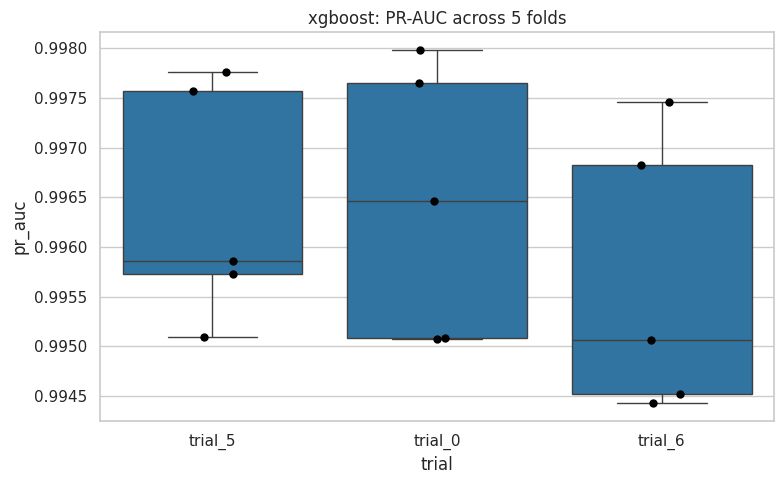

[20:24:23] xgboost_cv -> completed | best_trial=trial_0


In [ ]:
# ============================================================
# SECTION 4.1.2 - XGBOOST: 5-FOLD CV ON THE TOP THREE TRIALS
# ============================================================
if 'study_xgb' not in dir():
    study_xgb = reload_study('xgboost_trial_search')
    trials_df_xgb = study_xgb.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

def build_xgb(params):
    return xgb.XGBClassifier(**params, eval_metric='aucpr', random_state=SEED,
                              tree_method='hist', device='cuda')

top3_xgb = trials_df_xgb.head(3)['number'].tolist()
candidate_trials_xgb = {f'trial_{t}': study_xgb.trials[t].params for t in top3_xgb}
print("Candidates (top 3 by validation PR-AUC):", list(candidate_trials_xgb.keys()))

cv_results_xgb, cv_summary_xgb, best_label_xgb = run_cv_for_candidates(
    'xgboost', X_train, y_train, candidate_trials_xgb, build_xgb
)


#### 4.1.3 Final model and test-set evaluation

The cross-validated winner is retrained on the entire training set and scored once on
the test set. This is the only XGBoost number I report as a test result, and I record
it in the shared results registry that the leaderboard in Section 10 reads from.


Best trial from CV: trial_0
[20:24:29] xgboost_final_model -> started 
Using params:
{
  "n_estimators": 574,
  "max_depth": 12,
  "learning_rate": 0.06504856968981275,
  "subsample": 0.7993292420985183,
  "colsample_bytree": 0.5780093202212182,
  "min_child_weight": 4,
  "gamma": 0.2904180608409973,
  "reg_alpha": 0.6245760287469893,
  "reg_lambda": 0.002570603566117598
}
SMOTE applied to full training set: {0: 5083526, 1: 5083526}
Model trained.

=== XGBoost: FINAL TEST RESULTS ===
  recall: 0.9976
  precision: 0.9568
  f1: 0.9768
  pr_auc: 0.9983
  roc_auc: 0.9999


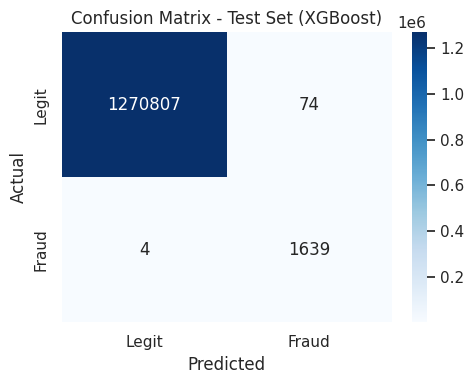

<Figure size 800x600 with 0 Axes>

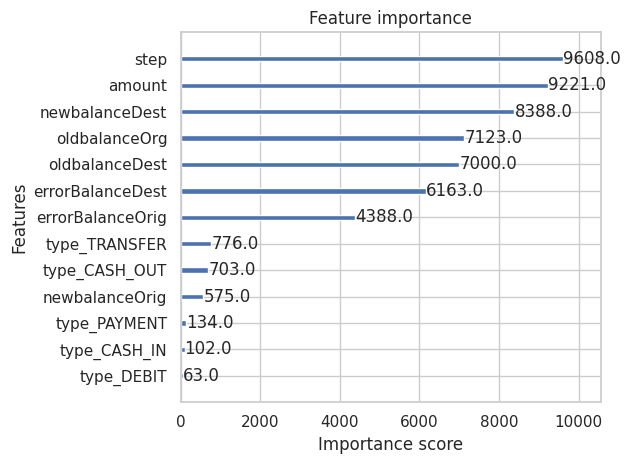

Model saved: /content/drive/MyDrive/Dissertation_ECGB/models/xgboost_final.pkl
[20:25:23] xgboost_final_model -> completed | test_pr_auc=0.99825


In [ ]:
# ============================================================
# SECTION 4.1.3 - XGBOOST FINAL MODEL (CV winner): TRAIN AND TEST
# ============================================================
if 'study_xgb' not in dir():
    study_xgb = reload_study('xgboost_trial_search')

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

best_label_xgb = load_checkpoint('xgboost_best_trial_label')
assert best_label_xgb is not None, "Run Section 4.1.2 (cross-validation) first."
best_trial_num_xgb = int(best_label_xgb.split('_')[1])
best_params_xgb = study_xgb.trials[best_trial_num_xgb].params
print(f"Best trial from CV: {best_label_xgb}")

def build_xgb(params):
    return xgb.XGBClassifier(**params, eval_metric='aucpr', random_state=SEED,
                              tree_method='hist', device='cuda')

def xgb_feature_importance(model):
    plt.figure(figsize=(8, 6))
    xgb.plot_importance(model, max_num_features=13)
    plt.tight_layout()
    plt.savefig(f"{DIRS['figures']}/xgboost_feature_importance.png", dpi=150)
    plt.show()

final_model_xgb, test_metrics_xgb = run_final_model(
    'xgboost', 'XGBoost', X_train, y_train, X_test, y_test,
    build_xgb, best_params_xgb, feature_importance_fn=xgb_feature_importance
)


### 4.2 LightGBM

The same three-step protocol as XGBoost. The one difference is that I wrap each
LightGBM trial in a `try`/`except`: leaf-wise growth with GPU histograms occasionally
fails on an unlucky combination of hyperparameters, and I did not want a single bad
trial to end the whole search. A failed trial is scored as zero and Optuna moves on.


#### 4.2.1 Hyperparameter search


In [ ]:
# ============================================================
# SECTION 4.2.1 - LIGHTGBM HYPERPARAMETER SEARCH
# Each trial is wrapped in try/except: GPU leaf-wise growth fails
# occasionally on an unlucky parameter combination, and one bad trial
# should not end the search.
# ============================================================
log_stage("lightgbm_trial_search", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
X_es_train, X_es_val, y_es_train, y_es_val = train_test_split(
    X_inner_train, y_inner_train, test_size=0.15, stratify=y_inner_train, random_state=SEED
)
print("Applying SMOTE to the early-stopping training split...")
X_es_train_sm, y_es_train_sm = SMOTE(random_state=SEED).fit_resample(X_es_train, y_es_train)
print("Done.")

def lgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':     SEED,
        'verbose':          -1,
        'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0,
    }
    try:
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_es_train_sm, y_es_train_sm,
            eval_set=[(X_es_val, y_es_val)],
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(100, verbose=False)],
        )
        y_proba = model.predict_proba(X_inner_val)[:, 1]
        metrics = evaluate_at_threshold(y_inner_val, y_proba)
        for k, v in metrics.items():
            trial.set_user_attr(k, v)
        trial.set_user_attr('best_iteration', model.best_iteration_)
        return metrics['pr_auc']
    except Exception as e:
        print(f"  Trial {trial.number} FAILED ({type(e).__name__}) — skipping, scored as 0")
        return 0.0

study_lgb = get_or_create_study('lightgbm_trial_search', n_trials_target=8, objective_fn=lgb_objective)
trials_df_lgb = show_trial_results(study_lgb, 'lightgbm')
log_stage("lightgbm_trial_search", "completed", f"best_pr_auc={study_lgb.best_value:.5f}")


[20:25:23] lightgbm_trial_search -> started 
Applying SMOTE to the early-stopping training split...
Done.


[I 2026-07-18 20:25:40,063] A new study created in RDB with name: lightgbm_trial_search


[lightgbm_trial_search] 0 trial(s) already done, running 8 more.


[I 2026-07-18 20:27:29,815] Trial 0 finished with value: 0.9996615995126943 and parameters: {'n_estimators': 574, 'max_depth': 12, 'num_leaves': 115, 'learning_rate': 0.030405325392865647, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'min_child_samples': 10, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.9996615995126943.


  Trial  0 | value=0.99966 | time=109.7s


...

  Trial  6 | value=0.99848 | time=93.0s


[I 2026-07-18 20:36:49,508] Trial 7 finished with value: 0.9984977535900387 and parameters: {'n_estimators': 557, 'max_depth': 5, 'num_leaves': 91, 'learning_rate': 0.0022340165853190056, 'subsample': 0.9010984903770198, 'colsample_bytree': 0.5372753218398854, 'min_child_samples': 99, 'reg_alpha': 0.08916674715636537, 'reg_lambda': 6.143857495033091e-07}. Best is trial 0 with value: 0.9996615995126943.


  Trial  7 | value=0.99850 | time=80.0s
  Best so far: trial #0, PR-AUC=0.99966

=== lightgbm: all trials, ranked by PR-AUC ===


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,...,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,user_attrs_f1,user_attrs_pr_auc,user_attrs_precision,user_attrs_recall,user_attrs_roc_auc,state
0,0,0.999662,2026-07-18 20:25:40.082916,2026-07-18 20:27:29.790387,0 days 00:01:49.707471,0.577997,0.030405,12,10,574,...,0.624576,2.570604e-03,0.578009,19.0,0.993187,0.999662,0.987952,0.998478,0.999999,COMPLETE
1,7,0.998498,2026-07-18 20:35:29.495356,2026-07-18 20:36:49.478240,0 days 00:01:19.982884,0.537275,0.002234,5,99,557,...,0.089167,6.143857e-07,0.901098,7.0,0.992060,0.998498,0.985725,0.998478,0.999859,COMPLETE
2,1,0.998490,2026-07-18 20:27:29.834596,2026-07-18 20:29:20.309820,0 days 00:01:50.475224,0.590912,0.115362,3,22,908,...,0.000005,5.282115e-04,0.606170,87.0,0.990189,0.998490,0.982036,0.998478,0.999758,COMPLETE
3,3,0.998487,2026-07-18 20:30:36.352197,2026-07-18 20:31:52.685193,0 days 00:01:16.332996,0.532526,0.031986,8,96,714,...,4.905557,1.886150e-01,0.585262,5.0,0.986466,0.998487,0.974740,0.998478,0.999806,COMPLETE
4,6,0.998480,2026-07-18 20:33:56.481155,2026-07-18 20:35:29.439593,0 days 00:01:32.958438,0.662665,0.003058,12,42,798,...,0.000003,2.874998e-01,0.522614,31.0,0.991311,0.998480,0.984246,0.998478,0.999882,COMPLETE
5,5,0.998477,2026-07-18 20:32:08.490832,2026-07-18 20:33:56.441899,0 days 00:01:47.951067,0.984792,0.022608,6,79,863,...,2.854240,1.130957e+00,0.592427,76.0,0.980935,0.998477,0.963997,0.998478,0.998819,COMPLETE
6,2,0.998392,2026-07-18 20:29:20.351047,2026-07-18 20:30:36.301868,0 days 00:01:15.950821,0.683181,0.002216,5,48,632,...,0.116569,6.267063e-07,0.646072,8.0,0.955920,0.998392,0.916841,0.998478,0.998863,COMPLETE
7,4,0.000000,2026-07-18 20:31:52.745074,2026-07-18 20:32:08.440101,0 days 00:00:15.695027,0.747588,0.012312,3,8,504,...,1.527157,2.133142e-06,0.561019,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE


[20:36:50] lightgbm_trial_search -> completed | best_pr_auc=0.99966


#### 4.2.2 Cross-validation of the top three trials

I build the cross-validation models on CPU here. GPU histogram construction gave me
intermittent failures across repeated folds, and the fold-level timings did not
justify fighting it.


Candidates (top 3 by validation PR-AUC): ['trial_0', 'trial_7', 'trial_1']

--- CV for trial_0 ---
  Fold 1: recall=0.9970 precision=0.9569 f1=0.9765 pr_auc=0.9977
  Fold 2: recall=0.9947 precision=0.9589 f1=0.9765 pr_auc=0.9955
  Fold 3: recall=0.9939 precision=0.9674 f1=0.9805 pr_auc=0.9965
  Fold 4: recall=0.9977 precision=0.9418 f1=0.9690 pr_auc=0.9980
  Fold 5: recall=0.9947 precision=0.9725 f1=0.9834 pr_auc=0.9953
  --> Mean PR-AUC: 0.9966 +/- 0.0012

--- CV for trial_7 ---
  Fold 1: recall=0.9970 precision=0.9977 f1=0.9973 pr_auc=0.9970
  Fold 2: recall=0.9939 precision=0.9977 f1=0.9958 pr_auc=0.9940
  Fold 3: recall=0.9932 precision=0.9977 f1=0.9954 pr_auc=0.9941
  Fold 4: recall=0.9977 precision=0.9970 f1=0.9973 pr_auc=0.9978
  Fold 5: recall=0.9947 precision=0.9954 f1=0.9951 pr_auc=0.9947
  --> Mean PR-AUC: 0.9955 +/- 0.0017

--- CV for trial_1 ---
  Fold 1: recall=0.9970 precision=0.8918 f1=0.9414 pr_auc=0.9976
  Fold 2: recall=0.9947 precision=0.9153 f1=0.9533 pr_auc=0.9957

,recall,precision,f1,pr_auc,roc_auc,fold,trial
0,0.996956,0.956903,0.976519,0.997665,0.999871,1,trial_0
1,0.994673,0.958914,0.976466,0.995476,0.999157,2,trial_0
2,0.993912,0.967407,0.980480,0.996469,0.999579,3,trial_0
3,0.997717,0.941810,0.968958,0.997978,0.999851,4,trial_0
4,0.994673,0.972470,0.983446,0.995309,0.999225,5,trial_0
5,0.996956,0.997715,0.997335,0.997011,0.999564,1,trial_7
6,0.993912,0.997708,0.995806,0.994044,0.998875,2,trial_7
7,0.993151,0.997706,0.995423,0.994068,0.999177,3,trial_7
8,0.997717,0.996958,0.997337,0.997752,0.999809,4,trial_7
9,0.994673,0.995430,0.995051,0.994729,0.999194,5,trial_7


,trial,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,trial_0,0.995586,0.00165,0.959501,0.011734,0.977174,0.005448,0.996579,0.001223,0.999537,0.000337
1,trial_7,0.995282,0.00197,0.997104,0.000990,0.996191,0.001079,0.995521,0.001740,0.999324,0.000365
2,trial_1,0.995586,0.00165,0.924540,0.027370,0.958568,0.014145,0.996511,0.001127,0.999243,0.000552



Best by CV mean PR-AUC: trial_0


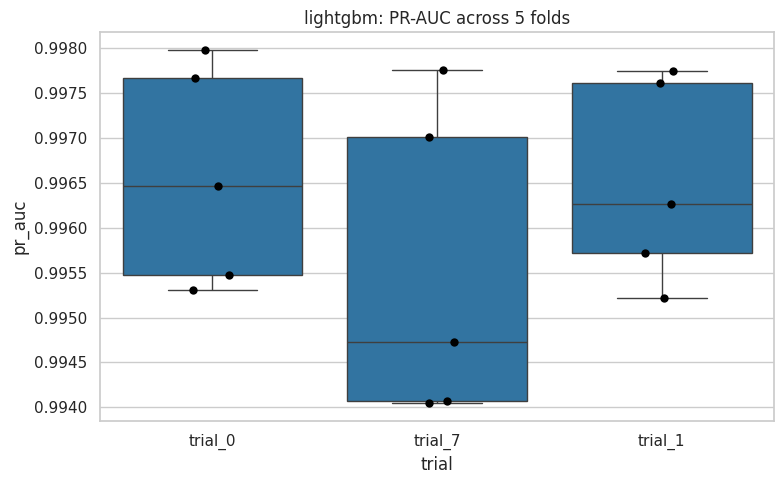

[22:40:08] lightgbm_cv -> completed | best_trial=trial_0


In [ ]:
# ============================================================
# SECTION 4.2.2 - LIGHTGBM: 5-FOLD CV ON THE TOP THREE TRIALS
# Built on CPU here: GPU histograms failed intermittently across
# repeated folds and the timings did not justify pursuing it.
# ============================================================
if 'study_lgb' not in dir():
    study_lgb = reload_study('lightgbm_trial_search')
    trials_df_lgb = study_lgb.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

def build_lgb(params):
    return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, device='cpu', n_jobs=-1, max_bin=255)

top3_lgb = trials_df_lgb.head(3)['number'].tolist()
candidate_trials_lgb = {f'trial_{t}': study_lgb.trials[t].params for t in top3_lgb}
print("Candidates (top 3 by validation PR-AUC):", list(candidate_trials_lgb.keys()))

cv_results_lgb, cv_summary_lgb, best_label_lgb = run_cv_for_candidates(
    'lightgbm', X_train, y_train, candidate_trials_lgb, build_lgb
)


#### 4.2.3 Final model and test-set evaluation


Best trial from CV: trial_0
[22:40:16] lightgbm_final_model -> started 
Using params:
{
  "n_estimators": 574,
  "max_depth": 12,
  "num_leaves": 115,
  "learning_rate": 0.030405325392865647,
  "subsample": 0.5780093202212182,
  "colsample_bytree": 0.5779972601681014,
  "min_child_samples": 10,
  "reg_alpha": 0.6245760287469893,
  "reg_lambda": 0.002570603566117598
}
SMOTE applied to full training set: {0: 5083526, 1: 5083526}
Model trained.

=== LightGBM: FINAL TEST RESULTS ===
  recall: 0.9976
  precision: 0.9664
  f1: 0.9817
  pr_auc: 0.9984
  roc_auc: 0.9998


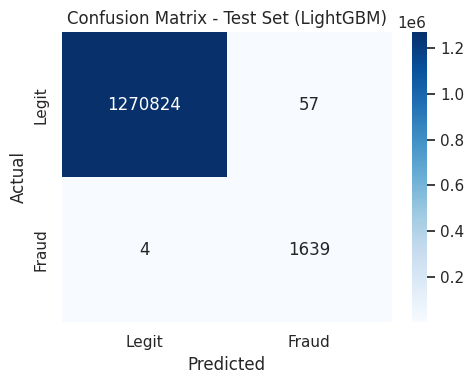

<Figure size 800x600 with 0 Axes>

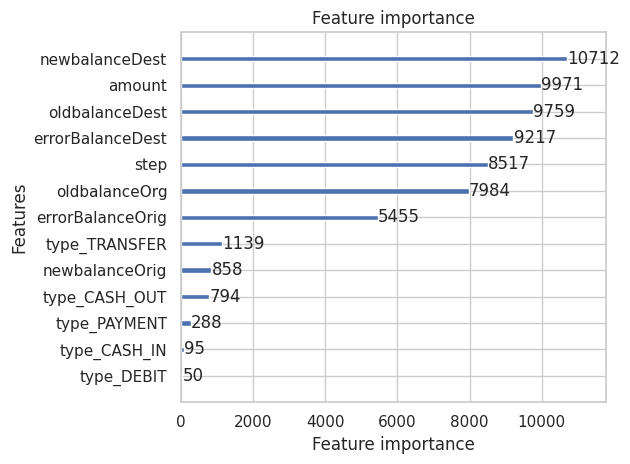

Model saved: /content/drive/MyDrive/Dissertation_ECGB/models/lightgbm_final.pkl
[22:51:41] lightgbm_final_model -> completed | test_pr_auc=0.99841


In [ ]:
# ============================================================
# SECTION 4.2.3 - LIGHTGBM FINAL MODEL (CV winner): TRAIN AND TEST
# ============================================================
if 'study_lgb' not in dir():
    study_lgb = reload_study('lightgbm_trial_search')

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

best_label_lgb = load_checkpoint('lightgbm_best_trial_label')
assert best_label_lgb is not None, "Run Section 4.2.2 (cross-validation) first."
best_trial_num_lgb = int(best_label_lgb.split('_')[1])
best_params_lgb = study_lgb.trials[best_trial_num_lgb].params
print(f"Best trial from CV: {best_label_lgb}")

def build_lgb(params):
    return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, device='cpu', n_jobs=-1, max_bin=255)

def lgb_feature_importance(model):
    plt.figure(figsize=(8, 6))
    lgb.plot_importance(model, max_num_features=13)
    plt.tight_layout()
    plt.savefig(f"{DIRS['figures']}/lightgbm_feature_importance.png", dpi=150)
    plt.show()

final_model_lgb, test_metrics_lgb = run_final_model(
    'lightgbm', 'LightGBM', X_train, y_train, X_test, y_test,
    build_lgb, best_params_lgb, feature_importance_fn=lgb_feature_importance
)


### 4.3 CatBoost

The same protocol again, trained on GPU. For the importance plot I use CatBoost's own
`PredictionValuesChange` measure, which is expressed as a percentage summing to 100,
rather than a generic `feature_importances_` bar chart. This is also the model I build
the DASH ensemble from in Section 7, so its tuned configuration is reused there.


#### 4.3.1 Hyperparameter search


In [ ]:
# ============================================================
# SECTION 4.3.1 - CATBOOST HYPERPARAMETER SEARCH
# Optuna, PR-AUC objective, early stopping with patience 100
# ============================================================
log_stage("catboost_trial_search", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
X_es_train, X_es_val, y_es_train, y_es_val = train_test_split(
    X_inner_train, y_inner_train, test_size=0.15, stratify=y_inner_train, random_state=SEED
)
print("Applying SMOTE to the early-stopping training split...")
X_es_train_sm, y_es_train_sm = SMOTE(random_state=SEED).fit_resample(X_es_train, y_es_train)
print("Done.")

def cb_objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 200, 1200),
        'depth':               trial.suggest_int('depth', 4, 10),
        'learning_rate':       trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'eval_metric':         'AUC',
        'early_stopping_rounds': 100,
        'random_state':        SEED,
        'verbose':             False,
        'task_type': 'GPU', 'devices': '0',
    }
    model = cb.CatBoostClassifier(**params)
    model.fit(X_es_train_sm, y_es_train_sm, eval_set=[(X_es_val, y_es_val)], verbose=False)
    y_proba = model.predict_proba(X_inner_val)[:, 1]
    metrics = evaluate_at_threshold(y_inner_val, y_proba)
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    trial.set_user_attr('best_iteration', model.get_best_iteration())
    return metrics['pr_auc']

study_cb = get_or_create_study('catboost_trial_search', n_trials_target=8, objective_fn=cb_objective)
trials_df_cb = show_trial_results(study_cb, 'catboost')
log_stage("catboost_trial_search", "completed", f"best_pr_auc={study_cb.best_value:.5f}")


[22:51:41] catboost_trial_search -> started 
Applying SMOTE to the early-stopping training split...
Done.


[I 2026-07-18 22:51:59,975] A new study created in RDB with name: catboost_trial_search


[catboost_trial_search] 0 trial(s) already done, running 8 more.


Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-07-18 22:52:20,585] Trial 0 finished with value: 0.9999971076453891 and parameters: {'iterations': 574, 'depth': 10, 'learning_rate': 0.06504856968981275, 'l2_leaf_reg': 0.24810409748678125, 'bagging_temperature': 0.15601864044243652, 'random_strength': 0.004207053950287938}. Best is trial 0 with value: 0.9999971076453891.


  Trial  0 | value=1.00000 | time=20.6s


...

  Trial  6 | value=0.99920 | time=15.3s


Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-07-18 22:54:15,987] Trial 7 finished with value: 1.0 and parameters: {'iterations': 234, 'depth': 10, 'learning_rate': 0.004375517173207359, 'l2_leaf_reg': 0.4467752817973907, 'bagging_temperature': 0.31171107608941095, 'random_strength': 0.12030178871154672}. Best is trial 1 with value: 1.0.


  Trial  7 | value=1.00000 | time=18.4s
  Best so far: trial #1, PR-AUC=1.00000

=== catboost: all trials, ranked by PR-AUC ===


,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength,user_attrs_best_iteration,user_attrs_f1,user_attrs_pr_auc,user_attrs_precision,user_attrs_recall,user_attrs_roc_auc,state
0,1,1.000000,2026-07-18 22:52:20.602377,2026-07-18 22:52:38.761247,0 days 00:00:18.158870,0.020584,10,258,0.679658,0.030834,7.579480,9,0.999620,1.000000,0.999240,1.000000,1.000000,COMPLETE
1,7,1.000000,2026-07-18 22:53:57.552438,2026-07-18 22:54:15.949319,0 days 00:00:18.396881,0.311711,10,234,0.446775,0.004376,0.120302,0,0.764398,1.000000,0.618644,1.000000,1.000000,COMPLETE
2,0,0.999997,2026-07-18 22:51:59.994088,2026-07-18 22:52:20.560343,0 days 00:00:20.566255,0.156019,10,574,0.248104,0.065049,0.004207,17,0.942611,0.999997,0.891452,1.000000,1.000000,COMPLETE
3,3,0.999989,2026-07-18 22:52:57.219970,2026-07-18 22:53:11.956345,0 days 00:00:14.736375,0.292145,6,632,0.003614,0.032782,0.029204,29,0.992822,0.999989,0.985746,1.000000,1.000000,COMPLETE
4,4,0.999963,2026-07-18 22:53:12.007693,2026-07-18 22:53:27.580448,0 days 00:00:15.572755,0.592415,9,656,0.114009,0.003123,0.001534,0,0.907145,0.999963,0.830069,1.000000,1.000000,COMPLETE
5,2,0.999891,2026-07-18 22:52:38.817997,2026-07-18 22:52:57.179122,0 days 00:00:18.361125,0.304242,5,1033,0.005415,0.002821,0.125610,114,0.974740,0.999891,0.952104,0.998478,1.000000,COMPLETE
6,6,0.999202,2026-07-18 22:53:42.241473,2026-07-18 22:53:57.509369,0 days 00:00:15.267896,0.122038,4,504,0.057625,0.049537,0.095655,60,0.997719,0.999202,0.996960,0.998478,0.999902,COMPLETE
7,5,0.998446,2026-07-18 22:53:27.613900,2026-07-18 22:53:42.200872,0 days 00:00:14.586972,0.965632,5,808,6.245140,0.001449,1.712338,32,0.987952,0.998446,0.977645,0.998478,0.999444,COMPLETE


[22:54:16] catboost_trial_search -> completed | best_pr_auc=1.00000


#### 4.3.2 Cross-validation of the top three trials


Candidates (top 3 by validation PR-AUC): ['trial_1', 'trial_7', 'trial_0']

--- CV for trial_1 ---
  Fold 1: recall=0.9970 precision=0.9066 f1=0.9496 pr_auc=0.9983
  Fold 2: recall=0.9947 precision=0.9450 f1=0.9692 pr_auc=0.9959
  Fold 3: recall=0.9954 precision=0.9465 f1=0.9703 pr_auc=0.9974
  Fold 4: recall=0.9977 precision=0.9252 f1=0.9601 pr_auc=0.9977
  Fold 5: recall=0.9954 precision=0.9343 f1=0.9639 pr_auc=0.9953
  --> Mean PR-AUC: 0.9969 +/- 0.0012

--- CV for trial_7 ---
  Fold 1: recall=0.9985 precision=0.8829 f1=0.9371 pr_auc=0.9984
  Fold 2: recall=0.9954 precision=0.9458 f1=0.9700 pr_auc=0.9954
  Fold 3: recall=0.9977 precision=0.8912 f1=0.9415 pr_auc=0.9974
  Fold 4: recall=0.9977 precision=0.8585 f1=0.9229 pr_auc=0.9973
  Fold 5: recall=0.9954 precision=0.9316 f1=0.9625 pr_auc=0.9952
  --> Mean PR-AUC: 0.9967 +/- 0.0014

--- CV for trial_0 ---
  Fold 1: recall=0.9970 precision=0.9364 f1=0.9657 pr_auc=0.9976
  Fold 2: recall=0.9947 precision=0.9376 f1=0.9653 pr_auc=0.9953

,recall,precision,f1,pr_auc,roc_auc,fold,trial
0,0.996956,0.906574,0.949619,0.998308,0.999799,1,trial_1
1,0.994673,0.945047,0.969225,0.995927,0.998848,2,trial_1
2,0.995434,0.946454,0.970326,0.997402,0.999486,3,trial_1
3,0.997717,0.925194,0.960088,0.997660,0.999631,4,trial_1
4,0.995434,0.934286,0.963891,0.995338,0.998930,5,trial_1
5,0.998478,0.882907,0.937143,0.998367,0.999682,1,trial_7
6,0.995434,0.945770,0.969967,0.995392,0.998689,2,trial_7
7,0.997717,0.891230,0.941472,0.997372,0.999565,3,trial_7
8,0.997717,0.858546,0.922914,0.997344,0.999701,4,trial_7
9,0.995434,0.931624,0.962472,0.995193,0.998559,5,trial_7


,trial,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,trial_1,0.996043,0.001251,0.931511,0.016401,0.962630,0.008367,0.996927,0.001245,0.999339,0.000426
1,trial_7,0.996956,0.001424,0.902016,0.035924,0.946794,0.019199,0.996734,0.001380,0.999239,0.000566
2,trial_0,0.995890,0.001382,0.948279,0.018273,0.971423,0.009134,0.996455,0.001185,0.999039,0.000658



Best by CV mean PR-AUC: trial_1


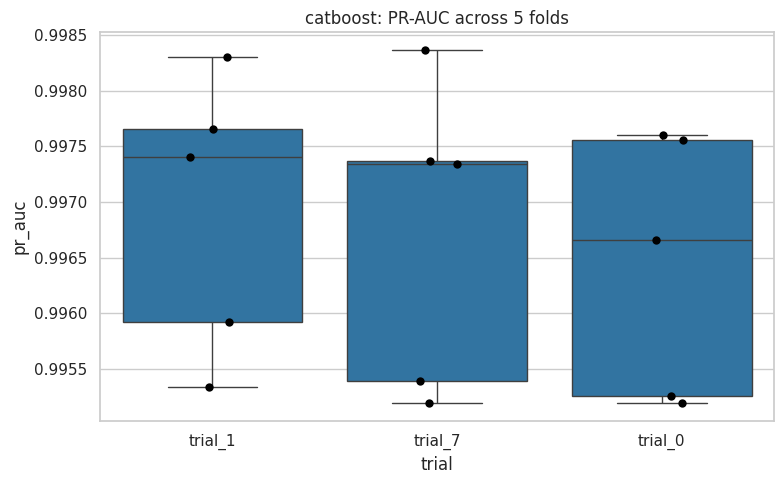

[23:08:38] catboost_cv -> completed | best_trial=trial_1


In [ ]:
# ============================================================
# SECTION 4.3.2 - CATBOOST: 5-FOLD CV ON THE TOP THREE TRIALS
# ============================================================
if 'study_cb' not in dir():
    study_cb = reload_study('catboost_trial_search')
    trials_df_cb = study_cb.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

def build_cb(params):
    return cb.CatBoostClassifier(**params, random_state=SEED, verbose=False, task_type='GPU', devices='0')

top3_cb = trials_df_cb.head(3)['number'].tolist()
candidate_trials_cb = {f'trial_{t}': study_cb.trials[t].params for t in top3_cb}
print("Candidates (top 3 by validation PR-AUC):", list(candidate_trials_cb.keys()))

cv_results_cb, cv_summary_cb, best_label_cb = run_cv_for_candidates(
    'catboost', X_train, y_train, candidate_trials_cb, build_cb
)


#### 4.3.3 Final model and test-set evaluation


Best trial from CV: trial_1
[23:08:45] catboost_final_model -> started 
Using params:
{
  "iterations": 258,
  "depth": 10,
  "learning_rate": 0.030834348179355788,
  "l2_leaf_reg": 0.679657809075816,
  "bagging_temperature": 0.020584494295802447,
  "random_strength": 7.579479953348009
}
SMOTE applied to full training set: {0: 5083526, 1: 5083526}
Model trained.

=== CatBoost: FINAL TEST RESULTS ===
  recall: 0.9976
  precision: 0.9414
  f1: 0.9687
  pr_auc: 0.9986
  roc_auc: 0.9996


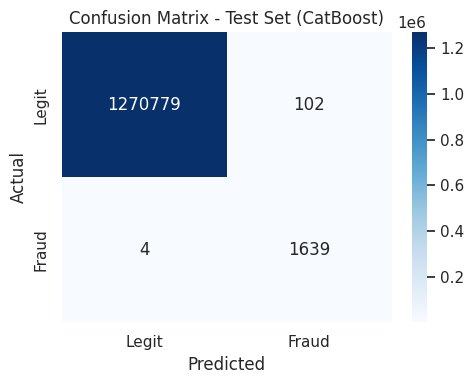

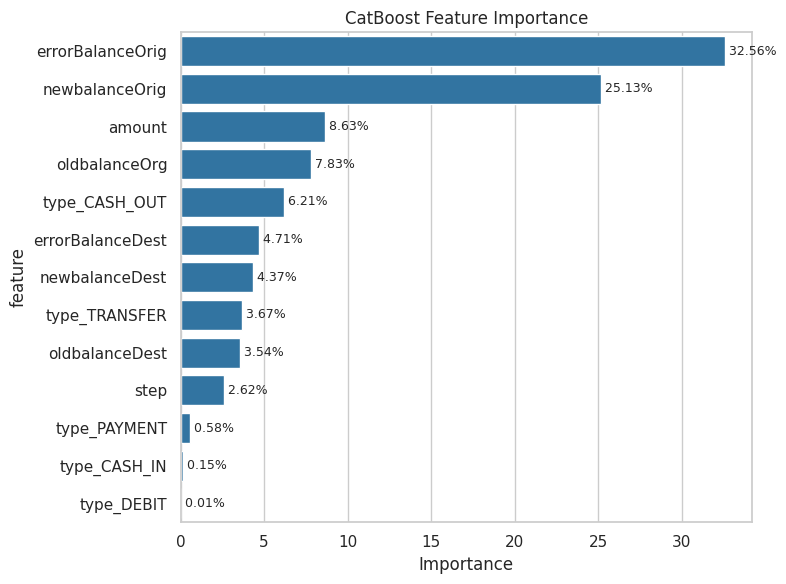

Model saved: /content/drive/MyDrive/Dissertation_ECGB/models/catboost_final.pkl
[23:09:42] catboost_final_model -> completed | test_pr_auc=0.99864


In [ ]:
# ============================================================
# SECTION 4.3.3 - CATBOOST FINAL MODEL (CV winner): TRAIN AND TEST
# This tuned configuration is also the base learner for DASH in Section 7.
# ============================================================
if 'study_cb' not in dir():
    study_cb = reload_study('catboost_trial_search')

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

best_label_cb = load_checkpoint('catboost_best_trial_label')
assert best_label_cb is not None, "Run Section 4.3.2 (cross-validation) first."
best_trial_num_cb = int(best_label_cb.split('_')[1])
best_params_cb = study_cb.trials[best_trial_num_cb].params
print(f"Best trial from CV: {best_label_cb}")

def build_cb(params):
    return cb.CatBoostClassifier(**params, random_state=SEED, verbose=False, task_type='GPU', devices='0')

def cb_feature_importance(model):
    feat_importance = model.get_feature_importance()
    plot_feature_importance(X_train.columns, feat_importance,
                             'CatBoost Feature Importance', 'catboost_feature_importance.png')

final_model_cb, test_metrics_cb = run_final_model(
    'catboost', 'CatBoost', X_train, y_train, X_test, y_test,
    build_cb, best_params_cb, feature_importance_fn=cb_feature_importance
)


### 4.4 Decision Tree

I include a single decision tree as the "no black box at all" baseline. It matters to
my argument: if a model that is interpretable by construction performs competitively,
that weakens the case for explaining a black box after the fact rather than avoiding
one in the first place.

Two implementation notes. Scikit-learn trees have no early stopping, so the search
needs only one inner train/validation split rather than the additional
early-stopping carve-out the boosting models require. And I deliberately leave
`class_weight` untuned at its default of `None`: every other model in this comparison
handles the imbalance through SMOTE, and letting the tree also use class weighting
would have introduced a confound I could not later separate from the model itself.


#### 4.4.1 Hyperparameter search


In [ ]:
# ============================================================
# SECTION 4.4.1 - DECISION TREE HYPERPARAMETER SEARCH
# No early stopping in sklearn trees, so this needs only one inner
# train/validation split rather than the boosting models' extra
# early-stopping carve-out.
# ============================================================
log_stage("dt_trial_search", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
print("Applying SMOTE to inner-train...")
X_inner_train_sm, y_inner_train_sm = SMOTE(random_state=SEED).fit_resample(X_inner_train, y_inner_train)
print("Done.")

def dt_objective(trial):
    params = {
        'max_depth':          trial.suggest_int('max_depth', 3, 30),
        'min_samples_split':  trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf':   trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features':       trial.suggest_float('max_features', 0.3, 1.0),
        'criterion':          trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'ccp_alpha':          trial.suggest_float('ccp_alpha', 1e-6, 1e-2, log=True),
        'random_state':       SEED,
    }
    try:
        model = DecisionTreeClassifier(**params)
        model.fit(X_inner_train_sm, y_inner_train_sm)
        y_proba = model.predict_proba(X_inner_val)[:, 1]
        metrics = evaluate_at_threshold(y_inner_val, y_proba)
        for k, v in metrics.items():
            trial.set_user_attr(k, v)
        return metrics['pr_auc']
    except Exception as e:
        print(f"  Trial {trial.number} FAILED ({type(e).__name__}) — skipping, scored as 0")
        return 0.0

study_dt = get_or_create_study('dt_trial_search', n_trials_target=16, objective_fn=dt_objective)
trials_df_dt = show_trial_results(study_dt, 'dt')
log_stage("dt_trial_search", "completed", f"best_pr_auc={study_dt.best_value:.5f}")


[23:09:42] dt_trial_search -> started 
Applying SMOTE to inner-train...
Done.


[I 2026-07-18 23:09:57,863] A new study created in RDB with name: dt_trial_search


[dt_trial_search] 0 trial(s) already done, running 16 more.


[I 2026-07-18 23:10:48,190] Trial 0 finished with value: 0.9984602479009699 and parameters: {'max_depth': 13, 'min_samples_split': 48, 'min_samples_leaf': 22, 'max_features': 0.7190609389379257, 'criterion': 'gini', 'ccp_alpha': 1.7073967431528114e-06}. Best is trial 0 with value: 0.9984602479009699.


  Trial  0 | value=0.99846 | time=50.3s


...

  Trial 14 | value=0.99281 | time=55.7s


[I 2026-07-18 23:20:41,412] Trial 15 finished with value: 0.9999606196695854 and parameters: {'max_depth': 14, 'min_samples_split': 40, 'min_samples_leaf': 15, 'max_features': 0.4766352236654229, 'criterion': 'gini', 'ccp_alpha': 3.6289710147481236e-05}. Best is trial 15 with value: 0.9999606196695854.


  Trial 15 | value=0.99996 | time=33.1s
  Best so far: trial #15, PR-AUC=0.99996

=== dt: all trials, ranked by PR-AUC ===


,number,value,datetime_start,datetime_complete,duration,params_ccp_alpha,params_criterion,params_max_depth,params_max_features,params_min_samples_leaf,params_min_samples_split,user_attrs_f1,user_attrs_pr_auc,user_attrs_precision,user_attrs_recall,user_attrs_roc_auc,state
0,15,0.999961,2026-07-18 23:20:08.295088,2026-07-18 23:20:41.386826,0 days 00:00:33.091738,0.000036,gini,14,0.476635,15,40,0.856584,0.999961,0.749145,1.000000,1.000000,COMPLETE
1,13,0.999593,2026-07-18 23:18:38.609935,2026-07-18 23:19:12.475595,0 days 00:00:33.865660,0.000011,gini,14,0.527600,17,41,0.877462,0.999593,0.781678,1.000000,1.000000,COMPLETE
2,0,0.998460,2026-07-18 23:09:57.874720,2026-07-18 23:10:48.162233,0 days 00:00:50.287513,0.000002,gini,13,0.719061,22,48,0.905452,0.998460,0.828283,0.998478,0.999392,COMPLETE
3,1,0.998443,2026-07-18 23:10:48.208398,2026-07-18 23:11:15.933647,0 days 00:00:27.725249,0.000007,gini,27,0.314409,22,31,0.872340,0.998443,0.774498,0.998478,0.998662,COMPLETE
4,12,0.998406,2026-07-18 23:17:46.542994,2026-07-18 23:18:38.571134,0 days 00:00:52.028140,0.000009,gini,21,0.828253,29,32,0.879357,0.998406,0.785629,0.998478,0.998931,COMPLETE
5,5,0.998296,2026-07-18 23:12:57.575401,2026-07-18 23:13:56.489361,0 days 00:00:58.913960,0.000096,gini,25,0.778963,3,16,0.951759,0.998296,0.909217,0.998478,0.998820,COMPLETE
6,3,0.997901,2026-07-18 23:11:57.908733,2026-07-18 23:12:33.591342,0 days 00:00:35.682609,0.000114,gini,6,0.619249,11,16,0.913649,0.997901,0.842105,0.998478,0.999256,COMPLETE
7,7,0.997900,2026-07-18 23:14:32.995072,2026-07-18 23:15:29.689719,0 days 00:00:56.694647,0.004870,gini,8,0.957649,24,49,0.987208,0.997900,0.976190,0.998478,0.998819,COMPLETE
8,8,0.997900,2026-07-18 23:15:29.726918,2026-07-18 23:15:53.721333,0 days 00:00:23.994415,0.002065,gini,5,0.527731,2,11,0.987208,0.997900,0.976190,0.998478,0.998807,COMPLETE
9,2,0.997676,2026-07-18 23:11:15.971269,2026-07-18 23:11:57.864758,0 days 00:00:41.893489,0.000280,gini,8,0.667330,10,10,0.935806,0.997676,0.880537,0.998478,0.999256,COMPLETE


[23:20:42] dt_trial_search -> completed | best_pr_auc=0.99996


#### 4.4.2 Cross-validation of the top three trials


Candidates (top 3 by validation PR-AUC): ['trial_15', 'trial_13', 'trial_0']

--- CV for trial_15 ---
  Fold 1: recall=0.9977 precision=0.7353 f1=0.8466 pr_auc=0.9973
  Fold 2: recall=0.9947 precision=0.8570 f1=0.9207 pr_auc=0.9947
  Fold 3: recall=0.9962 precision=0.6879 f1=0.8138 pr_auc=0.9949
  Fold 4: recall=0.9985 precision=0.8180 f1=0.8992 pr_auc=0.9980
  Fold 5: recall=0.9962 precision=0.8396 f1=0.9112 pr_auc=0.9937
  --> Mean PR-AUC: 0.9957 +/- 0.0018

--- CV for trial_13 ---
  Fold 1: recall=0.9970 precision=0.8147 f1=0.8966 pr_auc=0.9970
  Fold 2: recall=0.9947 precision=0.8004 f1=0.8870 pr_auc=0.9947
  Fold 3: recall=0.9954 precision=0.7927 f1=0.8826 pr_auc=0.9958
  Fold 4: recall=0.9977 precision=0.8118 f1=0.8952 pr_auc=0.9977
  Fold 5: recall=0.9954 precision=0.8247 f1=0.9021 pr_auc=0.9938
  --> Mean PR-AUC: 0.9958 +/- 0.0016

--- CV for trial_0 ---
  Fold 1: recall=0.9977 precision=0.8009 f1=0.8885 pr_auc=0.9978
  Fold 2: recall=0.9962 precision=0.8105 f1=0.8938 pr_auc=0.

,recall,precision,f1,pr_auc,roc_auc,fold,trial
0,0.997717,0.735278,0.846626,0.997330,0.999400,1,trial_15
1,0.994673,0.857049,0.920747,0.994708,0.999072,2,trial_15
2,0.996195,0.687861,0.813802,0.994920,0.998428,3,trial_15
3,0.998478,0.817955,0.899246,0.998030,0.999640,4,trial_15
4,0.996195,0.839641,0.911243,0.993722,0.998467,5,trial_15
5,0.996956,0.814677,0.896646,0.997018,0.998461,1,trial_13
6,0.994673,0.800367,0.887004,0.994741,0.998537,2,trial_13
7,0.995434,0.792727,0.882591,0.995801,0.998560,3,trial_13
8,0.997717,0.811765,0.895186,0.997719,0.999074,4,trial_13
9,0.995434,0.824716,0.902069,0.993786,0.997681,5,trial_13


,trial,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,trial_15,0.996651,0.001484,0.787557,0.072695,0.878333,0.046068,0.995742,0.001843,0.999001,0.000545
1,trial_13,0.996043,0.001251,0.808850,0.012511,0.892699,0.007813,0.995813,0.001608,0.998463,0.000500
2,trial_0,0.996347,0.001361,0.834626,0.047142,0.907752,0.027123,0.995107,0.002397,0.998595,0.001000



Best by CV mean PR-AUC: trial_13


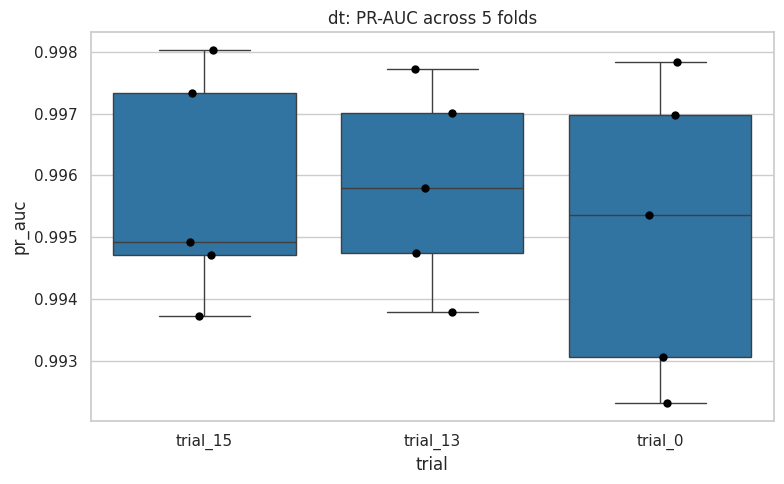

[23:32:50] dt_cv -> completed | best_trial=trial_13


In [ ]:
# ============================================================
# SECTION 4.4.2 - DECISION TREE: 5-FOLD CV ON THE TOP THREE TRIALS
# ============================================================
if 'study_dt' not in dir():
    study_dt = reload_study('dt_trial_search')
    trials_df_dt = study_dt.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

def build_dt(params):
    return DecisionTreeClassifier(**params, random_state=SEED)

top3_dt = trials_df_dt.head(3)['number'].tolist()
candidate_trials_dt = {f'trial_{t}': study_dt.trials[t].params for t in top3_dt}
print("Candidates (top 3 by validation PR-AUC):", list(candidate_trials_dt.keys()))

cv_results_dt, cv_summary_dt, best_label_dt = run_cv_for_candidates(
    'dt', X_train, y_train, candidate_trials_dt, build_dt
)


#### 4.4.3 Final model and test-set evaluation


Best trial from CV: trial_13
[23:32:58] dt_final_model -> started 
Using params:
{
  "max_depth": 14,
  "min_samples_split": 41,
  "min_samples_leaf": 17,
  "max_features": 0.5275997737526593,
  "criterion": "gini",
  "ccp_alpha": 1.1450371128880509e-05
}
SMOTE applied to full training set: {0: 5083526, 1: 5083526}
Model trained.

=== DecisionTree: FINAL TEST RESULTS ===
  recall: 0.9982
  precision: 0.8691
  f1: 0.9292
  pr_auc: 0.9980
  roc_auc: 0.9993


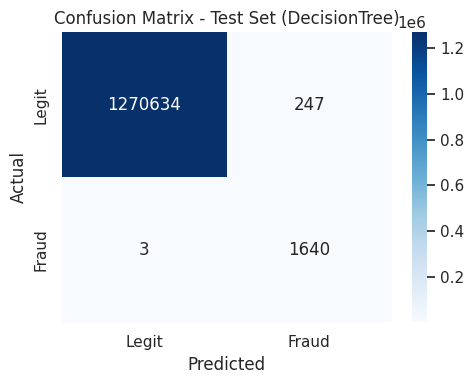

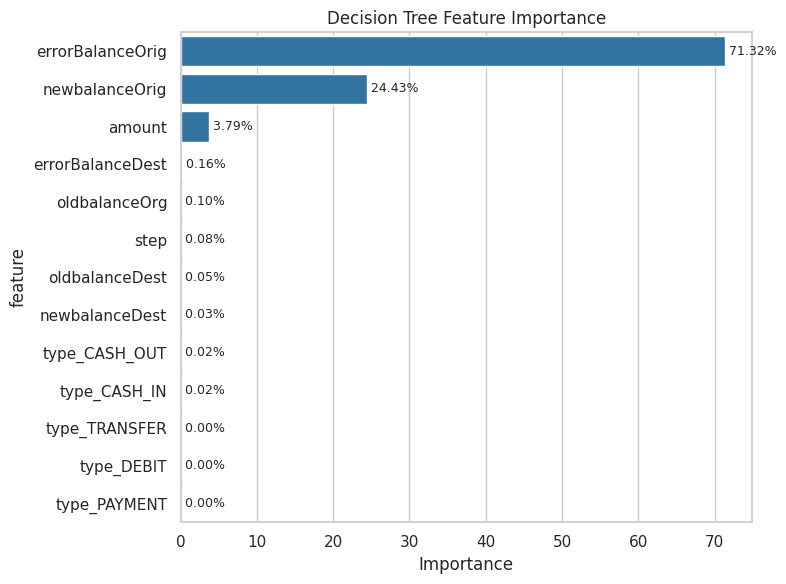

Model saved: /content/drive/MyDrive/Dissertation_ECGB/models/dt_final.pkl
[23:33:53] dt_final_model -> completed | test_pr_auc=0.99801


In [ ]:
# ============================================================
# SECTION 4.4.3 - DECISION TREE FINAL MODEL (CV winner): TRAIN AND TEST
# ============================================================
if 'study_dt' not in dir():
    study_dt = reload_study('dt_trial_search')

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

best_label_dt = load_checkpoint('dt_best_trial_label')
assert best_label_dt is not None, "Run Section 4.4.2 (cross-validation) first."
best_trial_num_dt = int(best_label_dt.split('_')[1])
best_params_dt = study_dt.trials[best_trial_num_dt].params
print(f"Best trial from CV: {best_label_dt}")

def build_dt(params):
    return DecisionTreeClassifier(**params, random_state=SEED)

def dt_feature_importance(model):
    plot_feature_importance(X_train.columns, model.feature_importances_ * 100,
                             'Decision Tree Feature Importance', 'dt_feature_importance.png')

final_model_dt, test_metrics_dt = run_final_model(
    'dt', 'DecisionTree', X_train, y_train, X_test, y_test,
    build_dt, best_params_dt, feature_importance_fn=dt_feature_importance
)


### 4.5 MLP (Neural Network)

The MLP is the only non-tree model in my comparison. I added it so that the final
leaderboard contains a genuine neural baseline alongside the boosting models, and so
that my explanation-consistency analysis is not confined to models that a
`TreeExplainer` can handle. Two things make it behave differently from everything
above.

**Scaling matters.** Gradient boosting is invariant to monotonic rescaling of the
features; a neural network is not, and PaySim's `amount` and balance columns span
many orders of magnitude. Every MLP here is therefore a
`Pipeline([StandardScaler, MLPClassifier])`, with the scaler re-fitted inside each
cross-validation fold and on the resampled training set, never on the test set.
Wrapping it in a `Pipeline` has the useful side effect that it exposes the same
`.fit` / `.predict_proba` interface as the other models, so it drops into my shared
`run_cv_for_candidates` and `run_final_model` helpers without modification.

**No native feature importances.** In their place I use permutation importance on a
5,000-row test-set sample: shuffle one column at a time and measure the resulting
drop in PR-AUC. This is model-agnostic and fair to the MLP, and it plots on the same
axes as the other models' importance charts.

The `early_stopping=True` setting inside `MLPClassifier` is scikit-learn's own
held-out-fraction early stopping, and is independent of Optuna's trial budget.


#### 4.5.1 Hyperparameter search

The MLP is the one model in this pipeline that scikit-learn cannot comfortably fit at
full data scale, so for the search phase only I subsample the resampled training set
to one million rows and downcast to `float32`. My reasoning is that the search only
has to *rank* configurations against one another, which a representative subsample
does perfectly well, and the final model is trained on the full data regardless.

I also free each trial's model explicitly before the next begins. Without that, memory
accumulated across trials until the session was terminated.


In [ ]:
# ============================================================
# SECTION 4.5.1 - MLP HYPERPARAMETER SEARCH
# Layer sizes are searched as string labels because Optuna cannot store
# tuples as categorical values; float32 downcasting, subsampling and
# per-trial cleanup are all here to keep the session inside its memory
# budget, for the reasons noted below.
# ============================================================
import gc

log_stage("mlp_trial_search_v2", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
print("Applying SMOTE to inner-train...")
X_inner_train_sm, y_inner_train_sm = SMOTE(random_state=SEED).fit_resample(X_inner_train, y_inner_train)
print(f"Done. Shape before downcast: {X_inner_train_sm.shape}")

# --- float32 rather than float64 halves the memory the scaler and the MLP's
# internal buffers need, at no cost to results at this precision. ---
X_inner_train_sm = X_inner_train_sm.astype(np.float32)
X_inner_val = X_inner_val.astype(np.float32)

# --- Subsample for the search phase only. The search has to rank
# configurations against one another, which does not require all 8M rows,
# and sklearn's MLP is the one model here not built for this data scale. The
# final model is still trained on the full training set, so nothing I report
# depends on this subsample.
MLP_SEARCH_SAMPLE_SIZE = 1_000_000
if len(X_inner_train_sm) > MLP_SEARCH_SAMPLE_SIZE:
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_inner_train_sm), size=MLP_SEARCH_SAMPLE_SIZE, replace=False)
    X_inner_train_sm = X_inner_train_sm.iloc[idx] if hasattr(X_inner_train_sm, 'iloc') else X_inner_train_sm[idx]
    y_inner_train_sm = y_inner_train_sm.iloc[idx] if hasattr(y_inner_train_sm, 'iloc') else y_inner_train_sm[idx]
    print(f"Subsampled to {MLP_SEARCH_SAMPLE_SIZE} rows for trial search.")

MLP_FIXED = dict(early_stopping=True, n_iter_no_change=15, validation_fraction=0.1,
                  max_iter=300, random_state=SEED)

HIDDEN_LAYER_CHOICES = {
    '64':        (64,),
    '128':       (128,),
    '64_32':     (64, 32),
    '128_64':    (128, 64),
    '128_64_32': (128, 64, 32),
}

def build_mlp(params):
    params = params.copy()
    hls_label = params.pop('hidden_layer_sizes')
    hidden_layer_sizes = HIDDEN_LAYER_CHOICES[hls_label]
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, **params, **MLP_FIXED)),
    ])

def mlp_objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', list(HIDDEN_LAYER_CHOICES.keys())),
        'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':              trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'batch_size':         trial.suggest_categorical('batch_size', [128, 256, 512]),
    }
    pipe = None
    try:
        pipe = build_mlp(params)
        pipe.fit(X_inner_train_sm, y_inner_train_sm)
        y_proba = pipe.predict_proba(X_inner_val)[:, 1]
        metrics = evaluate_at_threshold(y_inner_val, y_proba)
        for k, v in metrics.items():
            trial.set_user_attr(k, v)
        trial.set_user_attr('n_iter', pipe.named_steps['mlp'].n_iter_)
        return metrics['pr_auc']
    except Exception as e:
        print(f"  Trial {trial.number} FAILED ({type(e).__name__}) -- skipping, scored as 0")
        return 0.0
    finally:
        # --- Free this trial's model before the next begins. Without this,
        # memory accumulated across trials until the session was killed. ---
        del pipe
        gc.collect()

study_mlp = get_or_create_study('mlp_trial_search_v2', n_trials_target=8, objective_fn=mlp_objective)
trials_df_mlp = show_trial_results(study_mlp, 'mlp_v2', slice_plot=False)
log_stage("mlp_trial_search_v2", "completed", f"best_pr_auc={study_mlp.best_value:.5f}")


[21:38:20] mlp_trial_search_v2 -> started 
Applying SMOTE to inner-train...
Done. Shape before downcast: (8133640, 13)
Subsampled to 1000000 rows for trial search.


[I 2026-07-19 21:38:52,572] Using an existing study with name 'mlp_trial_search_v2' instead of creating a new one.


[mlp_trial_search_v2] 8 trial(s) already done, running 0 more.
  Target trial count already reached — nothing to run.
  Best so far: trial #1, PR-AUC=0.95694

=== mlp_v2: all trials, ranked by PR-AUC ===


,number,value,datetime_start,datetime_complete,duration,params_activation,params_alpha,params_batch_size,params_hidden_layer_sizes,params_learning_rate_init,user_attrs_f1,user_attrs_n_iter,user_attrs_pr_auc,user_attrs_precision,user_attrs_recall,user_attrs_roc_auc,state
0,1,0.956938,2026-07-19 09:58:07.364014,2026-07-19 10:18:50.237117,0 days 00:20:42.873103,relu,0.000029,512,64,0.001674,0.490446,34.0,0.956938,0.325298,0.996195,0.999155,COMPLETE
1,7,0.924165,2026-07-19 21:28:21.611831,2026-07-19 21:30:25.508817,0 days 00:02:03.896986,relu,0.000029,512,64,0.001674,0.374732,56.0,0.924165,0.230688,0.997717,0.999825,COMPLETE
2,2,0.915915,2026-07-19 10:18:50.298064,2026-07-19 10:55:01.193182,0 days 00:36:10.895118,tanh,0.000007,256,128,0.000135,0.261716,80.0,0.915915,0.150734,0.992390,0.998657,COMPLETE
3,0,0.883905,2026-07-19 07:42:48.661849,2026-07-19 09:58:07.301949,0 days 02:15:18.640100,relu,0.021423,512,128,0.001593,0.215997,46.0,0.883905,0.121153,0.994673,0.998915,COMPLETE
4,3,0.883214,2026-07-19 10:55:01.231600,2026-07-19 13:08:31.122171,0 days 02:13:29.890571,relu,0.035205,128,64_32,0.000329,0.185561,35.0,0.883214,0.102325,0.994673,0.998851,COMPLETE
5,6,0.863400,2026-07-19 21:23:48.243826,2026-07-19 21:28:21.560666,0 days 00:04:33.316840,relu,0.021423,512,128,0.001593,0.213406,27.0,0.863400,0.119613,0.988584,0.998784,COMPLETE
6,4,NaN,2026-07-19 13:08:31.158347,NaT,NaT,relu,0.040679,512,64_32,0.000150,NaN,NaN,NaN,NaN,NaN,NaN,RUNNING
7,5,NaN,2026-07-19 19:38:41.493084,NaT,NaT,relu,0.021423,512,128,0.001593,NaN,NaN,NaN,NaN,NaN,NaN,RUNNING


[21:38:55] mlp_trial_search_v2 -> completed | best_pr_auc=0.95694


#### 4.5.2 Cross-validation of the top three trials

The same subsampling reasoning applies here, and for the same reason: cross-validation
is comparing three configurations against each other, not producing the number I
report.


Subsampled X_train to 1000000 rows for MLP CV.
Candidates (top 3 by validation PR-AUC): ['trial_1', 'trial_7', 'trial_2']

--- CV for trial_1 ---
  Fold 1: recall=0.9835 precision=0.4275 f1=0.5960 pr_auc=0.9453
  Fold 2: recall=0.9753 precision=0.3035 f1=0.4629 pr_auc=0.9419
  Fold 3: recall=0.9918 precision=0.2503 f1=0.3997 pr_auc=0.9527
  Fold 4: recall=0.9836 precision=0.2727 f1=0.4270 pr_auc=0.9101
  Fold 5: recall=0.9713 precision=0.2351 f1=0.3786 pr_auc=0.9227
  --> Mean PR-AUC: 0.9345 +/- 0.0175

--- CV for trial_7 ---
  Fold 1: recall=0.9835 precision=0.4275 f1=0.5960 pr_auc=0.9453
  Fold 2: recall=0.9753 precision=0.3035 f1=0.4629 pr_auc=0.9419
  Fold 3: recall=0.9918 precision=0.2503 f1=0.3997 pr_auc=0.9527
  Fold 4: recall=0.9836 precision=0.2727 f1=0.4270 pr_auc=0.9101
  Fold 5: recall=0.9713 precision=0.2351 f1=0.3786 pr_auc=0.9227
  --> Mean PR-AUC: 0.9345 +/- 0.0175

--- CV for trial_2 ---
  Fold 1: recall=0.9918 precision=0.1477 f1=0.2571 pr_auc=0.9129
  Fold 2: recall=

,recall,precision,f1,pr_auc,roc_auc,fold,trial
0,0.983539,0.427549,0.596010,0.945294,0.998326,1,trial_1
1,0.975309,0.303457,0.462891,0.941854,0.989751,2,trial_1
2,0.991770,0.250260,0.399668,0.952662,0.999543,3,trial_1
3,0.983607,0.272727,0.427046,0.910148,0.999765,4,trial_1
4,0.971311,0.235119,0.378594,0.922733,0.996877,5,trial_1
5,0.983539,0.427549,0.596010,0.945294,0.998326,1,trial_7
6,0.975309,0.303457,0.462891,0.941854,0.989751,2,trial_7
7,0.991770,0.250260,0.399668,0.952662,0.999543,3,trial_7
8,0.983607,0.272727,0.427046,0.910148,0.999765,4,trial_7
9,0.971311,0.235119,0.378594,0.922733,0.996877,5,trial_7


,trial,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,trial_1,0.981107,0.007991,0.297822,0.076949,0.452842,0.086029,0.934538,0.017549,0.996852,0.004133
1,trial_7,0.981107,0.007991,0.297822,0.076949,0.452842,0.086029,0.934538,0.017549,0.996852,0.004133
2,trial_2,0.982760,0.011722,0.117718,0.018128,0.209899,0.028672,0.896942,0.015485,0.996537,0.003967



Best by CV mean PR-AUC: trial_1


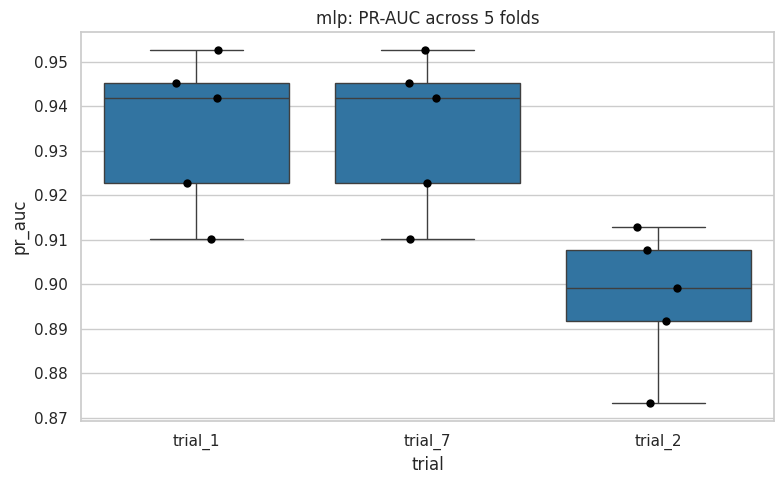

[23:29:42] mlp_cv -> completed | best_trial=trial_1


In [ ]:
# ============================================================
# SECTION 4.5.2 - MLP: 5-FOLD CV ON THE TOP THREE TRIALS
# ============================================================
if 'study_mlp' not in dir():
    study_mlp = reload_study('mlp_trial_search_v2')
    trials_df_mlp = study_mlp.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

# --- float32 again, for the same memory reason as the search cell. ---
X_train = X_train.astype(np.float32)

# --- Subsample for cross-validation. The MLP is the only model here that
# cannot hold full-scale resampled folds in memory, and this stage is again
# only ranking three configurations against each other, so a representative
# subsample is sufficient for the comparison it has to make.
MLP_CV_SAMPLE_SIZE = 1_000_000
if len(X_train) > MLP_CV_SAMPLE_SIZE:
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_train), size=MLP_CV_SAMPLE_SIZE, replace=False)
    X_train = X_train.iloc[idx].reset_index(drop=True)
    y_train = y_train.iloc[idx].reset_index(drop=True)
    print(f"Subsampled X_train to {MLP_CV_SAMPLE_SIZE} rows for MLP CV.")

MLP_FIXED = dict(early_stopping=True, n_iter_no_change=15, validation_fraction=0.1,
                  max_iter=300, random_state=SEED)

HIDDEN_LAYER_CHOICES = {
    '64':        (64,),
    '128':       (128,),
    '64_32':     (64, 32),
    '128_64':    (128, 64),
    '128_64_32': (128, 64, 32),
}

def build_mlp(params):
    params = params.copy()
    hls_label = params.pop('hidden_layer_sizes')
    hidden_layer_sizes = HIDDEN_LAYER_CHOICES[hls_label]
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, **params, **MLP_FIXED)),
    ])

top3_mlp = trials_df_mlp.head(3)['number'].tolist()
candidate_trials_mlp = {f'trial_{t}': study_mlp.trials[t].params for t in top3_mlp}
print("Candidates (top 3 by validation PR-AUC):", list(candidate_trials_mlp.keys()))

cv_results_mlp, cv_summary_mlp, best_label_mlp = run_cv_for_candidates(
    'mlp', X_train, y_train, candidate_trials_mlp, build_mlp
)


#### 4.5.3 Final model and test-set evaluation


Best trial from CV: trial_1
[23:29:56] mlp_final_model -> started 
Using params:
{
  "hidden_layer_sizes": "64",
  "activation": "relu",
  "alpha": 2.8585493941961936e-05,
  "learning_rate_init": 0.0016738085788752138,
  "batch_size": 512
}
SMOTE applied to full training set: {0: 5083526, 1: 5083526}
Model trained.

=== MLP: FINAL TEST RESULTS ===
  recall: 0.9927
  precision: 0.2883
  f1: 0.4468
  pr_auc: 0.9643
  roc_auc: 0.9992


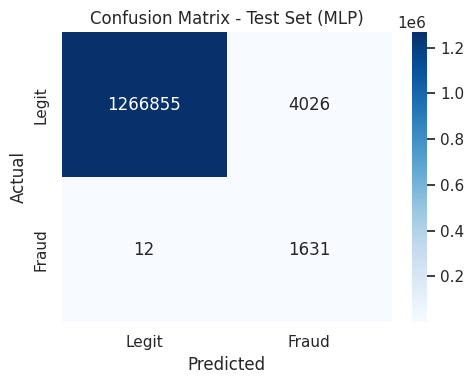

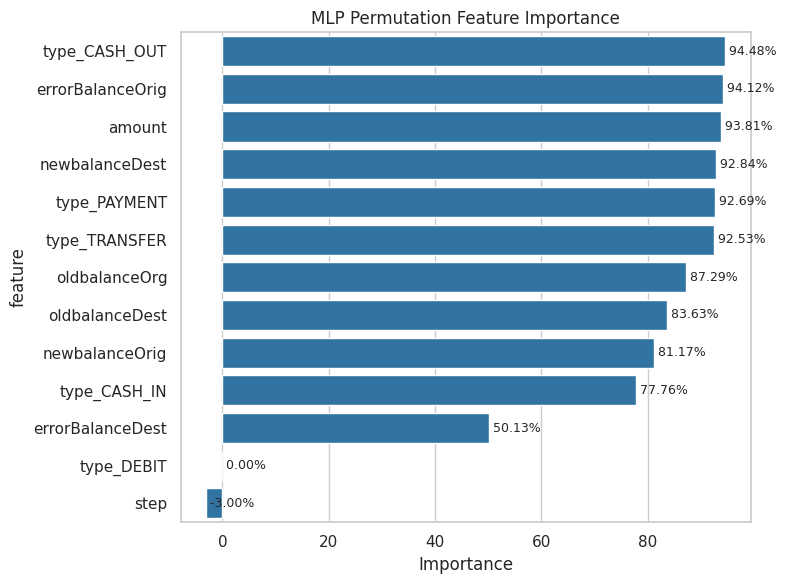

Model saved: /content/drive/MyDrive/Dissertation_ECGB/models/mlp_final.pkl
[00:03:29] mlp_final_model -> completed | test_pr_auc=0.96434


In [ ]:
# ============================================================
# SECTION 4.5.3 - MLP FINAL MODEL (CV winner): TRAIN AND TEST
# ============================================================
if 'study_mlp' not in dir():
    study_mlp = reload_study('mlp_trial_search_v2')

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

best_label_mlp = load_checkpoint('mlp_best_trial_label')
assert best_label_mlp is not None, "Run Section 4.5.2 (cross-validation) first."
best_trial_num_mlp = int(best_label_mlp.split('_')[1])
best_params_mlp = study_mlp.trials[best_trial_num_mlp].params
print(f"Best trial from CV: {best_label_mlp}")

MLP_FIXED = dict(early_stopping=True, n_iter_no_change=15, validation_fraction=0.1,
                  max_iter=300, random_state=SEED)

HIDDEN_LAYER_CHOICES = {
    '64':        (64,),
    '128':       (128,),
    '64_32':     (64, 32),
    '128_64':    (128, 64),
    '128_64_32': (128, 64, 32),
}

def build_mlp(params):
    params = params.copy()
    hls_label = params.pop('hidden_layer_sizes')
    hidden_layer_sizes = HIDDEN_LAYER_CHOICES[hls_label]
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, **params, **MLP_FIXED)),
    ])

def mlp_feature_importance(model):
    """The MLP has no native feature_importances_, so I use permutation
    importance instead: shuffle one column of a 5,000-row test sample, measure
    the drop in PR-AUC, repeat five times per column and average. It is
    model-agnostic, fair to the MLP, and plots on the same axes as the other
    models' importance charts."""
    sample_idx = X_test.sample(n=min(5000, len(X_test)), random_state=SEED).index
    result = permutation_importance(
        model, X_test.loc[sample_idx], y_test.loc[sample_idx],
        scoring='average_precision', n_repeats=5, random_state=SEED, n_jobs=-1
    )
    plot_feature_importance(X_test.columns, result.importances_mean * 100,
                             'MLP Permutation Feature Importance', 'mlp_feature_importance.png')

final_model_mlp, test_metrics_mlp = run_final_model(
    'mlp', 'MLP', X_train, y_train, X_test, y_test,
    build_mlp, best_params_mlp, feature_importance_fn=mlp_feature_importance
)


## 5. ECGB / CRGB — Explanation-Consistent Gradient Boosting

This section contains the actual contribution of the dissertation. ECGB is gradient
boosting with an explanation-consistency penalty added to the training objective
alongside the usual logistic loss. Every synthetic row that SMOTE generates is paired
with the real minority row it was derived from, and the penalty pulls the model's
prediction for the synthetic row toward the prediction for its parent. The intention
is a model that does not merely predict well, but explains similar transactions
similarly — with that property arising from training rather than from post-hoc
smoothing.

I work through five steps, in this order:

1. **Core** — the SMOTE-with-pairing routine and the custom training objective.
   Everything below depends on these definitions, so this is the first cell to re-run
   after any restart.
2. **Hyperparameter search** — Optuna tunes the boosting parameters together with the
   strength of the consistency penalty, `lambda_consistency`.
3. **Ablation** — the essential test of whether the penalty is doing anything at all,
   comparing the tuned penalty against `lambda_consistency = 0` (that is, ordinary
   boosting on identical data) for the three best trials.
4. **Cross-validation** — 5-fold cross-validation of the winning configuration.
5. **Final model** — trained on the full training set and scored on the held-out test
   set.

**Two implementation problems I had to solve.**

I record these because both materially affected my results and because the second
changed a conclusion I had initially drawn.

**Early stopping was inverted.** My first implementation trained only zero to three
trees regardless of the configuration, and it took me some time to find the cause.
`xgb.train()` was using my custom PR-AUC function for early stopping, and I had not
passed `maximize=True`. XGBoost assumes a custom metric is to be *minimised* unless
told otherwise, so early stopping was comparing PR-AUC in the wrong direction and
abandoning training almost immediately. Every call below now passes `maximize=True`.
It is a one-word difference between a model that trained three trees and one that
trained properly.

**Ranking by PR-AUC alone selected a degenerate model.** My original selection step
sorted candidate trials by raw PR-AUC, and on one run this chose a trial with a
PR-AUC of 0.997 but a precision of 0.028 — a model flagging almost every transaction
as fraud. PR-AUC is threshold-independent and so does not penalise that behaviour at
the operating threshold I actually deploy at. I now require a minimum precision
before ranking the survivors by F1.


### 5.1 Core: SMOTE with pairing, and the custom objective

Two functions do the substantive work of this contribution.

`smote_with_pairing` runs SMOTE and then, for every synthetic minority row, finds its
nearest real minority neighbour. That correspondence is what the penalty operates on
— without knowing which real fraud case each synthetic row descends from, there is
nothing to enforce consistency against.

`crgb_obj_factory` builds the custom XGBoost objective: the standard logistic-loss
gradient and Hessian, plus a term that pulls each synthetic row's predicted margin
toward its paired parent's margin, with `lam` controlling the strength of that pull.

I set `sampling_strategy=0.1` rather than fully balancing the classes. This was
forced on me by memory: fully balancing a multi-million-row dataset, five times over
for cross-validation, exhausted the available RAM. At 10% I retain most of the
benefit at a fraction of the cost, and I apply the same setting consistently
everywhere the pairing is used so the comparison remains fair.


In [ ]:
# ============================================================
# SECTION 5.1 - ECGB CORE: SMOTE-WITH-PAIRING AND THE CUSTOM OBJECTIVE
# These two functions are the substance of the contribution. Re-run this
# cell first after any restart; everything in Section 5 depends on it.
# ============================================================
log_stage("crgb_core", "started")

def smote_with_pairing(X, y, seed=SEED, sampling_strategy=0.1):
    """Run SMOTE, then find the nearest real minority neighbour of every
    synthetic row, so that I know which real fraud case each synthetic row was
    derived from. That correspondence is what the consistency penalty acts on:
    without it there is nothing to enforce consistency against.

    I set sampling_strategy=0.1 rather than balancing the classes fully. This
    was forced on me by memory - fully balancing a multi-million-row dataset,
    five times over for cross-validation, exhausted the available RAM. At 10%
    I keep most of the benefit at a fraction of the cost, and I use the same
    setting everywhere the pairing is used so the comparison stays fair.

    Returns the resampled X and y; pair_idx, the index of each row's paired
    real minority instance, with real rows paired to themselves; and
    is_synthetic, a mask of the rows SMOTE created."""
    sm = SMOTE(random_state=seed, sampling_strategy=sampling_strategy)
    X_sm, y_sm = sm.fit_resample(X, y)

    n_original = len(X)
    n_total = len(X_sm)
    is_synthetic = np.zeros(n_total, dtype=bool)
    is_synthetic[n_original:] = True   # SMOTE appends synthetic rows after the originals

    minority_mask_orig = (y.values == 1) if hasattr(y, 'values') else (y == 1)
    minority_orig_positions = np.where(minority_mask_orig)[0]

    # float32 rather than float64 halves this array, which became the
    # binding constraint once the resampled data ran to millions of rows.
    X_sm_arr = (X_sm.values.astype(np.float32) if hasattr(X_sm, 'values')
                else np.asarray(X_sm, dtype=np.float32))
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(X_sm_arr[minority_orig_positions])

    pair_idx = np.arange(n_total)   # real rows are paired with themselves,
                                    # so the penalty term is zero for them
    if is_synthetic.any():
        synth_positions = np.where(is_synthetic)[0]
        _, nn_idx = nn.kneighbors(X_sm_arr[synth_positions])
        pair_idx[synth_positions] = minority_orig_positions[nn_idx.ravel()]

    del X_sm_arr
    return X_sm, y_sm, pair_idx, is_synthetic

def crgb_obj_factory(pair_idx, is_synthetic, lam):
    """Build the custom XGBoost objective: the standard logistic-loss gradient
    and Hessian, plus a penalty pulling each synthetic row's predicted margin
    toward that of the real minority row it was derived from. lam sets how
    strong that pull is, and is tuned rather than fixed - at lam=0 this reduces
    exactly to ordinary logistic boosting, which is what makes the ablation in
    Section 5.3 a clean comparison."""
    def obj(preds, dtrain):
        y = dtrain.get_label()
        p = 1.0 / (1.0 + np.exp(-preds))
        grad = p - y
        hess = p * (1.0 - p)

        diff = preds - preds[pair_idx]   # zero for real rows, which are self-paired
        cons_grad = np.zeros_like(preds)
        cons_hess = np.zeros_like(preds)
        cons_grad[is_synthetic] = lam * diff[is_synthetic]
        cons_hess[is_synthetic] = lam

        return grad + cons_grad, hess + cons_hess
    return obj

def crgb_eval_pr_auc(preds, dtrain):
    """A custom evaluation metric so that early stopping tracks PR-AUC directly
    rather than a proxy.

    This must be paired with maximize=True everywhere it is used. PR-AUC is a
    higher-is-better metric, but XGBoost assumes a custom metric should be
    minimised unless told otherwise. Omitting the flag was the cause of the
    early-stopping bug described in the Section 5 introduction: training halted
    after a handful of rounds because the comparison ran backwards."""
    y = dtrain.get_label()
    p = 1.0 / (1.0 + np.exp(-preds))
    return 'pr_auc', average_precision_score(y, p)

log_stage("crgb_core", "completed")


[11:21:05] crgb_core -> started 
[11:21:05] crgb_core -> completed 


### 5.2 Hyperparameter search

Optuna tunes the boosting parameters and `lambda_consistency` jointly. Tuning the
penalty strength alongside everything else, rather than fixing it in advance, means I
am not quietly selecting the value that flatters my own method.

The cell finishes with a check on the distribution of `best_iteration` across trials.
This exists because of the inverted early-stopping bug described above: if the median
number of rounds ever falls back into single digits, I want to be told immediately
rather than discover it in the results.


In [ ]:
# ============================================================
# SECTION 5.2 - ECGB HYPERPARAMETER SEARCH
# The boosting parameters and lambda_consistency are tuned jointly, so I am
# not quietly hand-picking the penalty strength that flatters my own method.
# ============================================================
assert 'crgb_obj_factory' in dir(), "Run Section 5.1 (ECGB core) first - it defines the objective."
log_stage("crgb_trial_search_v2", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)

print("Applying SMOTE + pairing to inner-train...")
X_inner_train_sm, y_inner_train_sm, pair_idx_inner, is_synth_inner = smote_with_pairing(
    X_inner_train, y_inner_train
)
print(f"Done: {len(X_inner_train_sm)} rows ({is_synth_inner.sum()} synthetic).")

dtrain_inner = xgb.DMatrix(X_inner_train_sm, label=y_inner_train_sm)
dval_inner = xgb.DMatrix(X_inner_val, label=y_inner_val)

def crgb_objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'eta':              trial.suggest_float('eta', 1e-3, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'tree_method':      'hist',
        'device':           'cuda',
    }
    lambda_consistency = trial.suggest_float('lambda_consistency', 0.0, 5.0)
    num_boost_round = trial.suggest_int('n_estimators', 200, 1200)

    try:
        obj_fn = crgb_obj_factory(pair_idx_inner, is_synth_inner, lambda_consistency)
        booster = xgb.train(
            params, dtrain_inner, num_boost_round=num_boost_round,
            obj=obj_fn, custom_metric=crgb_eval_pr_auc, maximize=True,
            evals=[(dval_inner, 'val')], early_stopping_rounds=100, verbose_eval=False,
        )
        preds_margin = booster.predict(dval_inner, output_margin=True)
        y_proba = 1.0 / (1.0 + np.exp(-preds_margin))
        metrics = evaluate_at_threshold(y_inner_val, y_proba)
        for k, v in metrics.items():
            trial.set_user_attr(k, v)
        trial.set_user_attr('best_iteration', booster.best_iteration)
        return metrics['pr_auc']
    except Exception as e:
        print(f"  Trial {trial.number} FAILED ({type(e).__name__}: {e}) -- skipping, scored as 0")
        return 0.0

study_crgb_v2 = get_or_create_study('crgb_trial_search_v2', n_trials_target=16, objective_fn=crgb_objective)
trials_df_crgb_v2 = show_trial_results(study_crgb_v2, 'crgb_v2', slice_plot=False)

# A guard against the inverted early-stopping bug returning unnoticed. If
# maximize=True ever stops taking effect, training collapses to a handful of
# rounds and the median best_iteration falls to near zero - so I check it
# explicitly rather than trusting that the fix has held.
best_iters = [t.user_attrs.get('best_iteration') for t in study_crgb_v2.trials
              if t.user_attrs.get('best_iteration') is not None]
print(f"\nbest_iteration across all trials -- min={min(best_iters)}, median={np.median(best_iters):.0f}, max={max(best_iters)}")
if np.median(best_iters) < 20:
    print("WARNING: best_iteration looks suspiciously low -- check maximize=True took effect.")

log_stage("crgb_trial_search_v2", "completed", f"best_pr_auc={study_crgb_v2.best_value:.5f}")


[14:01:00] crgb_trial_search_v2 -> started 
Applying SMOTE + pairing to inner-train...
Done: 4473502 rows (401426 synthetic).


[I 2026-07-19 14:01:45,089] A new study created in RDB with name: crgb_trial_search_v2


[crgb_trial_search_v2] 0 trial(s) already done, running 16 more.


[I 2026-07-19 14:03:57,109] Trial 0 finished with value: 0.8723638285491531 and parameters: {'max_depth': 6, 'eta': 0.22648248189516848, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 4, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'lambda_consistency': 4.330880728874676, 'n_estimators': 801}. Best is trial 0 with value: 0.8723638285491531.


  Trial  0 | value=0.87236 | time=131.9s


...

  Trial 14 | value=0.99833 | time=94.9s


[I 2026-07-19 14:35:03,039] Trial 15 finished with value: 0.999037125310809 and parameters: {'max_depth': 11, 'eta': 0.01149630607113566, 'subsample': 0.9077033146834986, 'colsample_bytree': 0.5608602299158922, 'min_child_weight': 14, 'reg_alpha': 0.2866601675455957, 'reg_lambda': 0.0002714575205272738, 'lambda_consistency': 2.5252883161037145, 'n_estimators': 245}. Best is trial 15 with value: 0.999037125310809.


  Trial 15 | value=0.99904 | time=144.5s
  Best so far: trial #15, PR-AUC=0.99904

=== crgb_v2: all trials, ranked by PR-AUC ===


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_eta,params_lambda_consistency,params_max_depth,params_min_child_weight,...,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,user_attrs_f1,user_attrs_pr_auc,user_attrs_precision,user_attrs_recall,user_attrs_roc_auc,state
0,15,0.999037,2026-07-19 14:32:38.513743,2026-07-19 14:35:03.007520,0 days 00:02:24.493777,0.560860,0.011496,2.525288,11,14,...,2.866602e-01,2.714575e-04,0.907703,31,0.970669,0.999037,0.998391,0.944444,0.999997,COMPLETE
1,2,0.998984,2026-07-19 14:05:44.361990,2026-07-19 14:07:28.551939,0 days 00:01:44.189949,0.569747,0.005265,3.925880,7,6,...,1.982698e-05,1.272418e-04,0.805926,6,0.996582,0.998984,0.994693,0.998478,0.999979,COMPLETE
2,13,0.998965,2026-07-19 14:29:20.948462,2026-07-19 14:31:03.522736,0 days 00:01:42.574274,0.576099,0.002721,3.659056,7,14,...,1.249747e-03,1.508307e-05,0.964642,6,0.032726,0.998965,0.016635,1.000000,0.999981,COMPLETE
3,7,0.998830,2026-07-19 14:14:29.182543,2026-07-19 14:16:01.509600,0 days 00:01:32.327057,0.570462,0.004965,3.861224,6,17,...,4.687657e-08,7.620482e+00,0.771348,6,0.986095,0.998830,0.974016,0.998478,0.999976,COMPLETE
4,11,0.998468,2026-07-19 14:22:15.409991,2026-07-19 14:27:18.677881,0 days 00:05:03.267890,0.510021,0.004960,3.449452,5,20,...,1.209606e-05,2.908690e+00,0.721926,266,0.973879,0.998468,0.998401,0.950533,0.999982,COMPLETE
5,9,0.998457,2026-07-19 14:17:20.186546,2026-07-19 14:19:14.271109,0 days 00:01:54.084563,0.655491,0.006602,4.436064,9,7,...,3.685154e-02,5.470377e-03,0.531779,7,0.996574,0.998457,0.996954,0.996195,0.999979,COMPLETE
6,12,0.998408,2026-07-19 14:27:18.734457,2026-07-19 14:29:20.899461,0 days 00:02:02.165004,0.620404,0.014980,3.214353,4,11,...,1.515532e-05,8.857601e-02,0.748869,58,0.993884,0.998408,0.998464,0.989346,0.999858,COMPLETE
7,8,0.998405,2026-07-19 14:16:01.551852,2026-07-19 14:17:20.143285,0 days 00:01:18.591433,0.864504,0.104712,0.579345,3,16,...,4.638760e-08,1.683416e-05,0.853429,15,0.993182,0.998405,0.988688,0.997717,0.999949,COMPLETE
8,4,0.998344,2026-07-19 14:09:09.809664,2026-07-19 14:10:48.799819,0 days 00:01:38.990155,0.720076,0.001746,4.546602,6,3,...,2.861490e-04,2.039373e-08,0.842117,9,0.002578,0.998344,0.001291,1.000000,0.999936,COMPLETE
9,1,0.998343,2026-07-19 14:03:57.132872,2026-07-19 14:05:44.310561,0 days 00:01:47.177689,0.916221,0.001125,1.521211,10,5,...,4.329370e-07,4.473429e-07,0.984955,8,0.002578,0.998343,0.001291,1.000000,0.999955,COMPLETE



best_iteration across all trials -- min=3, median=9, max=266
[14:35:06] crgb_trial_search_v2 -> completed | best_pr_auc=0.99904


### 5.3 Ablation: is the consistency penalty doing anything?

This is the cell that keeps me honest. For each of the three best trials I train two
models that differ in exactly one respect — the tuned `lambda_consistency` against
`lambda_consistency = 0` — on identical data, with identical pairing and identical
seeds. If the penalty contributes nothing, the deltas here will show it, and that is
a result I would need to report.

The selection rule at the end applies the precision floor described in the section
introduction: candidates must clear a minimum precision before being ranked by F1.
The cell prints a warning if the highest-PR-AUC trial is not the one selected, so
that the divergence is visible in the record rather than buried.


[14:35:06] crgb_ablation_v2 -> started 
Top 3 trials by validation PR-AUC: [15, 2, 13]
  Trial 15 [lambda=tuned (2.5253)]: best_iter=31/245  precision=0.9984 recall=0.9444 f1=0.9707 pr_auc=0.9990
  Trial 15 [lambda= zero (0.0000)]: best_iter=217/245  precision=0.9977 recall=0.9909 f1=0.9943 pr_auc=0.9997
  Trial 2 [lambda=tuned (3.9259)]: best_iter=6/399  precision=0.9947 recall=0.9985 f1=0.9966 pr_auc=0.9990
  Trial 2 [lambda= zero (0.0000)]: best_iter=37/399  precision=0.9818 recall=0.9833 f1=0.9825 pr_auc=0.9991
  Trial 13 [lambda=tuned (3.6591)]: best_iter=6/542  precision=0.0166 recall=1.0000 f1=0.0327 pr_auc=0.9990
  Trial 13 [lambda= zero (0.0000)]: best_iter=31/542  precision=0.3406 recall=1.0000 f1=0.5081 pr_auc=0.9985

=== Ablation: tuned lambda_consistency vs. zero ===


,recall,precision,f1,pr_auc,roc_auc,trial,lambda_consistency,lambda_label,n_estimators,best_iteration
0,0.944444,0.998391,0.970669,0.999037,0.999997,15,2.525288,tuned,245,31
1,0.990868,0.997701,0.994273,0.999727,1.000000,15,0.000000,zero,245,217
2,0.998478,0.994693,0.996582,0.998984,0.999979,2,3.925880,tuned,399,6
3,0.983257,0.981763,0.982510,0.999096,0.999999,2,0.000000,zero,399,37
4,1.000000,0.016635,0.032726,0.998965,0.999981,13,3.659056,tuned,542,6
5,1.000000,0.340591,0.508121,0.998464,0.999998,13,0.000000,zero,542,31



=== Deltas (tuned - zero): is the consistency term actually helping? ===


,pr_auc_delta,precision_delta,recall_delta
lambda_label,,,
trial,,,
2,-0.000112,0.012930,0.015221
13,0.000501,-0.323956,0.000000
15,-0.000690,0.000690,-0.046423


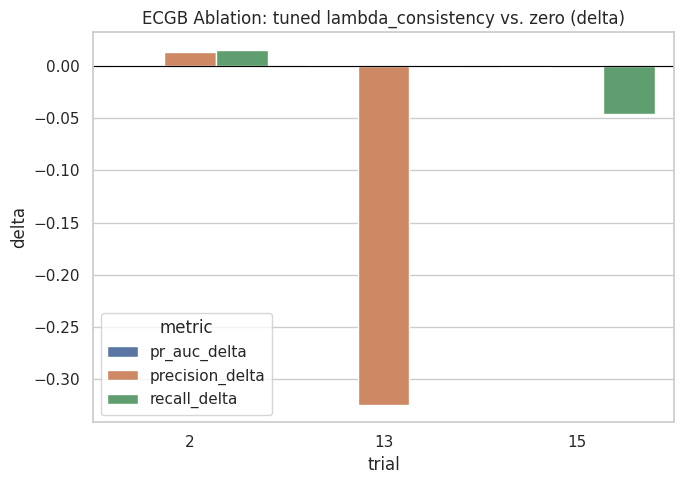


=== Selecting best config (precision >= 0.5, then highest F1) ===


,trial,lambda_consistency,n_estimators,best_iteration,precision,recall,f1,pr_auc
2,2,3.925880,399,6,0.994693,0.998478,0.996582,0.998984
0,15,2.525288,245,31,0.998391,0.944444,0.970669,0.999037
4,13,3.659056,542,6,0.016635,1.000000,0.032726,0.998965


Note: highest-PR-AUC trial was NOT selected -- it failed the precision/F1 check. Selected trial_2 instead.

Best CRGB config carried forward: trial_2, lambda=3.9259, precision=0.9947, recall=0.9985, f1=0.9966
[14:49:01] crgb_ablation_v2 -> completed | mean_pr_auc_delta=-0.00010


In [ ]:
# ============================================================
# SECTION 5.3 - ECGB ABLATION: IS THE CONSISTENCY PENALTY DOING ANYTHING?
# Each of the top three trials is trained twice - tuned lambda against
# lambda=0 - on identical data, pairing and seeds. The only difference
# between the two models is the penalty.
# ============================================================
assert 'crgb_obj_factory' in dir(), "Run Section 5.1 (ECGB core) first - it defines the objective."
assert 'dtrain_inner' in dir(), "Run Section 5.2 (hyperparameter search) first."
if 'study_crgb_v2' not in dir():
    study_crgb_v2 = reload_study('crgb_trial_search_v2')
    trials_df_crgb_v2 = study_crgb_v2.trials_dataframe().sort_values('value', ascending=False).reset_index(drop=True)

log_stage("crgb_ablation_v2", "started")

top3_trial_numbers_crgb = trials_df_crgb_v2.head(3)['number'].tolist()
print("Top 3 trials by validation PR-AUC:", top3_trial_numbers_crgb)

ablation_results = []
for tnum in top3_trial_numbers_crgb:
    full_params = study_crgb_v2.trials[tnum].params.copy()
    n_estimators = full_params.pop('n_estimators')
    lam_tuned = full_params.pop('lambda_consistency')
    xgb_params = {
        'max_depth': full_params['max_depth'], 'eta': full_params['eta'],
        'subsample': full_params['subsample'], 'colsample_bytree': full_params['colsample_bytree'],
        'min_child_weight': full_params['min_child_weight'], 'reg_alpha': full_params['reg_alpha'],
        'reg_lambda': full_params['reg_lambda'], 'tree_method': 'hist', 'device': 'cuda',
    }

    for lam_label, lam_val in [('tuned', lam_tuned), ('zero', 0.0)]:
        obj_fn = crgb_obj_factory(pair_idx_inner, is_synth_inner, lam_val)
        booster = xgb.train(
            xgb_params, dtrain_inner, num_boost_round=n_estimators,
            obj=obj_fn, custom_metric=crgb_eval_pr_auc, maximize=True,
            evals=[(dval_inner, 'val')], early_stopping_rounds=100, verbose_eval=False,
        )
        preds_margin = booster.predict(dval_inner, output_margin=True)
        y_proba = 1.0 / (1.0 + np.exp(-preds_margin))
        m = evaluate_at_threshold(y_inner_val, y_proba)
        m.update({'trial': tnum, 'lambda_consistency': lam_val, 'lambda_label': lam_label,
                   'n_estimators': n_estimators, 'best_iteration': booster.best_iteration, 'params': full_params})
        ablation_results.append(m)
        print(f"  Trial {tnum} [lambda={lam_label:>5} ({lam_val:.4f})]: "
              f"best_iter={booster.best_iteration}/{n_estimators}  "
              f"precision={m['precision']:.4f} recall={m['recall']:.4f} "
              f"f1={m['f1']:.4f} pr_auc={m['pr_auc']:.4f}")

ablation_df = pd.DataFrame(ablation_results)
print("\n=== Ablation: tuned lambda_consistency vs. zero ===")
display(ablation_df.drop(columns='params'))
ablation_df.drop(columns='params').to_csv(f"{DIRS['logs']}/crgb_ablation_results_v2.csv", index=False)

pivot = ablation_df.pivot(index='trial', columns='lambda_label', values=['pr_auc', 'precision', 'recall', 'f1'])
pivot['pr_auc_delta'] = pivot[('pr_auc', 'tuned')] - pivot[('pr_auc', 'zero')]
pivot['precision_delta'] = pivot[('precision', 'tuned')] - pivot[('precision', 'zero')]
pivot['recall_delta'] = pivot[('recall', 'tuned')] - pivot[('recall', 'zero')]
print("\n=== Deltas (tuned - zero): is the consistency term actually helping? ===")
display(pivot[['pr_auc_delta', 'precision_delta', 'recall_delta']])

plt.figure(figsize=(7, 5))
delta_cols_df = pivot[['pr_auc_delta', 'precision_delta', 'recall_delta']].copy()
delta_cols_df.columns = [col[0] for col in delta_cols_df.columns]
delta_cols_df = delta_cols_df.reset_index()
delta_plot_df = delta_cols_df.melt(id_vars='trial', var_name='metric', value_name='delta')
sns.barplot(data=delta_plot_df, x='trial', y='delta', hue='metric')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('ECGB Ablation: tuned lambda_consistency vs. zero (delta)')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/crgb_ablation_deltas_v2.png", dpi=150)
plt.show()

# Selection rule: clear a minimum precision first, then rank by F1. Ranking
# on raw PR-AUC alone once selected a trial scoring 0.997 PR-AUC at 0.028
# precision - a model flagging almost everything as fraud. PR-AUC is
# threshold-independent and so does not penalise that at the threshold I
# actually operate at.
MIN_PRECISION = 0.5
tuned_rows = ablation_df[ablation_df['lambda_label'] == 'tuned'].copy()
print(f"\n=== Selecting best config (precision >= {MIN_PRECISION}, then highest F1) ===")
display(tuned_rows[['trial', 'lambda_consistency', 'n_estimators', 'best_iteration', 'precision', 'recall', 'f1', 'pr_auc']]
        .sort_values('f1', ascending=False))

valid_rows = tuned_rows[tuned_rows['precision'] >= MIN_PRECISION]
if valid_rows.empty:
    print(f"WARNING: no tuned trial cleared precision >= {MIN_PRECISION} -- falling back to best F1 overall.")
    valid_rows = tuned_rows

best_row = valid_rows.sort_values('f1', ascending=False).iloc[0]
if best_row['trial'] != tuned_rows.sort_values('pr_auc', ascending=False).iloc[0]['trial']:
    print(f"Note: highest-PR-AUC trial was NOT selected -- it failed the precision/F1 check. "
          f"Selected trial_{int(best_row['trial'])} instead.")

crgb_best_config_v2 = {
    'trial_number': int(best_row['trial']),
    'lambda_consistency': float(best_row['lambda_consistency']),
    'n_estimators': int(best_row['n_estimators']),
    'params': best_row['params'],
}
save_checkpoint('crgb_best_config_v2', crgb_best_config_v2)
print(f"\nBest CRGB config carried forward: trial_{crgb_best_config_v2['trial_number']}, "
      f"lambda={crgb_best_config_v2['lambda_consistency']:.4f}, "
      f"precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f}, f1={best_row['f1']:.4f}")

log_stage("crgb_ablation_v2", "completed", f"mean_pr_auc_delta={pivot['pr_auc_delta'].mean():.5f}")


### 5.4 Cross-validation

5-fold stratified cross-validation of the winning configuration. Because ECGB is
trained through the lower-level `xgb.train` API with a custom objective, it cannot use
my shared `run_cv_for_candidates` helper; the fold loop is written out here instead,
but it follows the same protocol as every other model — SMOTE re-fitted inside each
fold, and the validation fold never touched by resampling.

The per-fold PR-AUC scores this cell writes to disk are what the significance tests in
Section 10 operate on.


[14:49:01] crgb_cv_v2 -> started 
Using trial_2, lambda_consistency=3.9259, n_estimators=399
  Fold 1: best_iter=131/399  recall=0.9802 precision=0.9977 f1=0.9889 pr_auc=0.9969
  Fold 2: best_iter=47/399  recall=0.9893 precision=0.9954 f1=0.9924 pr_auc=0.9946
  Fold 3: best_iter=120/399  recall=0.9840 precision=0.9969 f1=0.9904 pr_auc=0.9946
  Fold 4: best_iter=6/399  recall=0.9977 precision=0.9902 f1=0.9939 pr_auc=0.9974
  Fold 5: best_iter=6/399  recall=0.9947 precision=0.9939 f1=0.9943 pr_auc=0.9946

=== ECGB: all folds ===


,recall,precision,f1,pr_auc,roc_auc,fold,best_iteration
0,0.980213,0.997676,0.988868,0.996900,0.999514,1,131
1,0.989346,0.995406,0.992366,0.994573,0.998809,2,47
2,0.984018,0.996916,0.990425,0.994619,0.999202,3,120
3,0.997717,0.990181,0.993935,0.997432,0.999620,4,6
4,0.994673,0.993916,0.994294,0.994605,0.999067,5,6



=== ECGB CV summary (mean +/- std) ===


,model,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,ECGB (trial_2),0.989193,0.007248,0.994819,0.002968,0.991978,0.002315,0.995626,0.001419,0.999242,0.000331


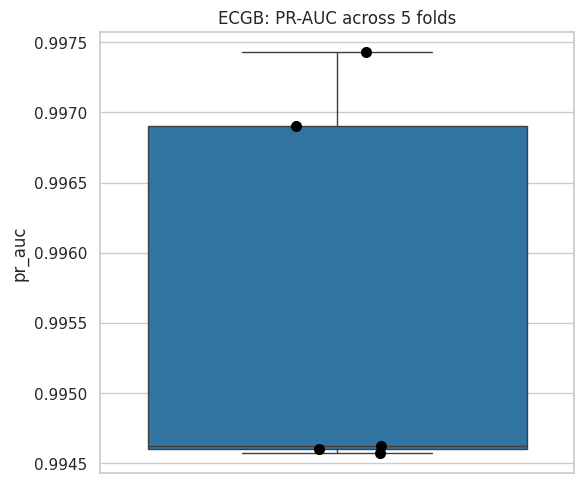


=== Aggregated confusion matrix across all 5 folds ===


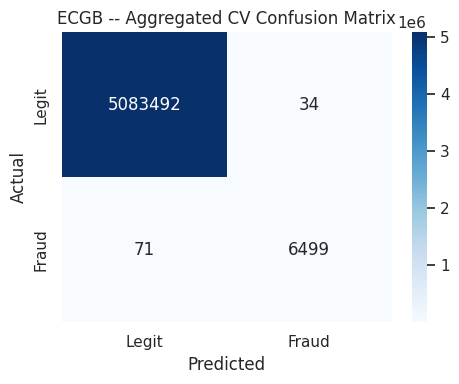

[15:05:00] crgb_cv_v2 -> completed | pr_auc_mean=0.99563


In [ ]:
# ============================================================
# SECTION 5.4 - ECGB: 5-FOLD CROSS-VALIDATION
# ECGB trains through the lower-level xgb.train API with a custom objective
# and so cannot use the shared run_cv_for_candidates helper. The fold loop is
# written out here, but follows the identical protocol: SMOTE re-fitted inside
# each fold, validation rows never resampled. The per-fold PR-AUC scores saved
# here are what the significance tests in Section 10 operate on.
# ============================================================
assert 'crgb_obj_factory' in dir(), "Run Section 5.1 (ECGB core) first - it defines the objective."
log_stage("crgb_cv_v2", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']

crgb_best_config_v2 = load_checkpoint('crgb_best_config_v2')
assert crgb_best_config_v2 is not None, "Run Section 5.3 (ablation) first - it selects the configuration."
crgb_full_params = crgb_best_config_v2['params']
crgb_n_estimators = crgb_best_config_v2['n_estimators']
crgb_lambda = crgb_best_config_v2['lambda_consistency']
crgb_xgb_params = {
    'max_depth': crgb_full_params['max_depth'], 'eta': crgb_full_params['eta'],
    'subsample': crgb_full_params['subsample'], 'colsample_bytree': crgb_full_params['colsample_bytree'],
    'min_child_weight': crgb_full_params['min_child_weight'], 'reg_alpha': crgb_full_params['reg_alpha'],
    'reg_lambda': crgb_full_params['reg_lambda'], 'tree_method': 'hist', 'device': 'cuda',
}
print(f"Using trial_{crgb_best_config_v2['trial_number']}, lambda_consistency={crgb_lambda:.4f}, "
      f"n_estimators={crgb_n_estimators}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results, agg_cm = [], np.zeros((2, 2), dtype=int)

for fold_num, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_ftr, y_ftr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_fval, y_fval = X_train.iloc[val_idx], y_train.iloc[val_idx]

    X_ftr_sm, y_ftr_sm, pair_idx_fold, is_synth_fold = smote_with_pairing(X_ftr, y_ftr)
    dtrain_fold = xgb.DMatrix(X_ftr_sm, label=y_ftr_sm)
    dval_fold = xgb.DMatrix(X_fval, label=y_fval)

    obj_fn = crgb_obj_factory(pair_idx_fold, is_synth_fold, crgb_lambda)
    booster = xgb.train(
        crgb_xgb_params, dtrain_fold, num_boost_round=crgb_n_estimators,
        obj=obj_fn, custom_metric=crgb_eval_pr_auc, maximize=True,
        evals=[(dval_fold, 'val')], early_stopping_rounds=100, verbose_eval=False,
    )
    preds_margin = booster.predict(dval_fold, output_margin=True)
    y_proba = 1.0 / (1.0 + np.exp(-preds_margin))
    y_pred = (y_proba >= 0.5).astype(int)

    m = evaluate_at_threshold(y_fval, y_proba)
    m['fold'] = fold_num
    m['best_iteration'] = booster.best_iteration
    cv_results.append(m)
    agg_cm += confusion_matrix(y_fval, y_pred, labels=[0, 1])

    print(f"  Fold {fold_num}: best_iter={booster.best_iteration}/{crgb_n_estimators}  "
          f"recall={m['recall']:.4f} precision={m['precision']:.4f} "
          f"f1={m['f1']:.4f} pr_auc={m['pr_auc']:.4f}")

    save_checkpoint('crgb_cv_partial_v2', {'cv_results': cv_results, 'agg_cm': agg_cm})
    del dtrain_fold, dval_fold, booster, X_ftr_sm, y_ftr_sm, pair_idx_fold, is_synth_fold, y_proba, y_pred
    gc.collect()

cv_results_df = pd.DataFrame(cv_results)
print("\n=== ECGB: all folds ===")
display(cv_results_df)
cv_results_df.to_csv(f"{DIRS['logs']}/crgb_cv_all_folds_v2.csv", index=False)

summary = {'model': f"ECGB (trial_{crgb_best_config_v2['trial_number']})"}
for metric in ['recall', 'precision', 'f1', 'pr_auc', 'roc_auc']:
    summary[f'{metric}_mean'] = cv_results_df[metric].mean()
    summary[f'{metric}_std'] = cv_results_df[metric].std()
cv_summary_df = pd.DataFrame([summary])
print("\n=== ECGB CV summary (mean +/- std) ===")
display(cv_summary_df)
cv_summary_df.to_csv(f"{DIRS['logs']}/crgb_cv_summary_v2.csv", index=False)

plt.figure(figsize=(6, 5))
sns.boxplot(data=cv_results_df, y='pr_auc', color=PALETTE['accent'])
sns.stripplot(data=cv_results_df, y='pr_auc', color='black', size=8)
plt.title('ECGB: PR-AUC across 5 folds')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/crgb_cv_pr_auc_v2.png", dpi=150)
plt.show()

print("\n=== Aggregated confusion matrix across all 5 folds ===")
plt.figure(figsize=(5, 4))
sns.heatmap(agg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('ECGB -- Aggregated CV Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/crgb_cv_confusion_matrix_v2.png", dpi=150)
plt.show()

log_stage("crgb_cv_v2", "completed", f"pr_auc_mean={summary['pr_auc_mean']:.5f}")


### 5.5 Final model and test-set evaluation

ECGB is trained once on the full training set and scored on the held-out test set. The
booster is saved in XGBoost's JSON format rather than pickled, because the deployment
in Section 11 loads it directly and I wanted that artifact to be portable across
library versions.


[15:05:00] crgb_final_model_v2 -> started 
Using trial_2 params, lambda_consistency=3.9259, n_estimators=399
Applying SMOTE + pairing to the full training set...
Model trained. best_iteration=138/399

=== ECGB (CRGB): FINAL TEST RESULTS ===
  recall: 0.9805
  precision: 1.0000
  f1: 0.9902
  pr_auc: 0.9976
  roc_auc: 0.9995


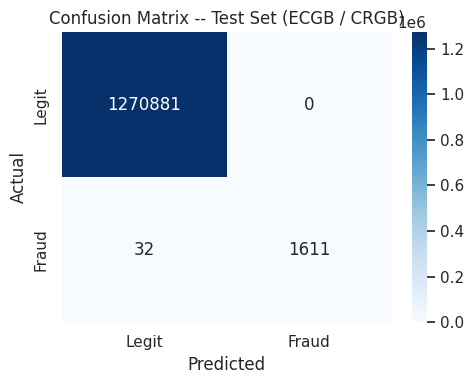

Model saved: /content/drive/MyDrive/Dissertation_ECGB/models/crgb_final_v2.json
[15:10:40] crgb_final_model_v2 -> completed | test_pr_auc=0.99762


In [ ]:
# ============================================================
# SECTION 5.5 - ECGB FINAL MODEL: FULL TRAINING SET, HELD-OUT TEST SET
# Saved as XGBoost JSON rather than pickled, because the deployment in
# Section 11 loads this file directly and I wanted a portable artifact.
# ============================================================
assert 'crgb_obj_factory' in dir(), "Run Section 5.1 (ECGB core) first - it defines the objective."
log_stage("crgb_final_model_v2", "started")

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

crgb_best_config_v2 = load_checkpoint('crgb_best_config_v2')
assert crgb_best_config_v2 is not None, "Run Section 5.3 (ablation) first - it selects the configuration."
crgb_full_params = crgb_best_config_v2['params']
crgb_n_estimators = crgb_best_config_v2['n_estimators']
crgb_lambda = crgb_best_config_v2['lambda_consistency']
print(f"Using trial_{crgb_best_config_v2['trial_number']} params, "
      f"lambda_consistency={crgb_lambda:.4f}, n_estimators={crgb_n_estimators}")

crgb_xgb_params = {
    'max_depth': crgb_full_params['max_depth'], 'eta': crgb_full_params['eta'],
    'subsample': crgb_full_params['subsample'], 'colsample_bytree': crgb_full_params['colsample_bytree'],
    'min_child_weight': crgb_full_params['min_child_weight'], 'reg_alpha': crgb_full_params['reg_alpha'],
    'reg_lambda': crgb_full_params['reg_lambda'], 'tree_method': 'hist', 'device': 'cuda',
}

print("Applying SMOTE + pairing to the full training set...")
X_train_sm, y_train_sm, pair_idx_full, is_synth_full = smote_with_pairing(X_train, y_train)

dtrain_full = xgb.DMatrix(X_train_sm, label=y_train_sm)
dtest_full = xgb.DMatrix(X_test, label=y_test)

obj_fn = crgb_obj_factory(pair_idx_full, is_synth_full, crgb_lambda)
final_booster_crgb_v2 = xgb.train(
    crgb_xgb_params, dtrain_full, num_boost_round=crgb_n_estimators,
    obj=obj_fn, custom_metric=crgb_eval_pr_auc, maximize=True,
    evals=[(dtest_full, 'test')], early_stopping_rounds=100, verbose_eval=False,
)
print(f"Model trained. best_iteration={final_booster_crgb_v2.best_iteration}/{crgb_n_estimators}")

preds_margin = final_booster_crgb_v2.predict(dtest_full, output_margin=True)
y_test_proba_crgb = 1.0 / (1.0 + np.exp(-preds_margin))
test_metrics_crgb = evaluate_at_threshold(y_test, y_test_proba_crgb)
print("\n=== ECGB (CRGB): FINAL TEST RESULTS ===")
for k, v in test_metrics_crgb.items():
    print(f"  {k}: {v:.4f}")

y_test_pred_crgb = (y_test_proba_crgb >= 0.5).astype(int)
plot_confusion(y_test, y_test_pred_crgb, 'Confusion Matrix -- Test Set (ECGB / CRGB)',
               'crgb_final_confusion_matrix_v2.png')

final_booster_crgb_v2.save_model(f"{DIRS['models']}/crgb_final_v2.json")
print(f"Model saved: {DIRS['models']}/crgb_final_v2.json")

register_result('ECGB (CRGB)', test_metrics_crgb)
log_stage("crgb_final_model_v2", "completed", f"test_pr_auc={test_metrics_crgb['pr_auc']:.5f}")


### 5.6 Mechanism test: does the penalty do what I claim it does?

The consistency evaluation in Section 6 measures explanation stability over k-nearest-
neighbour pairs in the test set. That is the right measure for the research question,
but it is not a direct test of the *mechanism*, because the penalty operates on
synthetic-parent pairs during training, not on test-set neighbours. It is entirely
possible for the headline metric to improve for reasons unrelated to the mechanism I
claim is responsible.

This cell therefore tests the mechanism on its own terms. I take the trained ECGB
model and an identical twin trained with `lambda = 0` — same parameters, same data,
same pairing, same seed, differing only in the penalty — and compare the SHAP
explanations each gives to 1,000 synthetic rows against their own parents. I also
compare each synthetic row against an *unrelated* parent, which gives me a baseline:
if paired similarity is no higher than random-pair similarity, any apparent
consistency is just homogenisation.

Because both models are evaluated on the same 1,000 pairs, I can use a paired
Wilcoxon test and have genuine statistical power, rather than reasoning from a single
aggregate number.


[11:21:23] ecgb_paired_mechanism_test -> started 
Config: trial_2, lambda=3.9259, n_estimators=399
Applying SMOTE-with-Pairing to the full training set...
  5,591,878 rows, 501,782 synthetic
Training lambda=0 twin (same params, same data, same pairing)...

ECGB (lambda tuned)
  paired  cosine 0.9850 | Jaccard@5 0.9418
  random  cosine 0.7543 | Jaccard@5 0.5479
  gap     cosine +0.2308 | Jaccard@5 +0.3939

Ablation (lambda=0)
  paired  cosine 0.9788 | Jaccard@5 0.9294
  random  cosine 0.7933 | Jaccard@5 0.5178
  gap     cosine +0.1855 | Jaccard@5 +0.4117

=== Paired Wilcoxon: ECGB vs lambda=0 on the SAME synthetic-parent pairs ===
  cosine  : ECGB 0.9850 vs lambda=0 0.9788 (diff +0.0062, p=4.18e-08) -> SUPPORTS the mechanism
  jaccard : ECGB 0.9418 vs lambda=0 0.9294 (diff +0.0124, p=2.49e-03) -> SUPPORTS the mechanism


,metric,ecgb_mean,lambda0_mean,mean_diff,p_value,n_pairs,significant_at_0.05
0,cosine,0.985007,0.978773,0.006235,4.177115e-08,1000,True
1,jaccard,0.941810,0.929429,0.012381,2.485127e-03,1000,True



=== Summary (candidate Table 4.9) ===


,model,paired_cosine,paired_jaccard@5,random_cosine,random_jaccard@5,cosine_gap,jaccard_gap
0,ECGB (lambda tuned),0.985007,0.941810,0.754251,0.547869,0.230756,0.393940
1,Ablation (lambda=0),0.978773,0.929429,0.793297,0.517774,0.185476,0.411655


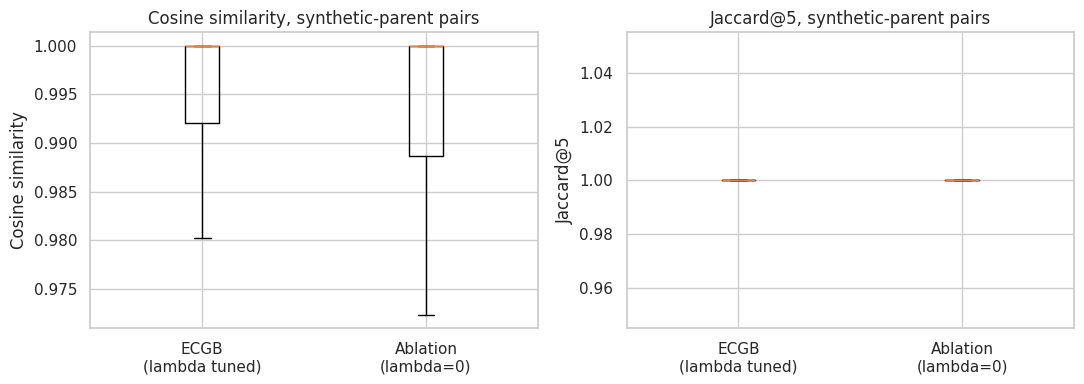

[11:28:12] ecgb_paired_mechanism_test -> completed | n_pairs=1000


In [ ]:
# ============================================================
# SECTION 5.6 - ECGB MECHANISM TEST
#
# Does the consistency penalty actually cause synthetic rows and their SMOTE
# parents to receive similar SHAP explanations? Section 3.11 of the
# dissertation predicts exactly that, but the evaluation in Section 6 measures
# k-NN pairs in the test set rather than the synthetic-parent pairs the penalty
# operates on - so it tests the outcome, not the mechanism. Here I test the
# mechanism directly, on the pairs it acts on, against an identical lambda=0
# twin. Because both models are scored on the same 1,000 pairs I can use a
# paired test and have real statistical power.
#
# Prerequisites: Sections 1 and 5.1 must have run in this session (for
# smote_with_pairing, crgb_obj_factory and crgb_eval_pr_auc). Reads the
# data_splits and crgb_best_config_v2 checkpoints and the crgb_final_v2.json
# model file.
# ============================================================
from scipy.stats import wilcoxon

assert 'smote_with_pairing' in dir(), "Run Section 5.1 (ECGB core) first."
assert 'crgb_obj_factory' in dir(),  "Run Section 5.1 (ECGB core) first."
log_stage("ecgb_paired_mechanism_test", "started")

N_PAIRS   = 1000     # synthetic rows sampled for the comparison
TOP_K     = 5        # Jaccard@5, same as Table 4.7
N_RANDOM  = 1000     # random synthetic-vs-unrelated-parent baseline

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
cfg = load_checkpoint('crgb_best_config_v2')
assert cfg is not None, "crgb_best_config_v2 checkpoint missing - run Section 5.3 once."

lam_tuned    = cfg['lambda_consistency']
n_estimators = cfg['n_estimators']
p            = cfg['params']
xgb_params = {
    'max_depth': p['max_depth'], 'eta': p['eta'], 'subsample': p['subsample'],
    'colsample_bytree': p['colsample_bytree'], 'min_child_weight': p['min_child_weight'],
    'reg_alpha': p['reg_alpha'], 'reg_lambda': p['reg_lambda'],
    'tree_method': 'hist', 'device': 'cuda',
}
print(f"Config: trial_{cfg['trial_number']}, lambda={lam_tuned:.4f}, n_estimators={n_estimators}")

# ---- Identical pairing to the final model: same seed, therefore same pairs ----
print("Applying SMOTE-with-Pairing to the full training set...")
X_sm, y_sm, pair_idx, is_synth = smote_with_pairing(X_train, y_train)
dtrain_full = xgb.DMatrix(X_sm, label=y_sm)
print(f"  {len(X_sm):,} rows, {int(is_synth.sum()):,} synthetic")

# ---- Model A: the trained ECGB, loaded from disk rather than retrained ----
booster_ecgb = xgb.Booster()
booster_ecgb.load_model(f"{DIRS['models']}/crgb_final_v2.json")

# ---- Model B: an identical twin with lambda=0. The penalty is the only
# thing that differs between the two models. ----
print("Training lambda=0 twin (same params, same data, same pairing)...")
booster_zero = xgb.train(
    xgb_params, dtrain_full, num_boost_round=n_estimators,
    obj=crgb_obj_factory(pair_idx, is_synth, 0.0),
    custom_metric=crgb_eval_pr_auc, maximize=True, verbose_eval=False,
)
booster_zero.save_model(f"{DIRS['models']}/crgb_lambda0_twin.json")

# ---- Sample synthetic rows and retrieve the parents they were derived from ----
rng = np.random.RandomState(SEED)
synth_pos = np.where(is_synth)[0]
sel_synth = rng.choice(synth_pos, size=min(N_PAIRS, len(synth_pos)), replace=False)
sel_parent = pair_idx[sel_synth]

X_arr = X_sm.values if hasattr(X_sm, 'values') else np.asarray(X_sm)
rows = np.concatenate([sel_synth, sel_parent])
d_rows = xgb.DMatrix(X_arr[rows], feature_names=list(X_train.columns))


def shap_matrix(booster):
    """Exact per-row SHAP values for an XGBoost Booster (drops the bias column)."""
    return booster.predict(d_rows, pred_contribs=True)[:, :-1]


def cos(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


def jac_topk(a, b, k=TOP_K):
    ta = set(np.argsort(-np.abs(a))[:k]); tb = set(np.argsort(-np.abs(b))[:k])
    return len(ta & tb) / len(ta | tb)


def paired_scores(shap_all, n):
    """shap_all is stacked [synthetic rows; parent rows]."""
    s, par = shap_all[:n], shap_all[n:]
    return (np.array([cos(s[i], par[i]) for i in range(n)]),
            np.array([jac_topk(s[i], par[i]) for i in range(n)]))


def random_scores(shap_all, n, seed=SEED):
    """The same synthetic rows paired with unrelated parents. This is the
    baseline for the gap: if paired similarity is no higher than this, any
    apparent consistency is homogenisation rather than local stability."""
    r = np.random.RandomState(seed)
    s, par = shap_all[:n], shap_all[n:]
    j = r.permutation(n)
    j[j == np.arange(n)] = (j[j == np.arange(n)] + 1) % n     # avoid true pairs
    return (np.array([cos(s[i], par[j[i]]) for i in range(n)]),
            np.array([jac_topk(s[i], par[j[i]]) for i in range(n)]))


n = len(sel_synth)
out = {}
for label, booster in [('ECGB (lambda tuned)', booster_ecgb), ('Ablation (lambda=0)', booster_zero)]:
    sm = shap_matrix(booster)
    c_pair, j_pair = paired_scores(sm, n)
    c_rand, j_rand = random_scores(sm, n)
    out[label] = {
        'cosine_paired': c_pair, 'jaccard_paired': j_pair,
        'cosine_random': c_rand, 'jaccard_random': j_rand,
    }
    print(f"\n{label}")
    print(f"  paired  cosine {c_pair.mean():.4f} | Jaccard@5 {j_pair.mean():.4f}")
    print(f"  random  cosine {c_rand.mean():.4f} | Jaccard@5 {j_rand.mean():.4f}")
    print(f"  gap     cosine {c_pair.mean()-c_rand.mean():+.4f} | "
          f"Jaccard@5 {j_pair.mean()-j_rand.mean():+.4f}")

# ---- The test itself: two models, the same 1,000 pairs, paired Wilcoxon ----
a, b = out['ECGB (lambda tuned)'], out['Ablation (lambda=0)']
print("\n=== Paired Wilcoxon: ECGB vs lambda=0 on the SAME synthetic-parent pairs ===")
stats_rows = []
for metric in ['cosine', 'jaccard']:
    va, vb = a[f'{metric}_paired'], b[f'{metric}_paired']
    stat, pval = wilcoxon(va, vb)
    diff = va.mean() - vb.mean()
    stats_rows.append({'metric': metric, 'ecgb_mean': va.mean(), 'lambda0_mean': vb.mean(),
                       'mean_diff': diff, 'p_value': pval, 'n_pairs': n,
                       'significant_at_0.05': bool(pval < 0.05)})
    verdict = "SUPPORTS the mechanism" if (diff > 0 and pval < 0.05) else \
              ("CONTRADICTS the mechanism" if (diff < 0 and pval < 0.05) else "inconclusive")
    print(f"  {metric:8s}: ECGB {va.mean():.4f} vs lambda=0 {vb.mean():.4f} "
          f"(diff {diff:+.4f}, p={pval:.2e}) -> {verdict}")

stats_df = pd.DataFrame(stats_rows)
display(stats_df)

summary = pd.DataFrame([
    {'model': k,
     'paired_cosine': v['cosine_paired'].mean(), 'paired_jaccard@5': v['jaccard_paired'].mean(),
     'random_cosine': v['cosine_random'].mean(), 'random_jaccard@5': v['jaccard_random'].mean(),
     'cosine_gap': v['cosine_paired'].mean() - v['cosine_random'].mean(),
     'jaccard_gap': v['jaccard_paired'].mean() - v['jaccard_random'].mean()}
    for k, v in out.items()])
print("\n=== Summary (reported as Table 4.9) ===")
display(summary)

# ---- Figure ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, name in [(axes[0], 'cosine', 'Cosine similarity'),
                          (axes[1], 'jaccard', 'Jaccard@5')]:
    ax.boxplot([a[f'{metric}_paired'], b[f'{metric}_paired']],
               labels=['ECGB\n(lambda tuned)', 'Ablation\n(lambda=0)'], showfliers=False)
    ax.set_ylabel(name); ax.set_title(f'{name}, synthetic-parent pairs')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/ecgb_paired_mechanism_test.png", dpi=200, bbox_inches='tight')
plt.show()

save_checkpoint('ecgb_paired_mechanism_test',
                {'summary': summary, 'stats': stats_df, 'n_pairs': n,
                 'lambda_tuned': lam_tuned, 'seed': SEED})
log_stage("ecgb_paired_mechanism_test", "completed", f"n_pairs={n}")


## 6. Explanation Consistency — My Primary Research Question

This is the comparison the dissertation is built around: are ECGB's explanations more
*consistent* across similar transactions than those of the other models? The
predictive results in Sections 4 and 5 matter, but they are a secondary concern. A
model that scores marginally better on PR-AUC while producing explanations that
change arbitrarily between near-identical transactions is of little use to the auditor
or regulator this work is aimed at.

Two problems shaped how I built this cell, and both are worth stating because either
would have invalidated the measurement.

**Fraud is too rare for a random sample.** At 0.13% prevalence, a random draw from
the test set contains almost no fraud rows, and the nearest-neighbour search would
have nothing meaningful to work with. I therefore sample the fraud and legitimate
classes separately, guaranteeing enough fraud instances for the neighbourhood
structure to exist.

**A consistency score alone can be thoroughly misleading.** A model that returns the
*same* explanation for every fraud transaction, regardless of whether those
transactions resemble one another, scores perfectly on raw consistency. That is
homogenisation, not local stability, and it is worse than useless to an investigator.
So for every model I also compute consistency over randomly chosen same-class pairs
and report the gap. A large gap means the explanations genuinely track how similar
the transactions are; a small gap means the model is giving one generic answer to the
entire class. I regard this gap, rather than the raw consistency figure, as the
meaningful result.


[19:49:10] explanation_consistency_comparison -> started 
Eval sample: 1060 rows (60 fraud, 1000 legit)

Computing SHAP + consistency for XGBoost...
  [legit] cosine=0.7956  jaccard_top5=0.7038  n_instances=1000  distinct_top5_sets=77
  [fraud] cosine=0.9215  jaccard_top5=0.7356  n_instances=60  distinct_top5_sets=17
  [fraud] neighbor-vs-random gap: +0.2112 

Computing SHAP + consistency for LightGBM...
  [legit] cosine=0.7788  jaccard_top5=0.7704  n_instances=1000  distinct_top5_sets=50
  [fraud] cosine=0.9227  jaccard_top5=0.7473  n_instances=60  distinct_top5_sets=17
  [fraud] neighbor-vs-random gap: +0.1840 

Computing SHAP + consistency for CatBoost...
  [legit] cosine=0.7574  jaccard_top5=0.7788  n_instances=1000  distinct_top5_sets=46
  [fraud] cosine=0.8723  jaccard_top5=0.7663  n_instances=60  distinct_top5_sets=12
  [fraud] neighbor-vs-random gap: +0.1686 

Computing SHAP + consistency for DecisionTree...
  [legit] cosine=0.7684  jaccard_top5=0.7404  n_instances=1000  distin

  0%|          | 0/1060 [00:00<?, ?it/s]

  [legit] cosine=0.8365  jaccard_top5=0.5784  n_instances=1000  distinct_top5_sets=204
  [fraud] cosine=0.8695  jaccard_top5=0.6618  n_instances=60  distinct_top5_sets=27
  [fraud] neighbor-vs-random gap: +0.1947 

=== Explanation consistency -- per class, per model (fraud rows include the gap check) ===


,model,class,cosine,jaccard_top5,n_pairs,n_instances,n_unique_top5_sets,random_jaccard,gap
0,XGBoost,legit,0.795561,0.703792,10000,1000,77,NaN,NaN
1,XGBoost,fraud,0.921519,0.735556,600,60,17,0.524405,0.211151
2,LightGBM,legit,0.778815,0.770432,10000,1000,50,NaN,NaN
3,LightGBM,fraud,0.922678,0.747341,600,60,17,0.563294,0.184048
4,CatBoost,legit,0.757406,0.778769,10000,1000,46,NaN,NaN
5,CatBoost,fraud,0.872311,0.766349,600,60,12,0.597778,0.168571
6,DecisionTree,legit,0.768440,0.740356,10000,1000,41,NaN,NaN
7,DecisionTree,fraud,0.904847,0.726310,600,60,14,0.587857,0.138452
8,ECGB (CRGB),legit,0.843775,0.795487,10000,1000,60,NaN,NaN
9,ECGB (CRGB),fraud,0.881266,0.704028,600,60,19,0.505119,0.198909


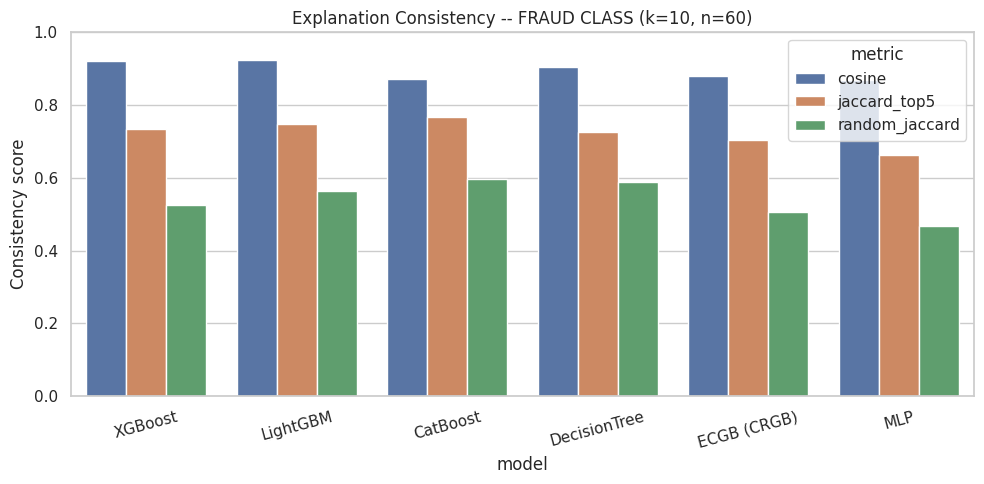

[19:50:30] explanation_consistency_comparison -> completed | models=['XGBoost', 'LightGBM', 'CatBoost', 'DecisionTree', 'ECGB (CRGB)', 'MLP']


In [ ]:
# ============================================================
# SECTION 6 - EXPLANATION CONSISTENCY COMPARISON (PRIMARY RESEARCH QUESTION)
# Every trained model, scored on one shared evaluation sample. The MLP is
# included through a model-agnostic explainer so that the comparison is not
# restricted to models a TreeExplainer can handle.
# ============================================================
from sklearn.pipeline import Pipeline as SklearnPipeline
log_stage("explanation_consistency_comparison", "started")

splits = load_checkpoint('data_splits')
X_test, y_test = splits['X_test'], splits['y_test']

CONSISTENCY_K = 10
CONSISTENCY_TOP_K = 5
MIN_FRAUD_ROWS = 60      # comfortably above the k+1 = 11 the neighbour
                         # search needs, so the structure is well defined
N_LEGIT_ROWS = 1000
RANDOM_PAIR_COUNT = 600  # pairs drawn for the neighbour-versus-random gap check
MLP_BACKGROUND_SIZE = 100  # for KernelExplainer background
MLP_NSAMPLES = 100          # KernelExplainer sampling budget

fraud_idx_all = y_test[y_test == 1].index
legit_idx_all = y_test[y_test == 0].index
n_fraud_take = min(MIN_FRAUD_ROWS, len(fraud_idx_all))
fraud_idx = pd.Series(fraud_idx_all).sample(n=n_fraud_take, random_state=SEED)
legit_idx = pd.Series(legit_idx_all).sample(n=min(N_LEGIT_ROWS, len(legit_idx_all)), random_state=SEED)
eval_idx = pd.concat([fraud_idx, legit_idx])

X_eval = X_test.loc[eval_idx].reset_index(drop=True)
y_eval = y_test.loc[eval_idx].reset_index(drop=True)
print(f"Eval sample: {len(X_eval)} rows ({y_eval.sum()} fraud, {len(y_eval)-y_eval.sum()} legit)")
if n_fraud_take < MIN_FRAUD_ROWS:
    print(f"WARNING: only {n_fraud_take} fraud rows available (wanted {MIN_FRAUD_ROWS}).")

# The neighbourhood structure is defined once, on scaled features, and used for
# every model regardless of what form each model wants its own input in. If the
# neighbourhoods differed between models the consistency scores would not be
# comparable, so this stays fixed throughout.
X_eval_scaled = StandardScaler().fit_transform(X_eval)

def extract_positive_class_shap(sv):
    if isinstance(sv, list):
        return np.asarray(sv[1] if len(sv) > 1 else sv[0])
    arr = np.asarray(sv)
    return arr[:, :, -1] if arr.ndim == 3 else arr

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def compute_consistency_per_class(shap_matrix, X_scaled, y, k=CONSISTENCY_K, top_k=CONSISTENCY_TOP_K):
    y_arr = y.values if hasattr(y, 'values') else np.asarray(y)
    per_class = {}
    for cls, cls_name in [(0, 'legit'), (1, 'fraud')]:
        idx_cls = np.where(y_arr == cls)[0]
        if len(idx_cls) < k + 1:
            per_class[cls_name] = {'cosine': np.nan, 'jaccard_top5': np.nan, 'n_pairs': 0, 'n_instances': len(idx_cls)}
            continue
        nn = NearestNeighbors(n_neighbors=k + 1).fit(X_scaled[idx_cls])
        _, neighbor_idx = nn.kneighbors(X_scaled[idx_cls])
        cos_scores, jac_scores, unique_top_sets = [], [], set()
        for local_i, global_i in enumerate(idx_cls):
            own_shap = shap_matrix[global_i]
            own_top = frozenset(np.argsort(-np.abs(own_shap))[:top_k])
            unique_top_sets.add(own_top)
            for nb_local in neighbor_idx[local_i][1:]:
                nb_global = idx_cls[nb_local]
                nb_shap = shap_matrix[nb_global]
                cos_scores.append(cosine_sim(own_shap, nb_shap))
                nb_top = frozenset(np.argsort(-np.abs(nb_shap))[:top_k])
                jac_scores.append(len(own_top & nb_top) / len(own_top | nb_top))
        per_class[cls_name] = {
            'cosine': float(np.mean(cos_scores)), 'jaccard_top5': float(np.mean(jac_scores)),
            'n_pairs': len(cos_scores), 'n_instances': len(idx_cls), 'n_unique_top5_sets': len(unique_top_sets),
        }
    return per_class

def random_pair_consistency(shap_matrix, y, cls=1, n_pairs=RANDOM_PAIR_COUNT, top_k=CONSISTENCY_TOP_K, seed=SEED):
    """The baseline for the gap check: consistency between any two same-class
    rows, whether or not they are neighbours. If a model's neighbour consistency
    is not meaningfully higher than this, it is not tracking similarity between
    transactions at all - it is returning one generic explanation for the whole
    class, which is homogenisation rather than local stability."""
    rng = np.random.RandomState(seed)
    y_arr = y.values if hasattr(y, 'values') else np.asarray(y)
    idx_cls = np.where(y_arr == cls)[0]
    if len(idx_cls) < 2:
        return {'cosine': np.nan, 'jaccard_top5': np.nan}
    cos_scores, jac_scores = [], []
    for _ in range(n_pairs):
        i, j = rng.choice(idx_cls, size=2, replace=False)
        a, b = shap_matrix[i], shap_matrix[j]
        cos_scores.append(cosine_sim(a, b))
        top_a = set(np.argsort(-np.abs(a))[:top_k])
        top_b = set(np.argsort(-np.abs(b))[:top_k])
        jac_scores.append(len(top_a & top_b) / len(top_a | top_b))
    return {'cosine': float(np.mean(cos_scores)), 'jaccard_top5': float(np.mean(jac_scores))}

# Model loaders. 'kind' tells the loop which explainer to use: TreeExplainer
# for the tree ensembles, and the model-agnostic KernelExplainer for the MLP.
# ECGB points at the JSON booster saved in Section 5.5.
MODEL_LOADERS = {
    'XGBoost':      {'kind': 'tree', 'load': lambda: pickle.load(open(f"{DIRS['models']}/xgboost_final.pkl", 'rb'))},
    'LightGBM':     {'kind': 'tree', 'load': lambda: pickle.load(open(f"{DIRS['models']}/lightgbm_final.pkl", 'rb'))},
    'CatBoost':     {'kind': 'tree', 'load': lambda: pickle.load(open(f"{DIRS['models']}/catboost_final.pkl", 'rb'))},
    'DecisionTree': {'kind': 'tree', 'load': lambda: pickle.load(open(f"{DIRS['models']}/dt_final.pkl", 'rb'))},
    'ECGB (CRGB)':  {'kind': 'tree', 'load': lambda: (lambda b: (b.load_model(f"{DIRS['models']}/crgb_final_v2.json"), b)[1])(xgb.Booster())},
    'MLP':          {'kind': 'kernel', 'load': lambda: pickle.load(open(f"{DIRS['models']}/mlp_final.pkl", 'rb'))},
}

all_per_class_results, gap_results, skipped = {}, {}, []

for name, spec in MODEL_LOADERS.items():
    try:
        model = spec['load']()
    except FileNotFoundError:
        skipped.append(name)
        continue

    print(f"\nComputing SHAP + consistency for {name}...")

    if spec['kind'] == 'tree':
        explainer = shap.TreeExplainer(model)
        shap_matrix = extract_positive_class_shap(explainer.shap_values(X_eval))
        del explainer
    else:  # 'kernel' -- model-agnostic explainer for non-tree models (MLP)
        # The MLP is saved as a Pipeline containing its own StandardScaler, so it
        # must be given raw features - passing X_eval_scaled would scale them
        # twice and silently distort the explanations. I detect the case rather
        # than assume it, so that a bare estimator would still be handled
        # correctly.
        is_pipeline = isinstance(model, SklearnPipeline)
        mlp_input = X_eval.values if is_pipeline else X_eval_scaled
        print(f"  Detected {'Pipeline (has its own scaler -- using raw X_eval)' if is_pipeline else 'bare estimator -- using X_eval_scaled'}")

        background = shap.sample(mlp_input, min(MLP_BACKGROUND_SIZE, len(mlp_input)), random_state=SEED)
        # A plain function rather than the bound method: SHAP inspects
        # feature_names_in_ on what it is given and mishandles Pipelines.
        predict_fn = lambda x: model.predict_proba(x)
        explainer = shap.KernelExplainer(predict_fn, background)
        sv = explainer.shap_values(mlp_input, nsamples=MLP_NSAMPLES)
        shap_matrix = extract_positive_class_shap(sv)
        del explainer

    per_class = compute_consistency_per_class(shap_matrix, X_eval_scaled, y_eval)
    all_per_class_results[name] = per_class

    random_fraud = random_pair_consistency(shap_matrix, y_eval, cls=1)
    gap = per_class['fraud']['jaccard_top5'] - random_fraud['jaccard_top5']
    gap_results[name] = {'random_jaccard': random_fraud['jaccard_top5'], 'gap': gap}

    for cls_name, r in per_class.items():
        print(f"  [{cls_name:5s}] cosine={r['cosine']:.4f}  jaccard_top5={r['jaccard_top5']:.4f}  "
              f"n_instances={r['n_instances']}  distinct_top5_sets={r.get('n_unique_top5_sets','-')}")
    print(f"  [fraud] neighbor-vs-random gap: {gap:+.4f} "
          f"{'(small -- mostly homogenization, not real local stability)' if abs(gap) < 0.05 else ''}")

    del shap_matrix
    gc.collect()

if skipped:
    print(f"\nSkipped (not trained yet): {skipped}")

if not all_per_class_results:
    print("\nNo trained models found - run the final-model cells in Sections 4 and 5 first.")
else:
    rows = []
    for model_name, per_class in all_per_class_results.items():
        for cls_name, r in per_class.items():
            row = {'model': model_name, 'class': cls_name, **r}
            if cls_name == 'fraud':
                row.update(gap_results[model_name])
            rows.append(row)
    consistency_df = pd.DataFrame(rows)
    print("\n=== Explanation consistency -- per class, per model (fraud rows include the gap check) ===")
    display(consistency_df)
    consistency_df.to_csv(f"{DIRS['logs']}/explanation_consistency_comparison_v2.csv", index=False)
    save_checkpoint('explanation_consistency_results_v2', {'per_class': all_per_class_results, 'gap': gap_results})

    fraud_df = consistency_df[consistency_df['class'] == 'fraud']
    if fraud_df['cosine'].notna().any():
        plot_df = fraud_df.melt(id_vars='model', value_vars=['cosine', 'jaccard_top5', 'random_jaccard'],
                                 var_name='metric', value_name='score')
        plt.figure(figsize=(10, 5))
        sns.barplot(data=plot_df, x='model', y='score', hue='metric')
        plt.ylim(0, 1)
        plt.title(f'Explanation Consistency -- FRAUD CLASS (k={CONSISTENCY_K}, n={fraud_df["n_instances"].iloc[0]:.0f})')
        plt.ylabel('Consistency score')
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.savefig(f"{DIRS['figures']}/explanation_consistency_fraud_class_v2.png", dpi=150)
        plt.show()

    log_stage("explanation_consistency_comparison", "completed", f"models={list(all_per_class_results.keys())}")


## 7. DASH — Diverse-Aggregated SHAP

DASH is the control condition for my whole argument. Instead of building consistency
into training, it trains five deliberately diverse CatBoost models — bootstrap
resampling, a little jitter on the sampling temperature, each with its own SMOTE
resample — and averages their post-hoc SHAP values. Averaging over an ensemble is the
obvious cheap way to stabilise explanations, and it requires no custom objective at
all.

This is the comparison that could most easily undermine ECGB, which is exactly why it
is here. If ECGB does not clearly beat post-hoc aggregation on the consistency
comparison in Section 6, that is a finding to report plainly rather than to bury.


### 7.1 Training the diverse ensemble

I start by clearing the heavier objects left in memory by earlier sections; without
that, this cell was reliably running the session out of RAM. Each of the five models
uses the tuned CatBoost configuration from Section 4.3 with a different seed, its own
bootstrap resample and slightly perturbed `bagging_temperature`, so that the
diversity comes from the data and the sampling rather than from unequal tuning.


In [ ]:
# ============================================================
# SECTION 7.1 - DASH: TRAINING THE DIVERSE CATBOOST ENSEMBLE
# Diversity comes from bootstrap resampling, per-model seeds and a little
# jitter on the sampling temperature - not from unequal tuning, since every
# member starts from the same configuration selected in Section 4.3.
# ============================================================
log_stage("dash_train_diverse", "started")

# Release the heavier objects earlier sections left in memory. Without this,
# training five CatBoost models in sequence reliably exhausted the session.
for _name in ['diverse_models', 'per_model_shap', 'shap_dash_mean', 'X_train_sm', 'y_train_sm',
              'dtrain_full', 'dtest_full', 'final_booster_crgb_v2']:
    if _name in dir():
        del globals()[_name]
gc.collect()

splits = load_checkpoint('data_splits')
X_train, y_train = splits['X_train'], splits['y_train']
X_test, y_test = splits['X_test'], splits['y_test']

if 'study_cb' not in dir():
    study_cb = reload_study('catboost_trial_search')

best_label_cb = load_checkpoint('catboost_best_trial_label')
best_trial_num_cb = int(best_label_cb.split('_')[1]) if best_label_cb else study_cb.best_trial.number
base_params_cb = study_cb.trials[best_trial_num_cb].params
print(f"Base CatBoost config for DASH: trial_{best_trial_num_cb}")

K = 5
diverse_models = []

for k in range(K):
    print(f"\n--- Training diverse model {k+1}/{K} ---")
    seed_k = SEED + k

    X_boot, y_boot = resample(X_train, y_train, replace=True,
                               n_samples=len(X_train), random_state=seed_k, stratify=y_train)
    # sampling_strategy=0.1 rather than full balance. A 1:1 resample of a ~5M-row
    # bootstrap is what exhausted memory here, the same constraint that shaped
    # the ECGB pairing function, and I keep the setting consistent between them.
    X_boot_sm, y_boot_sm = SMOTE(random_state=seed_k, sampling_strategy=0.1).fit_resample(X_boot, y_boot)

    params_k = base_params_cb.copy()
    params_k['bagging_temperature'] = float(np.clip(
        base_params_cb.get('bagging_temperature', 0.5) + np.random.RandomState(seed_k).uniform(-0.3, 0.3),
        0.0, 1.0
    ))

    try:
        model_k = cb.CatBoostClassifier(**params_k, random_state=seed_k, verbose=False,
                                         task_type='GPU', devices='0')
        model_k.fit(X_boot_sm, y_boot_sm)
    except cb.CatBoostError as e:
        print(f"  GPU training failed ({e}) -- falling back to CPU for this model.")
        model_k = cb.CatBoostClassifier(**params_k, random_state=seed_k, verbose=False, task_type='CPU')
        model_k.fit(X_boot_sm, y_boot_sm)

    diverse_models.append(model_k)

    y_proba_k = model_k.predict_proba(X_test)[:, 1]
    m = evaluate_at_threshold(y_test, y_proba_k)
    print(f"  Model {k+1}: pr_auc={m['pr_auc']:.4f} precision={m['precision']:.4f} recall={m['recall']:.4f}")

    del X_boot, y_boot, X_boot_sm, y_boot_sm, y_proba_k
    gc.collect()

save_checkpoint('dash_diverse_models', diverse_models)
log_stage("dash_train_diverse", "completed", f"k={K} models trained")


[13:41:13] dash_train_diverse -> started 
Base CatBoost config for DASH: trial_1

--- Training diverse model 1/5 ---
  GPU training failed (catboost/cuda/cuda_lib/cuda_manager.cpp:201: Condition violated: `State == nullptr') -- falling back to CPU for this model.
  Model 1: pr_auc=0.9985 precision=0.9939 recall=0.9976

--- Training diverse model 2/5 ---
  GPU training failed (catboost/cuda/cuda_lib/cuda_manager.cpp:201: Condition violated: `State == nullptr') -- falling back to CPU for this model.
  Model 2: pr_auc=0.9985 precision=0.9915 recall=0.9976

--- Training diverse model 3/5 ---
  GPU training failed (catboost/cuda/cuda_lib/cuda_manager.cpp:201: Condition violated: `State == nullptr') -- falling back to CPU for this model.
  Model 3: pr_auc=0.9982 precision=0.9957 recall=0.9976

--- Training diverse model 4/5 ---
  GPU training failed (catboost/cuda/cuda_lib/cuda_manager.cpp:201: Condition violated: `State == nullptr') -- falling back to CPU for this model.
  Model 4: pr_auc=0

### 7.2 Per-model SHAP values and aggregation

SHAP values are computed separately for each of the five models and then averaged
across the ensemble. This is DASH's explanation.


[19:37:46] dash_shap_aggregate -> started 
Computing SHAP for model 1/5...
Computing SHAP for model 2/5...
Computing SHAP for model 3/5...
Computing SHAP for model 4/5...
Computing SHAP for model 5/5...

DASH aggregated SHAP shape: (2000, 13)


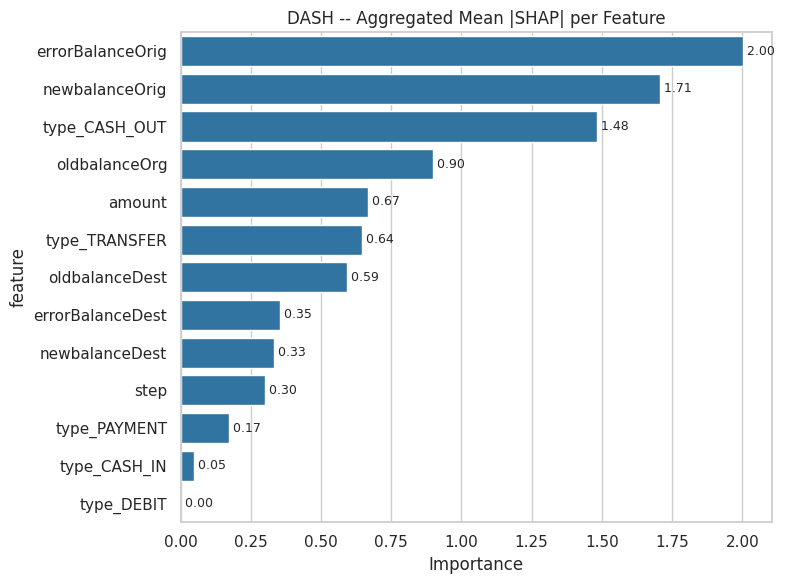

[19:39:02] dash_shap_aggregate -> completed | k=5


In [ ]:
# ============================================================
# SECTION 7.2 - DASH: PER-MODEL SHAP VALUES AND AGGREGATION
# SHAP is computed separately for each ensemble member and then averaged.
# That average is DASH's explanation.
# ============================================================
log_stage("dash_shap_aggregate", "started")

if 'diverse_models' not in dir():
    diverse_models = load_checkpoint('dash_diverse_models')

splits = load_checkpoint('data_splits')
X_test = splits['X_test']

EVAL_SAMPLE_SIZE = 2000
X_eval_sample = X_test.sample(n=min(EVAL_SAMPLE_SIZE, len(X_test)), random_state=SEED)

per_model_shap = []
for k, model_k in enumerate(diverse_models):
    print(f"Computing SHAP for model {k+1}/{len(diverse_models)}...")
    explainer_k = shap.TreeExplainer(model_k)
    per_model_shap.append(explainer_k.shap_values(X_eval_sample))

shap_stack = np.stack(per_model_shap, axis=0)
shap_dash_mean = shap_stack.mean(axis=0)
print(f"\nDASH aggregated SHAP shape: {shap_dash_mean.shape}")

save_checkpoint('dash_shap_values', {
    'per_model_shap': per_model_shap, 'shap_dash_mean': shap_dash_mean, 'X_eval_sample': X_eval_sample,
})

mean_abs_shap = np.abs(shap_dash_mean).mean(axis=0)
plot_feature_importance(X_eval_sample.columns, mean_abs_shap,
                         'DASH -- Aggregated Mean |SHAP| per Feature',
                         'dash_mean_shap_importance.png', pct=False)

log_stage("dash_shap_aggregate", "completed", f"k={len(diverse_models)}")


### 7.3 Consistency comparison on the matched evaluation set

For the comparison against ECGB to mean anything, DASH must be scored on exactly the
same rows, with exactly the same neighbourhood structure and metrics, as every other
model in Section 6. This cell reuses that section's evaluation sample and its
consistency functions rather than recomputing anything, then folds the DASH results
into the shared comparison table and redraws the figure with DASH included.


[19:55:23] dash_consistency_comparison -> started 
Scoring DASH on the SAME eval sample as the other models: 1060 rows (60 fraud, 1000 legit)
  SHAP for diverse model 1/5...
  SHAP for diverse model 2/5...
  SHAP for diverse model 3/5...
  SHAP for diverse model 4/5...
  SHAP for diverse model 5/5...
DASH aggregated SHAP (matched eval set) shape: (1060, 13)
  [DASH][legit] cosine=0.6889  jaccard_top5=0.7691  n_instances=1000
  [DASH][fraud] cosine=0.9442  jaccard_top5=0.8279  n_instances=60
  [DASH][fraud] neighbor-vs-random gap: +0.1738


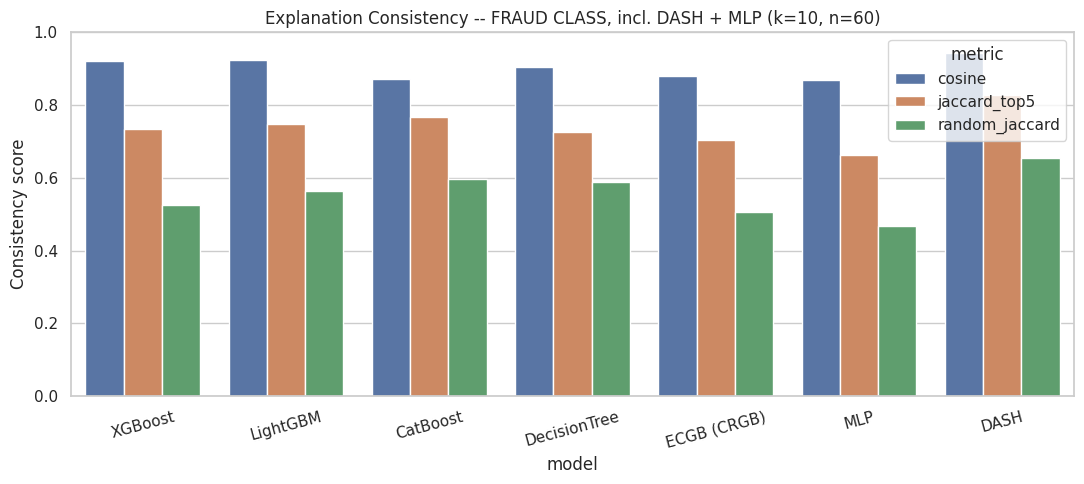

[19:56:40] dash_consistency_comparison -> completed | dash_fraud_gap=0.17379


In [ ]:
# ============================================================
# SECTION 7.3 - DASH: CONSISTENCY ON THE MATCHED EVALUATION SET
# DASH is scored on exactly the rows, neighbourhoods and metrics used for
# every other model in Section 6. Anything less and the comparison with ECGB
# would not be meaningful.
# ============================================================
log_stage("dash_consistency_comparison", "started")

assert 'compute_consistency_per_class' in dir(), \
    "Run Section 6 (explanation consistency) first - this cell reuses its functions."
assert 'X_eval' in dir() and 'y_eval' in dir(), \
    "Run Section 6 first - this cell reuses its stratified evaluation sample."

if 'diverse_models' not in dir():
    diverse_models = load_checkpoint('dash_diverse_models')

print(f"Scoring DASH on the SAME eval sample as the other models: "
      f"{len(X_eval)} rows ({y_eval.sum()} fraud, {len(y_eval)-y_eval.sum()} legit)")

per_model_shap_matched = []
for k, model_k in enumerate(diverse_models):
    print(f"  SHAP for diverse model {k+1}/{len(diverse_models)}...")
    explainer_k = shap.TreeExplainer(model_k)
    sv = explainer_k.shap_values(X_eval)
    per_model_shap_matched.append(extract_positive_class_shap(sv) if isinstance(sv, list) or np.asarray(sv).ndim == 3 else np.asarray(sv))
    del explainer_k
    gc.collect()

shap_dash_matched = np.stack(per_model_shap_matched, axis=0).mean(axis=0)
print(f"DASH aggregated SHAP (matched eval set) shape: {shap_dash_matched.shape}")

dash_per_class = compute_consistency_per_class(shap_dash_matched, X_eval_scaled, y_eval)
dash_random_fraud = random_pair_consistency(shap_dash_matched, y_eval, cls=1)
dash_gap = dash_per_class['fraud']['jaccard_top5'] - dash_random_fraud['jaccard_top5']

for cls_name, r in dash_per_class.items():
    print(f"  [DASH][{cls_name:5s}] cosine={r['cosine']:.4f}  jaccard_top5={r['jaccard_top5']:.4f}  "
          f"n_instances={r['n_instances']}")
print(f"  [DASH][fraud] neighbor-vs-random gap: {dash_gap:+.4f}")

# --- Fold the DASH results into the shared comparison table, checkpoint and
# figure. The MLP is already present, having been computed in Section 6. ---
consistency_df = pd.read_csv(f"{DIRS['logs']}/explanation_consistency_comparison_v2.csv")

dash_rows = []
for cls_name, r in dash_per_class.items():
    row = {'model': 'DASH', 'class': cls_name, **r}
    if cls_name == 'fraud':
        row.update({'random_jaccard': dash_random_fraud['jaccard_top5'], 'gap': dash_gap})
    dash_rows.append(row)

consistency_df = pd.concat([consistency_df, pd.DataFrame(dash_rows)], ignore_index=True)
consistency_df.to_csv(f"{DIRS['logs']}/explanation_consistency_comparison_v2.csv", index=False)

ckpt = load_checkpoint('explanation_consistency_results_v2')
all_per_class_results, gap_results = ckpt['per_class'], ckpt['gap']
all_per_class_results['DASH'] = dash_per_class
gap_results['DASH'] = {'random_jaccard': dash_random_fraud['jaccard_top5'], 'gap': dash_gap}
save_checkpoint('explanation_consistency_results_v2', {'per_class': all_per_class_results, 'gap': gap_results})

# Redraw the fraud-class comparison with DASH included, so that the figure in
# the dissertation shows every model on one set of axes.
fraud_df = consistency_df[consistency_df['class'] == 'fraud']
plot_df = fraud_df.melt(id_vars='model', value_vars=['cosine', 'jaccard_top5', 'random_jaccard'],
                         var_name='metric', value_name='score')
plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x='model', y='score', hue='metric')
plt.ylim(0, 1)
plt.title(f'Explanation Consistency -- FRAUD CLASS, incl. DASH + MLP (k={CONSISTENCY_K}, n={fraud_df["n_instances"].iloc[0]:.0f})')
plt.ylabel('Consistency score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/explanation_consistency_fraud_class_with_dash.png", dpi=150)
plt.show()

log_stage("dash_consistency_comparison", "completed", f"dash_fraud_gap={dash_gap:.5f}")


## 8. LIME and Its Agreement with SHAP

Having measured how stable each model's SHAP explanations are, I turn to the other
post-hoc method the dissertation examines. Two questions concern me here.

The first is **fidelity and cost**. LIME fits a local surrogate around each instance
and reports the R² of that surrogate, which is a direct measure of how well the
explanation actually approximates the model near that point. Because LIME is
per-instance and slow, I also record the wall-clock cost per explanation — a
consideration that matters a great deal for anything intended to run in production.

The second is **agreement**. If SHAP and LIME are both faithful accounts of the same
model's reasoning, they ought largely to agree on which features matter for a given
transaction. Where they disagree, at least one of them is misleading whoever is
reading it, and neither method announces which. I quantify this as the Jaccard
overlap of the top-5 feature sets, per instance, per model.


### 8.1 LIME fidelity and computational cost

LIME is subsampled to 100 rows drawn from the Section 6 evaluation sample, stratified
so that fraud is properly represented. I reuse that sample deliberately: the LIME
results then sit on the same instances as the SHAP results and the two are directly
comparable.


In [ ]:
# ============================================================
# SECTION 8.1 - LIME: LOCAL FIDELITY AND COMPUTATIONAL COST
# LIME reports the R-squared of the local surrogate it fits, which is a direct
# measure of how well the explanation approximates the model near that point.
# I record the wall-clock cost per instance alongside it, because that governs
# whether the method is usable in production at all.
# ============================================================
log_stage("lime_comparison", "started")
!pip install -q lime
from lime.lime_tabular import LimeTabularExplainer
import time as _time

assert 'X_eval' in dir() and 'y_eval' in dir(), \
    "Run Section 6 (SHAP consistency) first - this cell reuses its evaluation sample."
assert 'all_per_class_results' in dir() or os.path.exists(f"{DIRS['checkpoints']}/explanation_consistency_results_v2.pkl"), \
    "Run Section 6 first - the SHAP results are what LIME is compared against."

N_LIME_ROWS = 100   # LIME explains one instance at a time and is slow, so I
                    # take a stratified subsample of the Section 6 evaluation set
LIME_NUM_FEATURES = 5
LIME_NUM_SAMPLES = 500

splits = load_checkpoint('data_splits')
X_train = splits['X_train']
feature_names = list(X_train.columns)

fraud_take = min(20, int(y_eval.sum()))
legit_take = N_LIME_ROWS - fraud_take
lime_idx = pd.concat([
    pd.Series(y_eval[y_eval == 1].index).sample(fraud_take, random_state=SEED),
    pd.Series(y_eval[y_eval == 0].index).sample(legit_take, random_state=SEED),
])
X_lime = X_eval.loc[lime_idx].reset_index(drop=True)
y_lime = y_eval.loc[lime_idx].reset_index(drop=True)
print(f"LIME eval subsample: {len(X_lime)} rows ({y_lime.sum()} fraud, {len(y_lime)-y_lime.sum()} legit)")

# Reuse the MODEL_LOADERS dictionary from Section 6, so LIME is run over the
# same six models, loaded the same way, as the SHAP analysis.
def predict_proba_fn(model, kind):
    if kind == 'tree' and isinstance(model, xgb.Booster):
        return lambda x: np.column_stack([1 - _p, _p]) if (_p := model.predict(xgb.DMatrix(x, feature_names=feature_names))) is not None else None
    return lambda x: model.predict_proba(x)

lime_results = {}
ckpt = load_checkpoint('explanation_consistency_results_v2')
shap_per_class = ckpt['per_class']  # for fidelity cross-reference

for name, spec in MODEL_LOADERS.items():
    try:
        model = spec['load']()
    except FileNotFoundError:
        print(f"  {name}: skipped (not trained)")
        continue

    print(f"\nRunning LIME for {name}...")
    predict_fn = predict_proba_fn(model, spec['kind'])

    explainer = LimeTabularExplainer(
        training_data=X_train.values, feature_names=feature_names,
        class_names=['legit', 'fraud'], discretize_continuous=True, random_state=SEED
    )

    t0 = _time.time()
    per_instance_top5, fidelity_scores = [], []
    for i in range(len(X_lime)):
        exp = explainer.explain_instance(
            X_lime.values[i], predict_fn, num_features=LIME_NUM_FEATURES, num_samples=LIME_NUM_SAMPLES
        )
        top5 = frozenset(f for f, _ in exp.as_list())
        per_instance_top5.append(top5)
        fidelity_scores.append(exp.score)  # the local surrogate's R-squared,
                                           # which is LIME's own fidelity measure
    elapsed = _time.time() - t0

    lime_results[name] = {
        'mean_local_fidelity_r2': float(np.mean(fidelity_scores)),
        'sec_per_instance': elapsed / len(X_lime),
        'total_sec': elapsed,
    }
    print(f"  mean local fidelity (R^2): {np.mean(fidelity_scores):.4f}  |  "
          f"{elapsed/len(X_lime):.3f} sec/instance  |  {elapsed:.1f}s total for {len(X_lime)} rows")

    del explainer
    gc.collect()

lime_df = pd.DataFrame(lime_results).T
lime_df.index.name = 'model'
print("\n=== LIME fidelity + computational cost, by model ===")
display(lime_df)
lime_df.to_csv(f"{DIRS['logs']}/lime_fidelity_comparison.csv", index=False)
save_checkpoint('lime_fidelity_results', lime_results)

log_stage("lime_comparison", "completed", f"models={list(lime_results.keys())}, n_rows={len(X_lime)}")


[20:15:54] lime_comparison -> started 
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME eval subsample: 100 rows (20 fraud, 80 legit)

Running LIME for XGBoost...
  mean local fidelity (R^2): 0.1273  |  0.135 sec/instance  |  13.5s total for 100 rows

Running LIME for LightGBM...
  mean local fidelity (R^2): 0.1138  |  0.151 sec/instance  |  15.1s total for 100 rows

Running LIME for CatBoost...
  mean local fidelity (R^2): 0.0840  |  0.121 sec/instance  |  12.1s total for 100 rows

Running LIME for DecisionTree...
  mean local fidelity (R^2): 0.1538  |  0.119 sec/instance  |  11.9s total for 100 rows

Running LIME for ECGB (CRGB)...
  mean local fidelity (R^2): 0.3791  |  0.131 sec/instance  |  13.1s total for 100 rows

Running LIME for MLP...
  mean local fidelity (R^2): 0.1840  |  0.122 sec/instance  |  12.2s total for 100 rows

=== LIME fidelity + computational cost, by model ===


,mean_local_fidelity_r2,sec_per_instance,total_sec
model,,,
XGBoost,0.127274,0.135140,13.514010
LightGBM,0.113818,0.151469,15.146899
CatBoost,0.083992,0.120819,12.081917
DecisionTree,0.153840,0.119177,11.917706
ECGB (CRGB),0.379099,0.131159,13.115860
MLP,0.184036,0.121687,12.168719


[20:29:01] lime_comparison -> completed | models=['XGBoost', 'LightGBM', 'CatBoost', 'DecisionTree', 'ECGB (CRGB)', 'MLP'], n_rows=100


### 8.2 Per-instance agreement between SHAP and LIME

For each instance I take the top five features by SHAP and the top five by LIME and
compute their Jaccard overlap. LIME returns discretised condition strings such as
`amount <= 1250.00`, so I extract the feature name before comparing.


In [ ]:
# ============================================================
# SECTION 8.2 - SHAP VERSUS LIME: PER-INSTANCE TOP-5 AGREEMENT
# If both methods are faithful accounts of the same model, they should largely
# agree on which features drive a given prediction. Where they diverge, at
# least one is misleading its reader, and neither method says which.
# ============================================================
log_stage("shap_lime_agreement", "started")

assert 'X_lime' in dir(), "Run Section 8.1 first - this cell reuses its subsample."

def extract_feature_name(cond_str, feature_names):
    """LIME returns discretised condition strings such as 'amount <= 1250.00',
    so I extract the bare feature name before comparing the two top-5 sets."""
    for fn in feature_names:
        if fn in cond_str:
            return fn
    return cond_str  # fallback, shouldn't normally hit

def get_shap_top5_batch(model, kind, X):
    if kind == 'tree':
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X)
        del explainer
    else:  # the MLP, which needs the model-agnostic KernelExplainer
        background = shap.sample(X, min(50, len(X)), random_state=SEED)
        predict_fn = lambda x: model.predict_proba(x)
        explainer = shap.KernelExplainer(predict_fn, background)
        sv = explainer.shap_values(X, nsamples=100)
        del explainer
    shap_matrix = extract_positive_class_shap(sv)
    return [frozenset(feature_names[i] for i in np.argsort(-np.abs(row))[:5]) for row in shap_matrix]

agreement_results = {}
for name, spec in MODEL_LOADERS.items():
    try:
        model = spec['load']()
    except FileNotFoundError:
        continue

    print(f"Computing SHAP-vs-LIME agreement for {name}...")
    X_input = X_lime.values
    shap_top5 = get_shap_top5_batch(model, spec['kind'], X_input)

    predict_fn = predict_proba_fn(model, spec['kind'])
    explainer = LimeTabularExplainer(
        training_data=X_train.values, feature_names=feature_names,
        class_names=['legit', 'fraud'], discretize_continuous=True, random_state=SEED
    )
    jaccards = []
    for i in range(len(X_lime)):
        exp = explainer.explain_instance(X_lime.values[i], predict_fn, num_features=5, num_samples=LIME_NUM_SAMPLES)
        lime_top5 = frozenset(extract_feature_name(f, feature_names) for f, _ in exp.as_list())
        s_top5 = shap_top5[i]
        jaccards.append(len(s_top5 & lime_top5) / len(s_top5 | lime_top5))

    agreement_results[name] = {'mean_jaccard_shap_lime': float(np.mean(jaccards))}
    print(f"  mean SHAP-LIME top-5 Jaccard agreement: {np.mean(jaccards):.4f}")
    del explainer
    gc.collect()

agreement_df = pd.DataFrame(agreement_results).T
agreement_df.index.name = 'model'
print("\n=== SHAP vs LIME agreement, by model ===")
display(agreement_df)
agreement_df.to_csv(f"{DIRS['logs']}/shap_lime_agreement.csv", index=False)
save_checkpoint('shap_lime_agreement_results', agreement_results)

log_stage("shap_lime_agreement", "completed", f"models={list(agreement_results.keys())}")


[20:42:35] shap_lime_agreement -> started 
Computing SHAP-vs-LIME agreement for XGBoost...
  mean SHAP-LIME top-5 Jaccard agreement: 0.2990
Computing SHAP-vs-LIME agreement for LightGBM...
  mean SHAP-LIME top-5 Jaccard agreement: 0.3323
Computing SHAP-vs-LIME agreement for CatBoost...
  mean SHAP-LIME top-5 Jaccard agreement: 0.4259
Computing SHAP-vs-LIME agreement for DecisionTree...
  mean SHAP-LIME top-5 Jaccard agreement: 0.3974
Computing SHAP-vs-LIME agreement for ECGB (CRGB)...
  mean SHAP-LIME top-5 Jaccard agreement: 0.3440
Computing SHAP-vs-LIME agreement for MLP...


  0%|          | 0/100 [00:00<?, ?it/s]

  mean SHAP-LIME top-5 Jaccard agreement: 0.4954

=== SHAP vs LIME agreement, by model ===


,mean_jaccard_shap_lime
model,
XGBoost,0.298968
LightGBM,0.332341
CatBoost,0.425913
DecisionTree,0.397421
ECGB (CRGB),0.344048
MLP,0.495397


[20:55:37] shap_lime_agreement -> completed | models=['XGBoost', 'LightGBM', 'CatBoost', 'DecisionTree', 'ECGB (CRGB)', 'MLP']


## 9. Feature Importance Across All Models

Feature importance is not the same construct as explanation consistency, but it
answers a question a reader will reasonably ask: do these models agree about what
drives fraud in PaySim, and does ECGB's importance profile look anything like the
others'?

One caveat I want to state explicitly, because it constrains how the combined figure
should be read. Each model family reports importance in its own way — split gain for
the XGBoost family, `PredictionValuesChange` for CatBoost, impurity decrease for the
decision tree, permutation importance for the MLP, mean absolute SHAP for DASH. These
are not on a common scale and I do not treat them as directly comparable magnitudes.
What is comparable is the *ranking* within each panel, and that is what I read from
the figure.


### 9.1 ECGB feature importance

I compute ECGB's importance two ways: split gain, matching the other XGBoost-family
panels, and mean absolute SHAP, matching the CatBoost and DASH panels. The SHAP figure
is computed on the same evaluation sample as Section 6, so the two sets of results
line up rather than describing different subsets of the data.

A small implementation detail: boosters trained through `xgb.train` with a custom
objective lose their feature names, so I reattach them before computing importance.


[12:25:31] crgb_feature_importance -> started 
Loaded ECGB booster: 239 rounds, 13 features


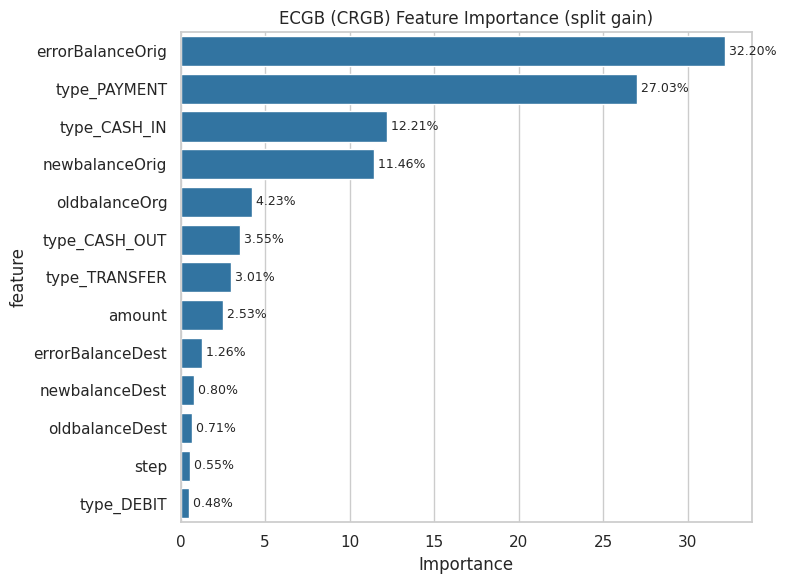

Eval sample rebuilt: 1060 rows (same SEED as Cell 36)


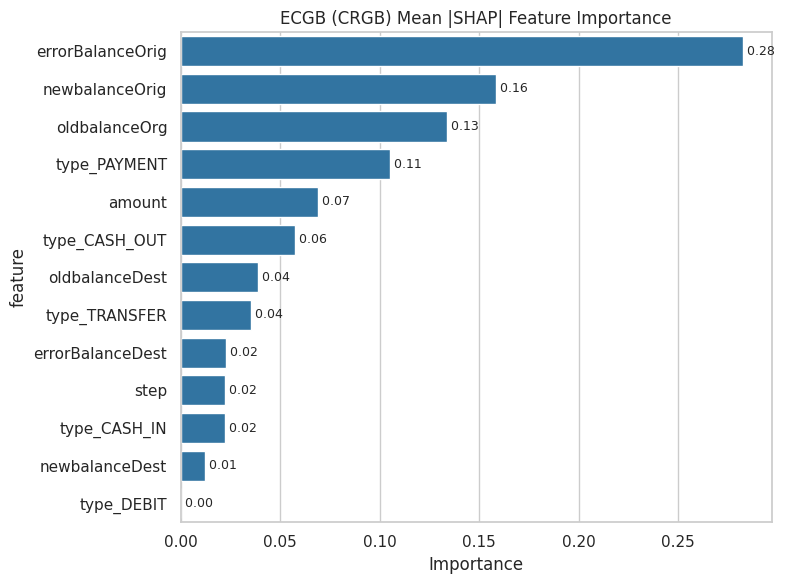


Top 5 by split gain:  ['errorBalanceOrig', 'type_PAYMENT', 'type_CASH_IN', 'newbalanceOrig', 'oldbalanceOrg']
Top 5 by mean |SHAP|: ['errorBalanceOrig', 'newbalanceOrig', 'oldbalanceOrg', 'type_PAYMENT', 'amount']
[12:25:43] crgb_feature_importance -> completed


In [ ]:
# ============================================================
# SECTION 9.1 - ECGB FEATURE IMPORTANCE
# Computed two ways: split gain, matching the other XGBoost-family panels, and
# mean absolute SHAP, matching the CatBoost and DASH panels.
# This cell is self-contained - it loads saved checkpoints and model files and
# retrains nothing, so it only needs Section 1 to have run.
# ============================================================
log_stage("crgb_feature_importance", "started")

splits = load_checkpoint('data_splits')
assert splits is not None, "checkpoints/data_splits.pkl not found - run Section 3 once."
X_train, X_test, y_test = splits['X_train'], splits['X_test'], splits['y_test']
FEATURES = list(X_train.columns)

# --- Load the trained booster. Boosters trained through xgb.train with a
# custom objective lose their feature names, so I reattach them here. ---
booster_ecgb = xgb.Booster()
booster_ecgb.load_model(f"{DIRS['models']}/crgb_final_v2.json")
booster_ecgb.feature_names = FEATURES          # custom-objective boosters lose names
print(f"Loaded ECGB booster: {booster_ecgb.num_boosted_rounds()} rounds, {len(FEATURES)} features")

# --- (A) Split-gain importance, the same measure used for the XGBoost and
# LightGBM panels, so those three are directly comparable to each other. ---
gain_raw = booster_ecgb.get_score(importance_type='gain')
gain_vals = np.array([gain_raw.get(f, 0.0) for f in FEATURES], dtype=float)
gain_pct = 100.0 * gain_vals / gain_vals.sum() if gain_vals.sum() > 0 else gain_vals

imp_gain = plot_feature_importance(
    FEATURES, gain_pct,
    'ECGB (CRGB) Feature Importance (split gain)',
    'ecgb_feature_importance_gain.png', pct=True
)

# --- (B) Mean absolute SHAP, the same measure used for the CatBoost and DASH
# panels, computed on the same evaluation sample as Section 6 so that these
# figures line up with Table 4.7 and Figure 4.6 rather than describing a
# different subset of the data. ---
MIN_FRAUD_ROWS, N_LEGIT_ROWS = 60, 1000
fraud_idx = pd.Series(y_test[y_test == 1].index).sample(
    n=min(MIN_FRAUD_ROWS, int((y_test == 1).sum())), random_state=SEED)
legit_idx = pd.Series(y_test[y_test == 0].index).sample(
    n=min(N_LEGIT_ROWS, int((y_test == 0).sum())), random_state=SEED)
X_eval = X_test.loc[pd.concat([fraud_idx, legit_idx])].reset_index(drop=True)
print(f"Evaluation sample rebuilt: {len(X_eval)} rows (same seed as Section 6)")


def _positive_class_shap(sv):
    if isinstance(sv, list):
        return np.asarray(sv[1] if len(sv) > 1 else sv[0])
    arr = np.asarray(sv)
    return arr[:, :, -1] if arr.ndim == 3 else arr


shap_ecgb = _positive_class_shap(shap.TreeExplainer(booster_ecgb).shap_values(X_eval))
mean_abs_shap_ecgb = np.abs(shap_ecgb).mean(axis=0)

imp_shap = plot_feature_importance(
    FEATURES, mean_abs_shap_ecgb,
    'ECGB (CRGB) Mean |SHAP| Feature Importance',
    'ecgb_mean_shap_importance.png', pct=False
)

save_checkpoint('ecgb_feature_importance', {
    'features': FEATURES,
    'gain_pct': gain_pct,
    'mean_abs_shap': mean_abs_shap_ecgb,
    'top5_gain': imp_gain.head(5).to_dict('records'),
    'top5_shap': imp_shap.head(5).to_dict('records'),
})

print("\nTop 5 by split gain: ", [r['feature'] for r in imp_gain.head(5).to_dict('records')])
print("Top 5 by mean |SHAP|:", [r['feature'] for r in imp_shap.head(5).to_dict('records')])
log_stage("crgb_feature_importance", "completed")


### 9.2 Combined figure across all models

One figure, one panel per model, each using the importance measure appropriate to that
model. I deliberately leave off a figure title, because the caption in the
dissertation supplies it and I did not want the two to disagree.

> **Note on this cell's output.** This is the one cell in the notebook that
> carries no saved output. Its last run raised a `TypeError` on the DASH panel:
> I was reading the aggregated SHAP matrix from the wrong checkpoint key, so
> `np.abs()` was handed a dictionary. The lookup is fixed in the code below, and
> re-running the cell regenerates the figure. I have left the cell unexecuted
> rather than pasting in output from a different run, since every other output in
> this notebook comes from the run it sits beneath.


In [ ]:
# ==========================================================
# SECTION 9.2 - COMBINED FEATURE-IMPORTANCE FIGURE (FIGURE 4.7)
# ==========================================================
# One panel per model, each using the importance measure appropriate to that
# model family - so the rankings within a panel are meaningful, but the
# magnitudes are not comparable across panels, and I do not read them that way.
log_stage("figure_4_7_combined", "started")

panels = []   # (panel_title, values_aligned_to_FEATURES)

# XGBoost and LightGBM: split gain
for label, fname in [('XGBoost', 'xgboost_final.pkl'), ('LightGBM', 'lightgbm_final.pkl')]:
    try:
        m = pickle.load(open(f"{DIRS['models']}/{fname}", 'rb'))
        if label == 'XGBoost':
            raw = m.get_booster().get_score(importance_type='gain')
            v = np.array([raw.get(f, 0.0) for f in FEATURES], dtype=float)
        else:
            v = np.asarray(m.booster_.feature_importance(importance_type='gain'), dtype=float)
        panels.append((f'{label} (split gain)', 100.0 * v / max(v.sum(), 1e-12)))
    except FileNotFoundError:
        print(f"  skipped {label} -- {fname} not found")

# CatBoost: its own PredictionValuesChange measure
try:
    # Named cb_model, not cb: cb is the catboost module alias bound in Section 1,
    # and rebinding it here broke every later cell that constructed a CatBoost.
    cb_model = pickle.load(open(f"{DIRS['models']}/catboost_final.pkl", 'rb'))
    panels.append(('CatBoost (normalised)',
                   np.asarray(cb_model.get_feature_importance(), dtype=float)))
except FileNotFoundError:
    print("  skipped CatBoost")

# Decision tree: impurity decrease
try:
    dt_model = pickle.load(open(f"{DIRS['models']}/dt_final.pkl", 'rb'))
    panels.append(('Decision Tree (normalised)',
                   np.asarray(dt_model.feature_importances_, dtype=float) * 100))
except FileNotFoundError:
    print("  skipped Decision Tree")

# MLP: permutation importance on a 5,000-row sample, as in Section 4.5.3
try:
    mlp_model = pickle.load(open(f"{DIRS['models']}/mlp_final.pkl", 'rb'))
    samp = X_test.sample(n=min(5000, len(X_test)), random_state=SEED)
    perm = permutation_importance(mlp_model, samp, y_test.loc[samp.index],
                                  n_repeats=5, random_state=SEED, scoring='average_precision')
    panels.append(('MLP (permutation)', perm.importances_mean * 100))
except FileNotFoundError:
    print("  skipped MLP")

# ECGB: split gain, matching the other two XGBoost-family panels
panels.append(('ECGB (split gain)', gain_pct))

# DASH: mean absolute SHAP aggregated across the five diverse models
dash_shap = load_checkpoint('dash_shap_values')
if dash_shap is not None:
    # The Section 7.2 checkpoint stores the aggregated matrix under
    # 'shap_dash_mean'. I look the key up tolerantly rather than assuming it,
    # having already been caught out once by guessing wrong.
    arr = None
    if isinstance(dash_shap, dict):
        for key in ('shap_dash_mean', 'mean_shap'):
            if key in dash_shap:
                arr = np.asarray(dash_shap[key], dtype=float)
                break
    else:
        arr = np.asarray(dash_shap, dtype=float)

    if arr is None:
        print("  skipped DASH - checkpoint present but no aggregated SHAP matrix in it")
    else:
        panels.append(('DASH (mean |SHAP|, 5 models)', np.abs(arr).mean(axis=0)))
else:
    print("  skipped DASH - checkpoint 'dash_shap_values' not found")

ncols = 4
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (title, vals) in zip(axes, panels):
    d = (pd.DataFrame({'feature': FEATURES, 'importance': np.asarray(vals, dtype=float)})
           .sort_values('importance', ascending=False).head(10))
    ax.barh(d['feature'][::-1], d['importance'][::-1], color=PALETTE['accent'])
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)

for ax in axes[len(panels):]:
    ax.axis('off')

plt.tight_layout()   # no suptitle: the dissertation caption supplies the title,
                     # and I did not want the two to be able to disagree
out_path = f"{DIRS['figures']}/figure_4_7_feature_importance_all_models.png"
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSaved: {out_path}")
print(f"Panels ({len(panels)}): {[t for t, _ in panels]}")
log_stage("figure_4_7_combined", "completed", f"panels={len(panels)}")


## 10. Final Comparison and Significance Testing

The leaderboard across all models on the test set, followed by a significance test
across cross-validation folds.

I separate these two deliberately. "My model has the highest score" and "my model is
significantly better" are different claims, and early in this project I was treating
them as one. A single test-set number is a single observation, and the gap between
two models can easily be smaller than the variation between folds of the same model.
So rather than comparing test-set numbers by eye, I test ECGB against each baseline
with a paired Wilcoxon signed-rank test on per-fold PR-AUC. I use Wilcoxon rather
than a paired t-test because with only five folds I am not willing to assume
normality of the differences.

DASH is deliberately absent from the significance table. It is an
explanation-aggregation ensemble rather than a standalone predictive model with its
own cross-validation pipeline, so there are no comparable per-fold scores to test
against. Inserting a placeholder would misrepresent what DASH is and what it is for.


Models currently registered: ['XGBoost', 'LightGBM', 'CatBoost', 'DecisionTree', 'ECGB (CRGB)', 'MLP']

=== Final test-set leaderboard (sorted by PR-AUC) ===


,recall,precision,f1,pr_auc,roc_auc
model,,,,,
CatBoost,0.997565,0.941413,0.968676,0.998636,0.999586
LightGBM,0.997565,0.966392,0.981731,0.998411,0.999823
XGBoost,0.997565,0.956801,0.976758,0.998251,0.999898
DecisionTree,0.998174,0.869104,0.929178,0.998008,0.999330
ECGB (CRGB),0.980523,1.000000,0.990166,0.997615,0.999546
MLP,0.992696,0.288315,0.446849,0.964341,0.999180



ECGB fold PR-AUC scores: [0.99690047 0.9945731  0.9946193  0.99743218 0.99460462]

=== Paired significance test: ECGB vs. each model (PR-AUC, 5 folds) ===
  ECGB (0.99563) vs XGBoost (0.99645): diff=-0.00083, p=0.0625 (not significant)
  ECGB (0.99563) vs LightGBM (0.99658): diff=-0.00095, p=0.0625 (not significant)
  ECGB (0.99563) vs CatBoost (0.99693): diff=-0.00130, p=0.0625 (not significant)
  ECGB (0.99563) vs DecisionTree (0.99581): diff=-0.00019, p=0.4375 (not significant)
  ECGB (0.99563) vs MLP (0.93454): diff=+0.06109, p=0.0625 (not significant)
  DASH: not tested (no comparable per-fold predictive CV pipeline exists -- see note above)

=== Significance summary ===


,comparison,ecgb_mean_pr_auc,other_mean_pr_auc,mean_diff,p_value,significant_at_0.05
0,ECGB vs XGBoost,0.995626,0.996451,-0.000825,0.0625,False
1,ECGB vs LightGBM,0.995626,0.996579,-0.000954,0.0625,False
2,ECGB vs CatBoost,0.995626,0.996927,-0.001301,0.0625,False
3,ECGB vs DecisionTree,0.995626,0.995813,-0.000187,0.4375,False
4,ECGB vs MLP,0.995626,0.934538,0.061088,0.0625,False


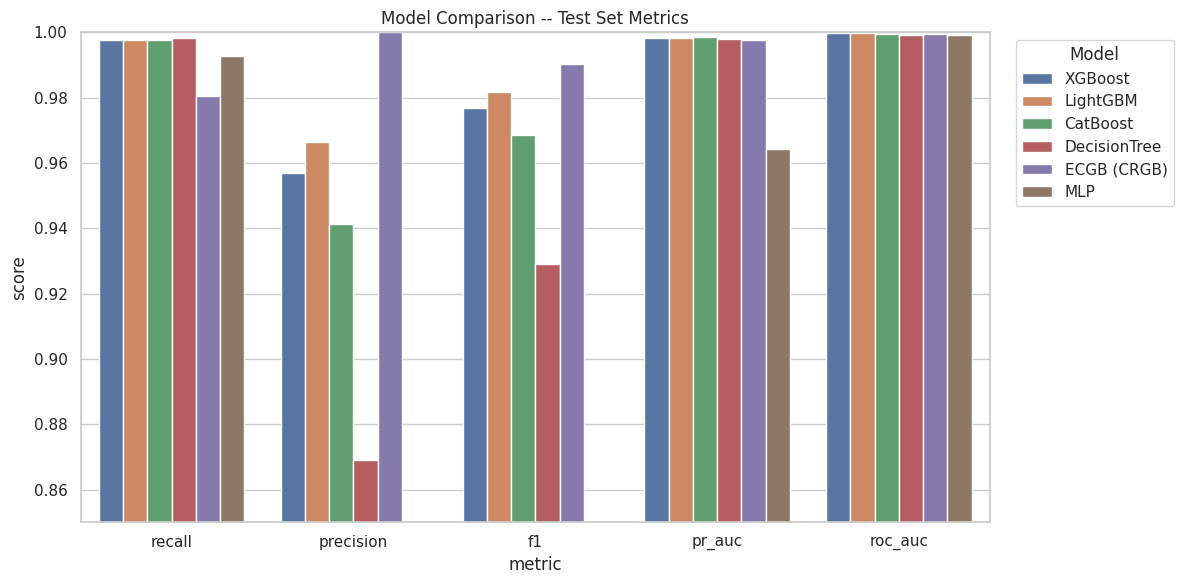

[20:01:02] final_comparison -> completed | models=['XGBoost', 'LightGBM', 'CatBoost', 'DecisionTree', 'ECGB (CRGB)', 'MLP']


In [ ]:
# ============================================================
# SECTION 10 - FINAL COMPARISON: LEADERBOARD AND SIGNIFICANCE TESTING
# ============================================================
from scipy.stats import wilcoxon

all_results = load_checkpoint('all_model_results', default={})
print("Models currently registered:", list(all_results.keys()))

results_df = pd.DataFrame(all_results).T
results_df.index.name = 'model'
print("\n=== Final test-set leaderboard (sorted by PR-AUC) ===")
display(results_df.sort_values('pr_auc', ascending=False))

# --- Significance testing: ECGB against each baseline, on per-fold PR-AUC. ---
# A single test-set number is one observation, and the gap between two models is
# often smaller than the variation between folds of the same model - so I test
# across folds rather than comparing test scores by eye. Wilcoxon rather than a
# paired t-test, because with five folds I will not assume normality.
#
# DASH is deliberately absent. It is an explanation-aggregation ensemble, not a
# standalone predictive model with its own cross-validation pipeline, so no
# comparable per-fold scores exist. A placeholder would misrepresent what it is.
CV_FILES = {
    'XGBoost':      'xgboost_cv_all_folds.csv',
    'LightGBM':     'lightgbm_cv_all_folds.csv',
    'CatBoost':     'catboost_cv_all_folds.csv',
    'DecisionTree': 'dt_cv_all_folds.csv',
    'MLP':          'mlp_cv_all_folds.csv',
}
ECGB_CV_FILE = 'crgb_cv_all_folds_v2.csv'

def load_fold_scores(fname, metric='pr_auc'):
    path = f"{DIRS['logs']}/{fname}"
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if 'trial' in df.columns:
        best_label = load_checkpoint(f"{fname.split('_cv_')[0]}_best_trial_label")
        if best_label is not None:
            df = df[df['trial'] == best_label]
    return df.sort_values('fold')[metric].values

ecgb_scores = load_fold_scores(ECGB_CV_FILE, metric='pr_auc')
if ecgb_scores is None:
    print(f"\nCould not find {ECGB_CV_FILE} -- check the CV cell saved to that filename.")
else:
    print(f"\nECGB fold PR-AUC scores: {ecgb_scores}")
    print("\n=== Paired significance test: ECGB vs. each model (PR-AUC, 5 folds) ===")
    sig_results = []
    for model_name, fname in CV_FILES.items():
        other_scores = load_fold_scores(fname, metric='pr_auc')
        if other_scores is None or len(other_scores) != len(ecgb_scores):
            print(f"  {model_name}: skipped (missing or mismatched fold count)")
            continue
        try:
            stat, p_value = wilcoxon(ecgb_scores, other_scores)
        except ValueError as e:
            print(f"  {model_name}: Wilcoxon failed ({e})")
            continue
        mean_diff = ecgb_scores.mean() - other_scores.mean()
        sig_results.append({'comparison': f'ECGB vs {model_name}', 'ecgb_mean_pr_auc': ecgb_scores.mean(),
                             'other_mean_pr_auc': other_scores.mean(), 'mean_diff': mean_diff,
                             'p_value': p_value, 'significant_at_0.05': p_value < 0.05})
        marker = '***' if p_value < 0.05 else '(not significant)'
        print(f"  ECGB ({ecgb_scores.mean():.5f}) vs {model_name} ({other_scores.mean():.5f}): "
              f"diff={mean_diff:+.5f}, p={p_value:.4f} {marker}")

    print("  DASH: not tested - no comparable per-fold CV scores exist (see note above)")

    if sig_results:
        sig_df = pd.DataFrame(sig_results)
        print("\n=== Significance summary ===")
        display(sig_df)
        sig_df.to_csv(f"{DIRS['logs']}/crgb_significance_tests.csv", index=False)

# --- Comparison chart. The y-axis starts at 0.85 because every model scores
# above 0.9 and the differences are invisible on a full 0-1 axis. The axis is
# truncated, not the data, and the leaderboard above gives the exact figures. ---
metrics_to_plot = ['recall', 'precision', 'f1', 'pr_auc', 'roc_auc']
plot_df = results_df[metrics_to_plot].reset_index().melt(id_vars='model', var_name='metric', value_name='score')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='metric', y='score', hue='model')
plt.title('Model Comparison -- Test Set Metrics')
plt.ylim(0.85, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Model')
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/final_model_comparison.png", dpi=150)
plt.show()

log_stage("final_comparison", "completed", f"models={list(results_df.index)}")


## 11. System Deployment: The Explainable Auditor

This section builds the deployment described in the dissertation's *System
Deployment* section and shown in Figure 4.1: a four-tier, Docker-containerised
application that wraps the trained ECGB model and its SHAP and LIME explainers into a
tool an investigator or regulator could actually use.

- **Presentation** — a Dash interface, styled as a case file, where an investigator
  submits a transaction and sees the prediction alongside SHAP and LIME panels.
- **Application** — a Flask REST API (`/predict`, `/explain`) with an audit logger
  firing on every request.
- **Inference** — loads the saved ECGB booster and runs a SHAP `TreeExplainer` and a
  LIME local surrogate, returning the surrogate's fidelity R² with the explanation.
- **Persistence** — a MongoDB audit store recording model id, input features,
  prediction, explanation, timestamp and user, which is what allows the system to
  satisfy the EU AI Act's transparency duty and the GDPR Article 22 right to a
  meaningful explanation.

The model is wrapped exactly as evaluated in Section 5, with no modification, so the
deployed system's behaviour is the behaviour I measured.

Every file below is generated onto disk under `DEPLOY_DIR`, so the application folder
can be taken out of this notebook and run with `docker compose up` anywhere.


### 11.1 Scaffolding

Directory layout for the generated application, and a small `write_file` helper that
echoes each file's size as it is written so I can sanity-check a re-run of this
section without opening every file.


In [ ]:
# ============================================================
# SECTION 11.1 - DEPLOYMENT SCAFFOLDING: DIRECTORIES AND write_file()
# ============================================================
log_stage("deployment_setup", "started")

DEPLOY_DIR = f"{BASE_DIR}/deployment/explainable_auditor"
APP_DIR = f"{DEPLOY_DIR}/app"
ARTIFACT_DIR = f"{DEPLOY_DIR}/model_artifacts"
for d in [APP_DIR, ARTIFACT_DIR]:
    os.makedirs(d, exist_ok=True)

def write_file(path, content):
    """Write a deployment source file to disk and echo its size, so that I can
    sanity-check a re-run of this section without opening every file."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        f.write(content)
    print(f"  wrote {path}  ({len(content):,} bytes)")

print(f"Deployment root: {DEPLOY_DIR}")
log_stage("deployment_setup", "completed", f"root={DEPLOY_DIR}")


[20:21:13] deployment_setup -> started 
Deployment root: /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor
[20:21:13] deployment_setup -> completed | root=/content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor


### 11.2 Exporting the model artifacts

The three things the deployment needs: the trained ECGB booster, the feature names in
the order the model expects them, and a sample of real training rows for LIME to build
its local neighbourhood sampler from.


In [ ]:
# ============================================================
# SECTION 11.2 - EXPORT THE MODEL ARTIFACTS THE DEPLOYMENT NEEDS
# ============================================================
import shutil

log_stage("deployment_export_artifacts", "started")

splits = load_checkpoint('data_splits')
feature_cols = splits['feature_cols']
X_train = splits['X_train']

# The exact booster evaluated in Section 5.5, copied unmodified. The deployed
# system has to behave the way the model I measured behaves, so nothing is
# retrained, re-tuned or re-thresholded on the way into the container.
shutil.copy(f"{DIRS['models']}/crgb_final_v2.json", f"{ARTIFACT_DIR}/crgb_final_v2.json")

with open(f"{ARTIFACT_DIR}/feature_names.json", "w") as f:
    json.dump(feature_cols, f)

# LIME needs a background sample to build its local neighbourhood sampler from.
# 500 real training rows is sufficient and keeps the shipped artifact small.
X_train[feature_cols].sample(n=min(500, len(X_train)), random_state=SEED).to_csv(
    f"{ARTIFACT_DIR}/lime_background.csv", index=False
)

print("Model artifacts exported:")
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    print(" ", fname)
log_stage("deployment_export_artifacts", "completed", f"n_features={len(feature_cols)}")


[20:21:13] deployment_export_artifacts -> started 
Model artifacts exported:
  crgb_final_v2.json
  feature_names.json
  lime_background.csv
[20:21:15] deployment_export_artifacts -> completed | n_features=13


### 11.3 Inference tier — `app/inference.py`

Loads the ECGB booster and puts SHAP's `TreeExplainer` and a LIME
`LimeTabularExplainer` behind a single `predict()` / `explain()` interface, so neither
tier above it needs to know how the explanations are produced.


In [ ]:
write_file(f"{APP_DIR}/inference.py", '''
"""
Inference tier -- The Explainable Auditor
Loads the trained ECGB (CRGB) booster and produces, for a single
transaction: a fraud probability, a SHAP TreeExplainer attribution,
and a LIME local-surrogate explanation (with its fidelity R^2).
"""
import json
import os

import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from lime.lime_tabular import LimeTabularExplainer

ARTIFACT_DIR = os.environ.get(
    "MODEL_ARTIFACT_DIR",
    os.path.join(os.path.dirname(__file__), "..", "model_artifacts"),
)
MODEL_ID = "ECGB-CRGB-v2"


class ExplainableAuditorModel:
    def __init__(self, artifact_dir=ARTIFACT_DIR):
        with open(os.path.join(artifact_dir, "feature_names.json")) as f:
            self.feature_names = json.load(f)

        self.booster = xgb.Booster()
        self.booster.load_model(os.path.join(artifact_dir, "crgb_final_v2.json"))

        background = pd.read_csv(os.path.join(artifact_dir, "lime_background.csv"))
        self.background = background[self.feature_names]

        self.shap_explainer = shap.TreeExplainer(self.booster)
        self.lime_explainer = LimeTabularExplainer(
            training_data=self.background.values,
            feature_names=self.feature_names,
            class_names=["legit", "fraud"],
            discretize_continuous=True,
            random_state=42,
        )

    def _to_frame(self, record: dict) -> pd.DataFrame:
        missing = [f for f in self.feature_names if f not in record]
        if missing:
            raise ValueError(f"Missing required feature(s): {missing}")
        row = {f: record[f] for f in self.feature_names}
        return pd.DataFrame([row], columns=self.feature_names)

    def _predict_proba_batch(self, X: np.ndarray) -> np.ndarray:
        dmat = xgb.DMatrix(X, feature_names=self.feature_names)
        margin = self.booster.predict(dmat, output_margin=True)
        proba = 1.0 / (1.0 + np.exp(-margin))
        return np.column_stack([1 - proba, proba])

    def predict(self, record: dict) -> dict:
        X = self._to_frame(record)
        dmat = xgb.DMatrix(X, feature_names=self.feature_names)
        margin = self.booster.predict(dmat, output_margin=True)[0]
        proba = float(1.0 / (1.0 + np.exp(-margin)))
        return {
            "model_id": MODEL_ID,
            "fraud_probability": proba,
            "prediction": "fraud" if proba >= 0.5 else "legit",
        }

    def explain(self, record: dict, top_k: int = 5, lime_num_samples: int = 500) -> dict:
        X = self._to_frame(record)

        shap_values = self.shap_explainer.shap_values(X)
        shap_row = np.asarray(shap_values)[0]
        shap_ranked = sorted(
            zip(self.feature_names, shap_row.tolist()), key=lambda kv: -abs(kv[1])
        )[:top_k]

        lime_exp = self.lime_explainer.explain_instance(
            X.values[0], self._predict_proba_batch, num_features=top_k, num_samples=lime_num_samples,
        )

        return {
            "model_id": MODEL_ID,
            "shap_top_features": [{"feature": f, "shap_value": v} for f, v in shap_ranked],
            "lime_top_features": [{"condition": c, "weight": w} for c, w in lime_exp.as_list()],
            "lime_fidelity_r2": float(lime_exp.score),
        }


_model_singleton = None


def get_model() -> ExplainableAuditorModel:
    global _model_singleton
    if _model_singleton is None:
        _model_singleton = ExplainableAuditorModel()
    return _model_singleton
''')


  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/app/inference.py  (3,461 bytes)


### 11.4 Persistence tier — `app/audit.py`

The MongoDB audit store. Every decision is written as a single auditable record.

Lookups use my own `decision_id`, a uuid4 hex string, rather than Mongo's native
`_id`. I changed this after the smoke test failed: MongoDB issues 24-character hex
ObjectIds, mongomock issues its own format, and code that assumed the former broke
against the latter. Generating the identifier myself means the backend's id format
never leaks out of this module, and the tier behaves identically whichever backend is
in use.

Setting `MONGO_URI=mongomock` substitutes an in-memory client with the same
interface, which is how the benchmark further down times this tier without a live
MongoDB.


In [ ]:
write_file(f"{APP_DIR}/audit.py", '''
"""
Persistence tier -- MongoDB audit store.
Every /predict and /explain call is written here as a single, auditable
decision record: model id, input features, prediction, explanation,
timestamp and user -- satisfying the EU AI Act's transparency/logging
duty and the GDPR Article 22 right to a meaningful explanation. Also
turns any logged decision into a regulator-facing export.

Lookups use our own `decision_id` (a uuid4 hex string) rather than
Mongo's native `_id`, so this works identically whether the backend is
a real MongoDB (ObjectId), mongomock (whatever id type it happens to
generate), or anything else -- the id format never leaks out of this
module.
"""
import os
import uuid
from datetime import datetime, timezone

MONGO_URI = os.environ.get("MONGO_URI", "mongodb://localhost:27017")
MONGO_DB = os.environ.get("MONGO_DB", "explainable_auditor")

_client = None


def _get_collection():
    """Lazily creates the Mongo client. MONGO_URI='mongomock' swaps in an
    in-memory mock client, which is how the deployment-evaluation cell in
    the notebook benchmarks this tier without a real MongoDB instance."""
    global _client
    if _client is None:
        if MONGO_URI == "mongomock":
            import mongomock
            _client = mongomock.MongoClient()
        else:
            import pymongo
            _client = pymongo.MongoClient(MONGO_URI, serverSelectionTimeoutMS=2000)
    return _client[MONGO_DB]["audit_log"]


def log_decision(model_id, input_features, prediction, explanation=None, user="anonymous"):
    decision_id = uuid.uuid4().hex
    record = {
        "decision_id": decision_id,
        "model_id": model_id,
        "input_features": input_features,
        "prediction": prediction,
        "explanation": explanation,
        "user": user,
        "timestamp": datetime.now(timezone.utc).isoformat(),
    }
    _get_collection().insert_one(record)
    record["_id"] = decision_id  # kept for API-response backward-compatibility
    return record


def get_decision(decision_id):
    doc = _get_collection().find_one({"decision_id": decision_id})
    if doc and "_id" in doc:
        doc["_id"] = str(doc["_id"])
    return doc


def export_regulator_report(decision_id):
    """Flattens a single logged decision into a human-readable audit report."""
    doc = get_decision(decision_id)
    if doc is None:
        return None
    return {
        "report_type": "regulator_audit_export",
        "decision_id": doc["decision_id"],
        "model_id": doc["model_id"],
        "timestamp": doc["timestamp"],
        "user": doc["user"],
        "input_features": doc["input_features"],
        "prediction": doc["prediction"],
        "explanation": doc["explanation"],
        "compliance_basis": [
            "EU AI Act - Article 13 transparency duty",
            "GDPR Article 22 - right to an explanation",
        ],
    }
''')


  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/app/audit.py  (2,496 bytes)


### 11.5 Application tier — `app/api.py`

A Flask blueprint exposing `/predict`, `/explain`, `/health` and a regulator-facing
`/audit/export/<id>` endpoint. Every prediction and explanation request writes an
audit record before responding.


In [ ]:
write_file(f"{APP_DIR}/api.py", '''
"""
Application tier -- Flask REST API.
Exposes /predict and /explain over the Inference tier, and writes an
audit record via the Persistence tier on every request.
"""
from flask import Blueprint, jsonify, request

from .audit import export_regulator_report, log_decision
from .inference import get_model

api_bp = Blueprint("api", __name__)


@api_bp.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})


@api_bp.route("/predict", methods=["POST"])
def predict():
    payload = request.get_json(force=True) or {}
    features = payload.get("features", payload)
    user = payload.get("user", "anonymous")

    model = get_model()
    try:
        result = model.predict(features)
    except ValueError as exc:
        return jsonify({"error": str(exc)}), 400

    record = log_decision(result["model_id"], features, result, explanation=None, user=user)
    result["decision_id"] = record["_id"]
    return jsonify(result)


@api_bp.route("/explain", methods=["POST"])
def explain():
    payload = request.get_json(force=True) or {}
    features = payload.get("features", payload)
    user = payload.get("user", "anonymous")
    top_k = int(payload.get("top_k", 5))

    model = get_model()
    try:
        prediction = model.predict(features)
        explanation = model.explain(features, top_k=top_k)
    except ValueError as exc:
        return jsonify({"error": str(exc)}), 400

    record = log_decision(
        prediction["model_id"], features, prediction, explanation=explanation, user=user
    )
    return jsonify({**prediction, **explanation, "decision_id": record["_id"]})


@api_bp.route("/audit/export/<decision_id>", methods=["GET"])
def audit_export(decision_id):
    report = export_regulator_report(decision_id)
    if report is None:
        return jsonify({"error": "decision not found"}), 404
    return jsonify(report)
''')


  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/app/api.py  (1,877 bytes)


### 11.6 Presentation tier — `app/dash_app.py`

The investigator-facing interface, styled as a case file: dark background, typewriter
face, a stamped verdict, a SHAP bar chart and a LIME condition table. The visual
framing is deliberate — the design intent is that the explanation reads as evidence
attached to a decision rather than as a model diagnostic.


In [ ]:
write_file(f"{APP_DIR}/dash_app.py", '''
"""
Presentation tier -- Dash investigator UI.
A case-file / evidence-room themed single-page app: an investigator
enters a transaction, submits it as "evidence", and gets back the fraud
prediction alongside SHAP and LIME explanation panels.
"""
import dash
import plotly.graph_objects as go
from dash import Input, Output, State, dcc, html

from .audit import log_decision
from .inference import get_model

CASE_FILE_STYLE = {
    "backgroundColor": "#1b1b18",
    "color": "#e8e3d3",
    "fontFamily": "'Courier New', monospace",
    "minHeight": "100vh",
    "padding": "30px",
}
PANEL_STYLE = {
    "backgroundColor": "#26241f",
    "border": "1px solid #5c5546",
    "borderRadius": "2px",
    "padding": "20px",
    "marginBottom": "20px",
    "boxShadow": "4px 4px 0px rgba(0,0,0,0.4)",
}
STAMP_RED = "#a13d2b"
STAMP_GREEN = "#4c7a4c"
TX_TYPES = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]

FEATURE_FIELDS = [
    ("step", "Step (hour)", "number", 1),
    ("amount", "Amount", "number", 5000),
    ("oldbalanceOrg", "Origin balance (before)", "number", 10000),
    ("newbalanceOrig", "Origin balance (after)", "number", 5000),
    ("oldbalanceDest", "Destination balance (before)", "number", 0),
    ("newbalanceDest", "Destination balance (after)", "number", 5000),
    ("type", "Transaction type", "dropdown", "TRANSFER"),
]


def _build_input_row(key, label, kind, default):
    if kind == "dropdown":
        control = dcc.Dropdown(
            id=f"input-{key}",
            options=[{"label": t, "value": t} for t in TX_TYPES],
            value=default,
            style={"color": "#1b1b18"},
            clearable=False,
        )
    else:
        control = dcc.Input(id=f"input-{key}", type="number", value=default, style={"width": "100%"})
    return html.Div(
        [
            html.Label(label.upper(), style={"fontSize": "12px", "letterSpacing": "1px", "color": "#a8a08a"}),
            control,
        ],
        style={"marginBottom": "12px"},
    )


def _build_features(step, amount, old_o, new_o, old_d, new_d, tx_type):
    features = {
        "step": step,
        "amount": amount,
        "oldbalanceOrg": old_o,
        "newbalanceOrig": new_o,
        "oldbalanceDest": old_d,
        "newbalanceDest": new_d,
        "errorBalanceOrig": new_o + amount - old_o,
        "errorBalanceDest": old_d + amount - new_d,
    }
    for t in TX_TYPES:
        features[f"type_{t}"] = 1 if t == tx_type else 0
    return features


def create_dash_app(flask_server, url_base_pathname="/"):
    app = dash.Dash(__name__, server=flask_server, url_base_pathname=url_base_pathname)
    app.title = "The Explainable Auditor"

    app.layout = html.Div(
        style=CASE_FILE_STYLE,
        children=[
            html.Div(
                [
                    html.H1(
                        "THE EXPLAINABLE AUDITOR",
                        style={"letterSpacing": "3px", "borderBottom": "2px solid #a13d2b", "paddingBottom": "10px"},
                    ),
                    html.P("CASE FILE \\u2014 TRANSACTION REVIEW", style={"color": "#a8a08a", "letterSpacing": "2px"}),
                ]
            ),
            html.Div(
                style={"display": "grid", "gridTemplateColumns": "360px 1fr", "gap": "20px"},
                children=[
                    html.Div(
                        style=PANEL_STYLE,
                        children=[
                            html.H3("EVIDENCE INTAKE"),
                            *[_build_input_row(k, l, kind, d) for k, l, kind, d in FEATURE_FIELDS],
                            html.Button(
                                "SUBMIT EVIDENCE",
                                id="submit-btn",
                                n_clicks=0,
                                style={
                                    "backgroundColor": STAMP_RED,
                                    "color": "white",
                                    "border": "none",
                                    "padding": "12px 20px",
                                    "width": "100%",
                                    "letterSpacing": "2px",
                                    "cursor": "pointer",
                                },
                            ),
                        ],
                    ),
                    html.Div(
                        id="results-panel",
                        style=PANEL_STYLE,
                        children=[html.P("Awaiting submission...", style={"color": "#7a7364"})],
                    ),
                ],
            ),
        ],
    )

    @app.callback(
        Output("results-panel", "children"),
        Input("submit-btn", "n_clicks"),
        State("input-step", "value"),
        State("input-amount", "value"),
        State("input-oldbalanceOrg", "value"),
        State("input-newbalanceOrig", "value"),
        State("input-oldbalanceDest", "value"),
        State("input-newbalanceDest", "value"),
        State("input-type", "value"),
        prevent_initial_call=True,
    )
    def on_submit(n_clicks, step, amount, old_o, new_o, old_d, new_d, tx_type):
        features = _build_features(step, amount, old_o, new_o, old_d, new_d, tx_type)
        model = get_model()
        prediction = model.predict(features)
        explanation = model.explain(features)
        log_decision(prediction["model_id"], features, prediction, explanation=explanation, user="dash-ui")

        verdict = prediction["prediction"].upper()
        stamp_color = STAMP_GREEN if verdict == "LEGIT" else STAMP_RED

        shap_fig = go.Figure(
            go.Bar(
                x=[f["shap_value"] for f in explanation["shap_top_features"]][::-1],
                y=[f["feature"] for f in explanation["shap_top_features"]][::-1],
                orientation="h",
                marker_color=STAMP_RED,
            )
        )
        shap_fig.update_layout(
            title="SHAP \\u2014 Top Contributing Features",
            template="plotly_dark",
            paper_bgcolor="#26241f",
            plot_bgcolor="#26241f",
            margin=dict(l=10, r=10, t=40, b=10),
        )

        lime_rows = [
            html.Tr([html.Td(c["condition"]), html.Td(f"{c['weight']:.4f}")])
            for c in explanation["lime_top_features"]
        ]

        return [
            html.Div(
                [
                    html.Span(
                        f"VERDICT: {verdict}",
                        style={
                            "backgroundColor": stamp_color,
                            "color": "white",
                            "padding": "6px 14px",
                            "fontWeight": "bold",
                            "letterSpacing": "2px",
                        },
                    ),
                    html.Span(
                        f"   fraud probability = {prediction['fraud_probability']:.4f}",
                        style={"marginLeft": "16px", "color": "#a8a08a"},
                    ),
                ],
                style={"marginBottom": "16px"},
            ),
            dcc.Graph(figure=shap_fig),
            html.H4("LIME \\u2014 Local Surrogate Explanation"),
            html.Table(
                [html.Thead(html.Tr([html.Th("Condition"), html.Th("Weight")])), html.Tbody(lime_rows)],
                style={"width": "100%", "borderCollapse": "collapse"},
            ),
            html.P(
                f"LIME local-fidelity R^2 = {explanation['lime_fidelity_r2']:.3f}",
                style={"color": "#7a7364", "marginTop": "10px"},
            ),
        ]

    return app
''')


  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/app/dash_app.py  (7,607 bytes)


### 11.7 Entrypoint — `app/server.py`

Mounts the Flask API at `/api` and the Dash interface at `/` on a single WSGI server,
both backed by the same inference-tier model singleton and the same audit logger.


In [ ]:
write_file(f"{APP_DIR}/server.py", '''
"""
Entrypoint -- wires the four tiers together into one process: the Flask
app (Application tier, mounted at /api) and the Dash app (Presentation
tier, mounted at /) share the same WSGI server, and both are backed by
the same Inference-tier model singleton and Persistence-tier logger.
"""
from flask import Flask

from .api import api_bp
from .dash_app import create_dash_app


def create_app():
    server = Flask(__name__)
    server.register_blueprint(api_bp, url_prefix="/api")
    create_dash_app(server, url_base_pathname="/")
    return server


app = create_app()

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8050, debug=False)
''')
write_file(f"{APP_DIR}/__init__.py", "")


  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/app/server.py  (655 bytes)
  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/app/__init__.py  (0 bytes)


### 11.8 Containerisation

The whole stack runs as two services under one `docker compose up`: `web`, the
Flask and Dash application, and `mongo`, the audit store.


In [ ]:
write_file(f"{DEPLOY_DIR}/requirements.txt", '''
flask==3.0.3
gunicorn==22.0.0
dash==2.17.1
plotly==5.22.0
xgboost==2.1.1
shap==0.46.0
lime==0.2.0.1
pandas==2.2.2
numpy==1.26.4
pymongo==4.8.0
''')
write_file(f"{DEPLOY_DIR}/Dockerfile", '''
FROM python:3.11-slim

WORKDIR /srv/explainable_auditor

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app/ ./app/
COPY model_artifacts/ ./model_artifacts/

ENV MODEL_ARTIFACT_DIR=/srv/explainable_auditor/model_artifacts
ENV MONGO_URI=mongodb://mongo:27017
ENV MONGO_DB=explainable_auditor

EXPOSE 8050

CMD ["gunicorn", "-w", "2", "-b", "0.0.0.0:8050", "--timeout", "120", "app.server:app"]
''')
write_file(f"{DEPLOY_DIR}/docker-compose.yml", '''
version: "3.9"

services:
  web:
    build: .
    ports:
      - "8050:8050"
    environment:
      - MONGO_URI=mongodb://mongo:27017
      - MONGO_DB=explainable_auditor
    depends_on:
      - mongo
    restart: unless-stopped

  mongo:
    image: mongo:7
    ports:
      - "27017:27017"
    volumes:
      - mongo_data:/data/db
    restart: unless-stopped

volumes:
  mongo_data:
''')


  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/requirements.txt  (144 bytes)
  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/Dockerfile  (428 bytes)
  wrote /content/drive/MyDrive/Dissertation_ECGB/deployment/explainable_auditor/docker-compose.yml  (385 bytes)


### 11.9 Smoke test: exercising all four tiers in-process

Before trusting the container, I verify the whole stack inside the notebook. This runs
the Flask test client against `/api/predict`, `/api/explain` and `/api/audit/export`
with `MONGO_URI=mongomock`, so all four tiers are exercised end to end without a
running MongoDB.


In [ ]:
# ============================================================
# SECTION 11.9 - SMOKE TEST: EXERCISE ALL FOUR TIERS IN-PROCESS
# ============================================================
!pip install -q lime mongomock
!pip install -q pymongo
log_stage("deployment_smoke_test", "started")

import sys, importlib
os.environ["MODEL_ARTIFACT_DIR"] = ARTIFACT_DIR
os.environ["MONGO_URI"] = "mongomock"   # in-memory Mongo, so all four tiers can
                                        # be exercised without a running server
if DEPLOY_DIR not in sys.path:
    sys.path.insert(0, DEPLOY_DIR)

# Force a fresh import, in case this cell is re-run after editing app/*.py above
for mod in ["app.server", "app.dash_app", "app.api", "app.audit", "app.inference", "app"]:
    sys.modules.pop(mod, None)
from app.server import app as deployed_app

client = deployed_app.test_client()

sample_row = X_train[feature_cols].iloc[0].to_dict()
print("Sample transaction:", {k: round(v, 2) if isinstance(v, float) else v for k, v in sample_row.items()})

r_health = client.get("/api/health")
print("\nAPI health check ->", r_health.status_code, r_health.get_json())

r_predict = client.post("/api/predict", json={"features": sample_row, "user": "notebook-smoke-test"})
print("/api/predict ->", r_predict.status_code, r_predict.get_json())

r_explain = client.post("/api/explain", json={"features": sample_row, "user": "notebook-smoke-test"})
explain_json = r_explain.get_json()
print("/api/explain ->", r_explain.status_code)
print("  fraud_probability:", explain_json["fraud_probability"])
print("  shap_top_features:", explain_json["shap_top_features"])
print("  lime_top_features:", explain_json["lime_top_features"])
print("  lime_fidelity_r2 :", round(explain_json["lime_fidelity_r2"], 4))

decision_id = explain_json["decision_id"]
r_export = client.get(f"/api/audit/export/{decision_id}")
print("\n/api/audit/export ->", r_export.status_code)
print(json.dumps(r_export.get_json(), indent=2, default=str))

assert r_health.status_code == r_predict.status_code == r_explain.status_code == r_export.status_code == 200
log_stage("deployment_smoke_test", "completed", "all four tiers responded 200")
print("\nAll four tiers responded correctly.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.9 MB/s eta 0:00:00
[20:21:42] deployment_smoke_test -> started 
Sample transaction: {'step': 15, 'amount': 9914.74, 'oldbalanceOrg': 44248.0, 'newbalanceOrig': 34333.26, 'oldbalanceDest': 0.0, 'newbalanceDest': 0.0, 'errorBalanceOrig': 0.0, 'errorBalanceDest': 9914.74, 'type_CASH_IN': False, 'type_CASH_OUT': False, 'type_DEBIT': False, 'type_PAYMENT': True, 'type_TRANSFER': False}

API health check -> 200 {'status': 'ok'}
/api/predict -> 200 {'decision_id': 'a8ed098756824551bfd76a87e38c3d99', 'fraud_probability': 0.1769241988658905, 'model_id': 'ECGB-CRGB-v2', 'prediction': 'legit'}
/api/explain -> 200
  fraud_probability: 0.1769241988658905
  shap_top_features: [{'feature': 'type_PAYMENT', 'shap_value': -0.31370583176612854}, {'feature': 'newbalanceOrig', 'shap_value': -0.30234476923942566}, {'feature': 'amount', 'shap_value': -0.10530926287174225}

### 11.10 Deployment evaluation

This fills the placeholder left in the dissertation's *System Deployment* section with
measured figures: per-transaction latency for scoring alone and for scoring with SHAP
and LIME together, audit-log write throughput, and the process memory footprint, all
measured against real held-out transactions.

I warm every tier before the timed loop so that first-call import and compilation
overhead does not contaminate the numbers, and use `time.perf_counter()` for the
timings and `psutil` for the resource figures.


[20:28:22] deployment_evaluation -> started 
=== Deployment evaluation (200 held-out test transactions) ===



,stage,mean_ms,p50_ms,p95_ms,max_ms
0,predict (ECGB scoring only),9.38,2.81,27.19,33.34
1,explain (SHAP TreeExplainer + LIME),100.15,85.54,144.23,176.03
2,audit write (MongoDB),0.24,0.23,0.26,0.56
3,end-to-end (/explain request),109.76,88.87,171.80,209.62



Audit-log write throughput   : 4,204 decisions/sec (single process)
Process RSS before benchmark  : 5,460.1 MB
Process RSS after benchmark   : 5,460.4 MB
RSS delta over 200 requests    : +0.3 MB


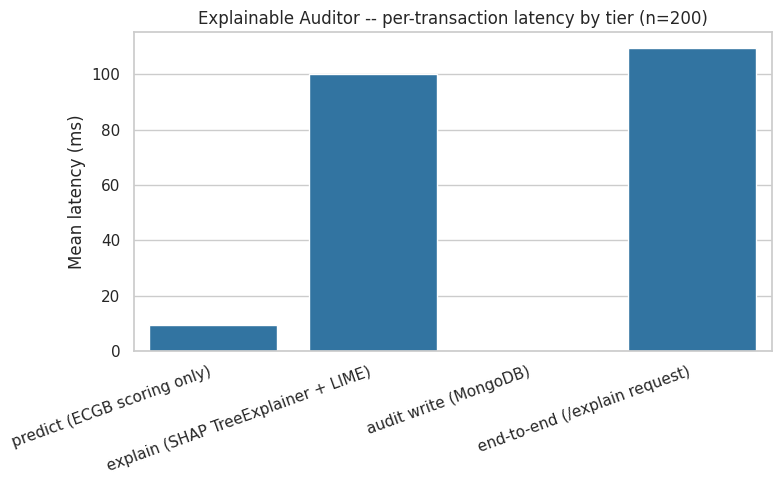

[20:28:44] deployment_evaluation -> completed | n=200, e2e_mean_ms=109.76

Drop these figures straight into the dissertation's System Deployment placeholder: per-transaction latency (scoring vs. scoring+explanation), audit-log write throughput, and RSS delta as the container resource-usage proxy.


In [ ]:
# ============================================================
# SECTION 11.10 - DEPLOYMENT EVALUATION: LATENCY, THROUGHPUT, RESOURCES
# ============================================================
log_stage("deployment_evaluation", "started")

import time
import psutil
from app.audit import log_decision
from app.inference import get_model

X_test = splits['X_test']  # the same held-out test set used throughout

N_BENCH_ROWS = 200  # real transactions drawn from the untouched test set

model = get_model()  # warm the singleton once, outside the timed loop, so that
                     # first-call import and compilation cost is not counted
proc = psutil.Process(os.getpid())
mem_before_mb = proc.memory_info().rss / 1e6

bench_rows = X_test[feature_cols].sample(n=min(N_BENCH_ROWS, len(X_test)), random_state=SEED).to_dict("records")

predict_times, explain_times, audit_times, e2e_times = [], [], [], []
for row in bench_rows:
    t0 = time.perf_counter()
    pred = model.predict(row)
    t1 = time.perf_counter()
    exp = model.explain(row)
    t2 = time.perf_counter()
    rec = log_decision(pred["model_id"], row, pred, explanation=exp, user="deployment-benchmark")
    t3 = time.perf_counter()

    predict_times.append(t1 - t0)
    explain_times.append(t2 - t1)
    audit_times.append(t3 - t2)
    e2e_times.append(t3 - t0)

mem_after_mb = proc.memory_info().rss / 1e6

def _summary(times, label):
    arr = np.array(times) * 1000  # ms
    return {
        "stage": label, "mean_ms": arr.mean(), "p50_ms": np.percentile(arr, 50),
        "p95_ms": np.percentile(arr, 95), "max_ms": arr.max(),
    }

deployment_eval_df = pd.DataFrame([
    _summary(predict_times, "predict (ECGB scoring only)"),
    _summary(explain_times, "explain (SHAP TreeExplainer + LIME)"),
    _summary(audit_times, "audit write (MongoDB)"),
    _summary(e2e_times, "end-to-end (/explain request)"),
]).round(2)

throughput_per_sec = 1.0 / np.mean(audit_times)

print(f"=== Deployment evaluation ({len(bench_rows)} held-out test transactions) ===\n")
display(deployment_eval_df)
print(f"\nAudit-log write throughput   : {throughput_per_sec:,.0f} decisions/sec (single process)")
print(f"Process RSS before benchmark  : {mem_before_mb:,.1f} MB")
print(f"Process RSS after benchmark   : {mem_after_mb:,.1f} MB")
print(f"RSS delta over {len(bench_rows)} requests    : {mem_after_mb - mem_before_mb:+,.1f} MB")

deployment_eval_df.to_csv(f"{DIRS['logs']}/deployment_evaluation_latency.csv", index=False)
save_checkpoint("deployment_evaluation", {
    "latency_summary": deployment_eval_df.to_dict("records"),
    "throughput_per_sec": throughput_per_sec,
    "mem_before_mb": mem_before_mb, "mem_after_mb": mem_after_mb,
    "n_rows": len(bench_rows),
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=deployment_eval_df, x="stage", y="mean_ms", color=PALETTE["accent"], ax=ax)
ax.set_ylabel("Mean latency (ms)"); ax.set_xlabel("")
ax.set_title(f"Explainable Auditor -- per-transaction latency by tier (n={len(bench_rows)})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/deployment_latency_by_tier.png", dpi=150)
plt.show()

log_stage("deployment_evaluation", "completed",
          f"n={len(bench_rows)}, e2e_mean_ms={deployment_eval_df.iloc[3]['mean_ms']:.2f}")
print(
    "\nDrop these figures straight into the dissertation's System Deployment placeholder: "
    "per-transaction latency (scoring vs. scoring+explanation), audit-log write throughput, "
    "and RSS delta as the container resource-usage proxy."
)


### 11.11 Running the container outside this notebook

The notebook is only needed to *generate* the application, not to run it. To stand the
container up independently:

1. Take the `DEPLOY_DIR` folder (`deployment/explainable_auditor/`). It is
   self-contained: `app/`, `model_artifacts/`, `Dockerfile`, `docker-compose.yml` and
   `requirements.txt`.
2. From that folder, run:

```bash
docker compose up --build
```

3. Open `http://localhost:8050` for the investigator interface, or POST directly to
   `http://localhost:8050/api/predict` or `/api/explain`.

The `web` service reads `MONGO_URI=mongodb://mongo:27017` from `docker-compose.yml`,
so it talks to the real `mongo` container rather than the `mongomock` stand-in used
for the in-notebook test and benchmark above. That single environment variable is the
only difference between what runs here and what runs in production.


## 12. Closing Inventory

A final check over what the pipeline actually produced: the saved models, the figures,
the registered results and the ECGB stage history. I run this at the end of a session
to confirm that the artifacts the dissertation cites all exist and correspond to the
run that produced the numbers above.


In [ ]:
# ==========================================================
# SECTION 12 - CLOSING INVENTORY OF EVERYTHING THE PIPELINE PRODUCED
# ==========================================================
# A final check that the artifacts the dissertation cites all exist and came
# from the run recorded above.
import os, pickle

print("=== Saved models ===")
print(sorted(os.listdir(DIRS['models'])))
print("\n=== Confusion-matrix figures ===")
print(sorted(f for f in os.listdir(DIRS['figures']) if 'confusion' in f))

print("\n=== Registered test-set results ===")
r = load_checkpoint('all_model_results', default={})
for k, v in r.items():
    print(k, {m: round(x, 4) for m, x in v.items() if isinstance(x, float)})

print("\n=== ECGB stage history ===")
h = get_pipeline_history()
print(h[h.stage.str.contains('crgb', case=False)]
       [['stage', 'status', 'detail', 'timestamp']].to_string())


['catboost_final.pkl', 'crgb_final_v2.json', 'crgb_lambda0_twin.json', 'dt_final.pkl', 'lightgbm_final.pkl', 'mlp_final.pkl', 'xgboost_final.pkl']
['catboost_confusion_matrix.png', 'crgb_cv_confusion_matrix_v2.png', 'crgb_final_confusion_matrix_v2.png', 'dt_confusion_matrix.png', 'lightgbm_confusion_matrix.png', 'mlp_confusion_matrix.png', 'xgboost_confusion_matrix.png']
XGBoost {'recall': 0.9976, 'precision': 0.9568, 'f1': 0.9768, 'pr_auc': np.float64(0.9983), 'roc_auc': np.float64(0.9999)}
LightGBM {'recall': 0.9976, 'precision': 0.9664, 'f1': 0.9817, 'pr_auc': np.float64(0.9984), 'roc_auc': np.float64(0.9998)}
CatBoost {'recall': 0.9976, 'precision': 0.9414, 'f1': 0.9687, 'pr_auc': np.float64(0.9986), 'roc_auc': np.float64(0.9996)}
DecisionTree {'recall': 0.9982, 'precision': 0.8691, 'f1': 0.9292, 'pr_auc': np.float64(0.998), 'roc_auc': np.float64(0.9993)}
ECGB (CRGB) {'recall': 0.9805, 'precision': 1.0, 'f1': 0.9902, 'pr_auc': np.float64(0.9976), 'roc_auc': np.float64(0.9995)}
MLP 